## **Análise Estratégica do E-Commerce Brasileiro (Olist 2016-2018)**


Este trabalho integra o Tech Challenge da Pós-Tech em Data Analytics da FIAP e corresponde à avaliação da Fase I da pós-graduação. O desafio central é a construção de um relatório executivo direcionado a investidores e acionistas do setor de e-commerce, utilizando como base o [Brazilian E-Commerce Public Dataset da Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). A equipe responsável pelo desenvolvimento é formada por:


*   Allan Diniz      
*   Bruna Andrade
*   Carlos Freitas   
*   Evellyn Machado  
*   Maycon Nunes     


## **1. Contextualização**

No dinâmico cenário do e-commerce brasileiro, a capacidade de transformar grandes volumes de dados transacionais em inteligência estratégica é um fator decisivo para sustentar o crescimento do negócio. Para ecossistemas como o da Olist, que conectam milhares de vendedores a múltiplos marketplaces, compreender padrões de consumo e identificar gargalos operacionais é essencial para mitigar riscos e capturar oportunidades de expansão.

Nesse contexto, variações na eficiência logística ou na satisfação do cliente podem impactar diretamente a reputação da plataforma e seus resultados financeiros, tornando a análise de dados um elemento central na tomada de decisão.

O objetivo deste estudo é analisar o desempenho comercial e operacional da Olist no período de 2016 a 2018. A partir de uma abordagem multidimensional, integrando dados de vendas, logística e comportamento do consumidor. Buscamos gerar uma visão clara sobre a saúde do negócio.

Com base nos indicadores analisados, este relatório apresenta insights e recomendações estratégicas voltadas a apoiar a tomada de decisão de investidores e lideranças executivas.

## **2. Perguntas de Negócio**



Para orientar a análise e garantir uma abordagem estruturada, este estudo foi guiado por três perguntas-chave:

* **Qual foi a evolução da receita da plataforma e quais fatores influenciaram seu desempenho?**

* **Como a performance logística acompanhou a evolução do negócio e qual seu impacto na eficiência operacional?**

* **Como a experiência do cliente evoluiu ao longo do tempo e quais fatores influenciam sua satisfação?**

Essas perguntas estruturam a análise em três dimensões fundamentais do negócio: crescimento, eficiência operacional e experiência do cliente. Permitindo uma visão integrada do desempenho da plataforma.

## **3. Base de Dados e Metodologia**
O conjunto de dados é composto por informações reais e anonimizadas de aproximadamente 100 mil pedidos realizados entre 2016 e 2018.


A análise será estruturada através da integração de tabelas de:


*   Transações: Pedidos, itens e pagamentos
*   Logística: Datas de entrega, geolocalização e status
*   Sentimento: Avaliações e comentários dos clientes (Customer Reviews).

## **4. Principais Indicadores de Desempenho (KPIs)**



Com base nas perguntas de negócio, foram definidos KPIs organizados em quatro dimensões: Crescimento e Receita, Logística e SLA, Satisfação do Cliente e Retenção de Clientes. Esses indicadores permitem avaliar de forma integrada o desempenho do negócio, conectando crescimento, eficiência operacional e experiência do consumidor.

### **4.1 KPIs — Receita**

Objetivo: Identificar os pilares financeiros que sustentam o negócio e se o crescimento é orgânico ou dependente de nichos específicos.



1.   Crescimento da Receita Mensal | Insight: crescimento, sazonalidade

2.   Ticket médio | Insight: cliente compra mais caro ou mais barato? Mudança ao longo do tempo

3.   Receita por Categoria | Insight: Quais categorias sustentam o negócio?

4.   Receita por Estado | Insight: Quais estados sustentam o negócio?





### **4.2 KPIs — Logística**

Objetivo: medir eficiência operacional



1.   Tempo Médio por Etapa (Compra → Aprovação → Postagem → Entrega) | Insight: eficiência logística geral

2.   Desempenho Logístico (SLA de Entrega) | Insight: qualidade do SLA

3.   Taxa de atraso (%) por UF | Insight: gargalos regionais


### **4.3 KPIs — Satisfação do Cliente**

Objetivo: entender experiência do cliente

1.   Atrasos e Impacto no Review Score | Insight: atraso → piora satisfação?

2.   Taxa de Recompra após Atraso na Entrega | Insight: atraso interfere na fidelização do cliente?

4.   Média de Satisfação | Insight: qualidade geral do serviço

3.   Índice de Aprovação (% CSAT) | Insight: percepção do cliente






### **4.4 KPIs — Retenção de Clientes**
Objetivo: avaliar fidelização e longevidade da base de clientes

1. Churn Rate | Insight: percentual de clientes que deixam de consumir → indica perda de receita e insatisfação?

2. Fatores de Fidelização | Insight: frequência de retorno → clientes satisfeitos voltam a comprar?

3. Clientes Novos vs. Fiéis | Insight: capacidade de reengajar clientes → estratégias de retenção estão funcionando?

## **5. Importando as Bibliotecas e os Datasets**







In [1]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Configuração visual global
plt.rcParams.update({
    "figure.facecolor":  "#FFFFFF",
    "axes.facecolor":    "#F8F8F8",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom": False,
    "axes.grid":         True,
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.7,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     14,
})

AZUL   = "#2c3e50"
LARANJA  = "#ff7f0e"
CINZA  = "#B4B2A9"

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importando as bases de dados
df_clientes = pd.read_csv('/content/olist_customers_dataset.csv')
df_pedidos = pd.read_csv('/content/olist_orders_dataset.csv')
df_itens_pedido = pd.read_csv('/content/olist_order_items_dataset.csv')
df_pagamentos = pd.read_csv('/content/olist_order_payments_dataset.csv')
df_avaliacoes = pd.read_csv('/content/olist_order_reviews_dataset.csv')
df_produtos = pd.read_csv('/content/olist_products_dataset.csv')
df_vendedores = pd.read_csv('/content/olist_sellers_dataset.csv')
df_geolocalizacao = pd.read_parquet('/content/olist_geolocation_dataset.parquet')
df_traducao_categorias = pd.read_csv('/content/product_category_name_translation.csv')

## **6. Tratamento e Limpeza dos dados**

### **6.1 Funções**

#### **Função de Análise Básica**

Criei esta função para padronizar a análise exploratória inicial das bases de dados.
O objetivo é evitar repetição de código e facilitar o diagnóstico de problemas
como valores nulos, duplicados, colunas constantes e tipos de dados.


In [3]:
def analise_basica(df, nome_base="Base de dados", mostrar_head=True):
    """
    Função de análise exploratória básica de um DataFrame para diagnóstico inicial de limpeza.

    Parâmetros:
    df (pd.DataFrame): DataFrame a ser analisado.
    nome_base (str): Nome da base de dados (opcional).
    mostrar_head (bool): Se True, mostra as primeiras linhas.
    """

    print(f"\n--- Análise da {nome_base} ---\n")

    # Primeiras linhas
    if mostrar_head:
        print("Primeiras linhas:")
        print(df.head(), "\n")

    # Tamanho da base
    print(f"Tamanho da base (Linhas, Colunas): {df.shape}\n")

    # Tipos de dados
    print("Tipos de dados:")
    print(df.dtypes, "\n")

    # Valores nulos
    print("Valores nulos por coluna:")
    print(df.isnull().sum(), "\n")
    print(f"Total de valores nulos: {df.isnull().sum().sum()}\n")

    # Valores únicos
    print("Valores únicos por coluna:")
    print(df.nunique(), "\n")

    # Colunas constantes
    constantes = [col for col in df.columns if df[col].nunique() == 1]
    print(f"Colunas com apenas um valor único: {constantes}\n")

    # Valores duplicados
    duplicados = df.duplicated().sum()
    print(f"Quantidade de dados duplicados: {duplicados}\n")

    # Colunas categóricas
    print("Colunas categóricas (object):")
    print(df.select_dtypes(include="object").columns, "\n")

    # Resumo estatístico
    print("Resumo estatístico das colunas numéricas:")
    print(df.describe(), "\n")

#### **Função de Correção de CEPs**

Criei a função `corrigir_ceps()` para padronizar colunas de CEP em diferentes bases de dados.  
Durante a investigação, identifiquei que os CEPs estavam armazenados como números inteiros (`int64`), o que é inadequado, pois remove zeros à esquerda e trata o CEP como variável numérica, quando na verdade ele deve ser considerado um identificador categórico.

A função realiza os seguintes passos:
- Converte a coluna de CEP para o tipo `string` (`object`).
- Explora a distribuição de dígitos para verificar inconsistências.
- Identifica e quantifica registros com menos dígitos do que o padrão definido.
- Corrige os valores, preenchendo com zeros à esquerda até atingir o tamanho desejado (por padrão, 5 dígitos).
- Retorna o DataFrame com a coluna de CEP padronizada.


In [4]:
def corrigir_ceps(df, coluna_cep):
    """
    Função para corrigir e padronizar CEPs em uma coluna de DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém a coluna de CEP.
    coluna_cep (str): Nome da coluna que contém os CEPs.

    Retorna:
    pd.DataFrame: DataFrame com a coluna de CEP corrigida e validada.
    """

    # 1. Converter para string
    df[coluna_cep] = df[coluna_cep].astype(str)

    # 2. Explorar a coluna: verificar quantos dígitos cada CEP possui
    print("Distribuição de dígitos na coluna de CEP:")
    print(df[coluna_cep].str.len().value_counts(), "\n")

    # 3. Identificar os casos problemáticos
    print("Exemplos de CEPs com menos dígitos:")
    print(df[df[coluna_cep].str.len() < 5][coluna_cep].head(), "\n")

    # 4. Quantificar o problema
    faltando_zeros = (df[coluna_cep].str.len() < 5).sum()
    print(f"Quantidade de CEPs com zeros faltando: {faltando_zeros}\n")

    # 5. Corrigir o problema: padronizar todos os CEPs para 5 dígitos
    df[coluna_cep] = df[coluna_cep].str.zfill(5)
    print("Correção aplicada: todos os CEPs agora têm 5 dígitos.\n")

    # 6. Validação: garantir que todos os CEPs tenham 5 dígitos e sejam numéricos
    valido = df[coluna_cep].str.len().eq(5).all() and df[coluna_cep].str.isnumeric().all()

    if valido:
        print("Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.\n")
    else:
        print("Atenção: ainda existem CEPs fora do padrão.\n")

    return df

#### **Função de Correção de Cidades**

Criei a função `padronizar_cidades()` para padronizar colunas de cidades em diferentes bases de dados.  
Durante a investigação, identifiquei que os nomes das cidades estavam armazenados em letras minúsculas e sem acentuação.
Embora a análise tenha mostrado que não existem registros com `_`, manter essa verificação é importante para garantir consistência em diferentes bases ou versões futuras dos dados.

A função realiza os seguintes passos:

- Converte a coluna de cidades para o tipo string (object).  
- Explora a coluna para verificar número de valores únicos e possíveis inconsistências.  
- Identifica e quantifica registros com letras minúsculas e com `_` no nome.  
- Corrige os valores, substituindo `_` por espaço e aplicando `.title()` para padronizar a capitalização.  
- Retorna o DataFrame com a coluna de cidades padronizada.

In [5]:
def padronizar_cidades(df, coluna_cidade):
    """
    Função para padronizar nomes de cidades em uma coluna de DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém a coluna de cidades.
    coluna_cidade (str): Nome da coluna que contém os nomes das cidades.

    Retorna:
    pd.DataFrame: DataFrame com a coluna de cidades padronizada.
    """

    # 1. Converter para string
    df[coluna_cidade] = df[coluna_cidade].astype(str)

    # 2. Explorar a coluna: verificar número de valores únicos
    num_cidades = df[coluna_cidade].nunique()
    print(f"A coluna {coluna_cidade} apresenta {num_cidades} valores únicos.\n")

    # 3. Identificar problemas: minúsculas e underscores
    minusc = df[coluna_cidade].str.islower().sum()
    com_underscore = df[coluna_cidade].str.contains('_').sum()
    print(f"Quantidade de cidades em minúsculo: {minusc}")
    print(f"Quantidade de cidades com '_' no nome: {com_underscore}\n")

    # 4. Corrigir o problema: substituir '_' por espaço e aplicar .title()
    df[coluna_cidade] = (
        df[coluna_cidade]
        .str.replace('_', ' ')
        .str.title()
    )
    print("Correção aplicada: nomes de cidades padronizados para melhor leitura.\n")

    # 5. Validar a correção: conferir alguns exemplos
    print(df[coluna_cidade].head(10))

    return df

#### **Função de Correção de Datas**

Criei a função `corrigir_datas()` para padronizar colunas de datas em diferentes bases de dados.  
Durante a investigação, identifiquei que todas as colunas de datas estavam armazenadas como strings (`object`), o que é inadequado para análises temporais, pois impede cálculos de diferença entre datas, ordenações cronológicas e manipulações diretas em gráficos.

A função realiza os seguintes passos:

- Converte as colunas de datas para o tipo `datetime`.  
- Explora os tipos de dados para verificar se a conversão foi aplicada corretamente.  
- Identifica e trata valores inválidos ou nulos, quando necessário.  
- Retorna o DataFrame com as colunas de datas padronizadas, prontas para análises temporais.

In [6]:
def corrigir_datas(df, colunas_datas):
    """
    Função para converter colunas de datas de string (object) para datetime em um DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém as colunas de datas.
    colunas_datas (str ou list): Nome ou lista de nomes das colunas de datas.

    Retorna:
    pd.DataFrame: DataFrame com as colunas de datas convertidas para datetime.
    """

    # Garante que colunas_datas seja sempre uma lista
    if isinstance(colunas_datas, str):
        colunas_datas = [colunas_datas]

    # Converte cada coluna diretamente (vetorizado, sem apply)
    for col in colunas_datas:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Valida a conversão
    print("Tipos de dados após conversão:")
    print(df[colunas_datas].dtypes)

    return df

### **6.2 Base Clientes**

In [7]:
# Executa análise básica da Base de Clientes
analise_basica(df_clientes, nome_base='Base de Clientes', mostrar_head=True)


--- Análise da Base de Clientes ---

Primeiras linhas:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP   

Tamanho da base (Linhas, Colunas): (99441, 5)

Tipos de dados:
customer_id                 obje

#### **Investigação da Coluna de CEPs**


Ao analisar a coluna `customer_zip_code_prefix`, identifiquei dois problemas principais:

1. **Tipo de dado inadequado**: a coluna estava armazenada como número inteiro (`int64`). Isso é incorreto, pois CEP não é uma variável numérica para cálculos, mas sim um identificador categórico. Além disso, armazenar como inteiro remove zeros à esquerda, comprometendo a integridade da informação.

2. **Padrão de dígitos inconsistente**: alguns valores não seguiam o padrão de 5 dígitos, pois estavam sem zeros à esquerda. Para confirmar, contei o número de dígitos em cada registro e verifiquei quantos estavam incompletos.

Após essa investigação, converti a coluna para o tipo `string` (`object`) e apliquei a correção para padronizar todos os CEPs com 5 dígitos.


In [8]:
# 1. Explorar a coluna: verificar quantos dígitos cada CEP possui
df_clientes['customer_zip_code_prefix'].astype(str).str.len().value_counts()


,count
customer_zip_code_prefix,
5,75446
4,23995


In [9]:
# 2. Identificar os casos problemáticos: mostrar registros com menos de 5 dígitos
df_clientes[df_clientes['customer_zip_code_prefix'].astype(str).str.len() < 5]


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
13,eabebad39a88bb6f5b52376faec28612,295c05e81917928d76245e842748184d,5704,sao paulo,SP
...,...,...,...,...,...
99430,27b9b32173455ef32167540451749d0b,277490f0d435b602fe4475d4b89e9181,6727,cotia,SP
99434,f5a0b560f9e9427792a88bec97710212,b3e53d18a997f27a3ffd16da497eaf58,7790,cajamar,SP
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP


In [10]:
# 3. Quantificar o problema: contar quantos CEPs estão incompletos
faltando_zeros = (df_clientes['customer_zip_code_prefix'].astype(str).str.len() < 5).sum()
print(f"Quantidade de CEPs com zeros faltando: {faltando_zeros}")


Quantidade de CEPs com zeros faltando: 23995


In [11]:
# 4. Corrigir o problema: padronizar todos os CEPs para 5 dígitos
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str).str.zfill(5)


In [12]:
# 5. Convertendo para string: garantir que a coluna seja tratada como identificador e não como número
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str)
print(df_clientes['customer_zip_code_prefix'].dtype)

object


In [13]:
# 6. Validação: garantir que todos os CEPs tenham 5 dígitos e sejam numéricos
valido = df_clientes['customer_zip_code_prefix'].str.len().eq(5).all() and df_clientes['customer_zip_code_prefix'].str.isnumeric().all()

if valido:
    print("Validação concluída: todos os CEPs possuem 5 dígitos e são numéricos.\n")
else:
    print("Atenção: ainda existem CEPs fora do padrão.\n")

Validação concluída: todos os CEPs possuem 5 dígitos e são numéricos.



#### **Padronização dos CEPs**

Como outras bases também possuem colunas de CEP, resolvi criar uma função
`padronizar_ceps()` que aplica automaticamente a mesma lógica de correção,
evitando repetição de código e garantindo consistência entre todas as bases.


#### **Investigação da Coluna de Cidades**

Ao analisar a coluna `customer_city`, identifiquei dois pontos principais:

1. **Alta granularidade geográfica**: a coluna apresenta 4.119 valores únicos, o que indica grande diversidade de localidades na base.
2. **Formato não padronizado**: os nomes das cidades estavam armazenados em letras minúsculas e sem acentuação.

Dado o elevado número de cidades, não foi realizada uma padronização manual detalhada.  
Após essa investigação, apliquei uma normalização básica para garantir consistência mínima nos dados padronizando a capitalização com `.title()`.

In [14]:
# 1. Explorar a coluna: verificar exemplos de cidades
df_clientes['customer_city'].head()


,customer_city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


In [15]:
# 2. Identificar os problemas: cidades em minúsculo e sem acentuação
# Verificar se todas as cidades estão em minúsculo
minusc = df_clientes['customer_city'].str.islower().sum()
print(f"Quantidade de cidades em minúsculo: {minusc}")


Quantidade de cidades em minúsculo: 99441


In [16]:
# 3. Verificar se existem cidades com '_' no nome
com_underscore = df_clientes['customer_city'].str.contains('_').sum()
print(f"Quantidade de cidades com '_' no nome: {com_underscore}")


Quantidade de cidades com '_' no nome: 0


In [17]:
# 4. Mostrar alguns exemplos problemáticos
print("Exemplos de cidades problemáticas:")
print(df_clientes[df_clientes['customer_city'].str.contains('_')]['customer_city'].head())


Exemplos de cidades problemáticas:
Series([], Name: customer_city, dtype: object)


In [18]:
# 5. Quantificar o problema: número de valores únicos
num_cidades = df_clientes['customer_city'].nunique()
print(f"A coluna customer_city apresenta {num_cidades} valores únicos.")


A coluna customer_city apresenta 4119 valores únicos.


In [19]:
# 6. Corrigir o problema: padronizar nomes para melhor leitura em análises e gráficos
df_clientes['customer_city_clean'] = (
    df_clientes['customer_city']
    .str.replace('_', ' ')
    .str.title()
)

In [20]:
# 7. Validar a correção: conferir alguns exemplos
df_clientes[['customer_city', 'customer_city_clean']].head(10)


,customer_city,customer_city_clean
0,franca,Franca
1,sao bernardo do campo,Sao Bernardo Do Campo
2,sao paulo,Sao Paulo
3,mogi das cruzes,Mogi Das Cruzes
4,campinas,Campinas
5,jaragua do sul,Jaragua Do Sul
6,sao paulo,Sao Paulo
7,timoteo,Timoteo
8,curitiba,Curitiba
9,belo horizonte,Belo Horizonte


#### **Padronização das Cidades**

Como outras bases também possuem colunas de cidades, resolvi criar uma função `padronizar_cidades()` que aplica automaticamente a mesma lógica de correção, evitando repetição de código e garantindo consistência entre todas as bases.  
Essa função será responsável por substituir caracteres como `_` por espaço e padronizar a capitalização com `.title()`, assegurando que os nomes das cidades fiquem em um formato uniforme e legível para análises e gráficos.


### **6.3 Base Pedidos**

In [21]:
# Executa análise básica da Base de Pedidos
analise_basica(df_pedidos, nome_base='Base de Pedidos', mostrar_head=True)


--- Análise da Base de Pedidos ---

Primeiras linhas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25

#### **Investigação das Base de Pedidos**


Na análise da base `df_pedidos`, observei que as colunas de datas (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) estão armazenadas no formato padrão ISO (YYYY-MM-DD HH:MM:SS).  

Embora esse formato não seja o mais comum no Brasil, optei por mantê-lo inalterado na base, pois facilita cálculos, comparações e integrações com outras fontes de dados.  

Quando necessário para visualização em gráficos ou relatórios, aplicarei a formatação brasileira (DD/MM/YYYY) diretamente na etapa de apresentação, sem alterar os dados originais.


#### Investigação das Colunas de Datas

Na análise da base `df_pedidos`, observei que todas as colunas de datas estavam armazenadas como strings (`object`).  


Para corrigir esse problema, converti todas as colunas de datas para o tipo `datetime` utilizando `pd.to_datetime`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que as colunas passaram a ser reconhecidas como `datetime64[ns]`.

In [22]:
# 1. Converter colunas de data para datetime
colunas_datas = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
df_pedidos = corrigir_datas(df_pedidos, colunas_datas)

Tipos de dados após conversão:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Padronização das Datas

Como outras bases também possuem colunas de datas, resolvi criar uma função `corrigir_datas()` que aplica automaticamente a mesma lógica de conversão, evitando repetição de código e garantindo consistência entre todas as bases.  

Essa função será responsável por transformar colunas armazenadas como strings (`object`) em colunas do tipo `datetime`, assegurando que os valores possam ser utilizados corretamente em cálculos temporais, ordenações cronológicas e visualizações em gráficos.

#### Investigação dos Valores Nulos

Na análise da base `df_pedidos`, observei a presença de valores nulos em algumas colunas relacionadas ao ciclo de vida dos pedidos.  
A contagem de valores nulos foi a seguinte:

- `order_approved_at`: 160  
- `order_delivered_carrier_date`: 1.783  
- `order_delivered_customer_date`: 2.965  

Total de valores nulos: **4.908**

Esses valores foram interpretados da seguinte forma:

- `order_approved_at`: pedidos não aprovados ou cancelados;  
- `order_delivered_carrier_date`: pedidos que não chegaram à transportadora ou não avançaram no fluxo logístico;  
- `order_delivered_customer_date`: pedidos não entregues, incluindo tanto pedidos cancelados quanto pedidos ainda em andamento no processo de entrega.  

Dessa forma, os valores nulos foram mantidos, pois representam diferentes estágios do ciclo de vida dos pedidos e são relevantes para análise operacional e logística.

In [23]:
# 1. Investigando os valores nulos
df_pedidos.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


#### Investigação da Coluna `order_status`

Na análise da base `df_pedidos`, identifiquei 8 status distintos na coluna `order_status`:  
`delivered`, `invoiced`, `shipped`, `processing`, `unavailable`, `canceled`, `created`, `approved`.

Para entender melhor o significado desses status, cruzei com a coluna `order_delivered_customer_date`, filtrando os pedidos que não foram entregues (valores nulos).  
A contagem de status entre os pedidos não entregues foi a seguinte:

- `shipped`: 1.107  
- `canceled`: 619  
- `unavailable`: 609  
- `invoiced`: 314  
- `processing`: 301  
- `delivered`: 8  
- `created`: 5  
- `approved`: 2  

Essa investigação reforça que os status representam diferentes estágios do ciclo de vida dos pedidos.  
Em especial, os status `shipped`, `invoiced`, `processing`, `unavailable` e `canceled` estão fortemente associados a pedidos que não chegaram ao cliente, seja por estarem em trânsito, com problemas logísticos ou por terem sido cancelados.

Dessa forma, os valores da coluna `order_status` foram mantidos como estão, pois são relevantes para análises operacionais e podem ser utilizados para segmentar pedidos por estágio logístico.

In [24]:
# 1. Verifica os status dos pedidos
df_pedidos['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [25]:
# 2. Verifica quais status estão associados a pedidos não entregues
(
    df_pedidos[df_pedidos['order_delivered_customer_date'].isna()]
    ['order_status']
    .value_counts()
)

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


### **6.4 Base Itens Pedidos**

In [26]:
# Executa análise básica da Base de Itens Pedidos
analise_basica(df_itens_pedido, nome_base='Base de Itens Pedidos', mostrar_head=True)


--- Análise da Base de Itens Pedidos ---

Primeiras linhas:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00 

#### Estrutura da Base de Itens de Pedido

- **Tamanho da base (Linhas, Colunas):** (112650, 7)  
- A base de itens de pedido apresenta maior número de registros em relação ao total de pedidos, pois cada pedido pode conter múltiplos itens.  


#### Investigação dos Valores Monetários

Na análise da base `df_itens_pedidos`, identifiquei que os valores monetários (`price` e `freight_value`) estão armazenados no padrão internacional, utilizando ponto como separador decimal.  

Para garantir a integridade das análises e evitar problemas em cálculos, optei por manter esse formato na base de dados.  
O padrão brasileiro (vírgula como separador decimal e símbolo R$) será aplicado apenas nas visualizações e relatórios, assegurando clareza e acessibilidade para o público sem comprometer a consistência dos dados originais.

#### Investigação da Coluna de Datas

Na análise da base `df_itens_pedidos`, observei que a coluna `shipping_limit_date` estava armazenada como string (`object`).  

Para corrigir esse problema, converti a coluna para o tipo `datetime` utilizando a função `corrigir_datas()`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que a coluna passou a ser reconhecida como `datetime64[ns]`.

In [27]:
# Converte a coluna shipping_limit_date para datetime
df_itens_pedido = corrigir_datas(df_itens_pedido, 'shipping_limit_date')

Tipos de dados após conversão:
shipping_limit_date    datetime64[ns]
dtype: object


#### Investigação das Colunas Numéricas

Na análise da base `df_itens_pedidos`, utilizei o **resumo estatístico** das colunas numéricas (`price` e `freight_value`) para identificar padrões e possíveis inconsistências.  
Além disso, realizei verificações manuais para confirmar regras de negócio específicas.

Principais pontos observados:

- **Coluna `freight_value`**: foram identificados **383 registros** com valor igual a 0, interpretados como casos de frete grátis.  
- **Coluna `price`**: não foram encontrados valores iguais a 0, o que é positivo, pois preços zerados seriam inconsistentes.  
- **Verificação manual**: confirmei que não existem valores negativos em ambas as colunas (`price` e `freight_value`), o que garante integridade dos dados.  

Dessa forma, os dados foram mantidos como estão, pois refletem corretamente situações reais do processo de venda e logística.

In [28]:
# 1. Verifica se existem valores negativos nas colunas de preço e frete
(df_itens_pedido[['price', 'freight_value']] < 0).sum()


,0
price,0
freight_value,0


In [29]:
# 2. Verifica produtos com preço igual a zero
(df_itens_pedido['price'] == 0).sum()


np.int64(0)

In [30]:
# 3. Verifica frete igual a zero (possível frete grátis)
(df_itens_pedido['freight_value'] == 0).sum()


np.int64(383)

### **6.5 Base Pagamentos**

In [31]:
# Executa análise básica da Base de Pagamentos
analise_basica(df_pagamentos, nome_base='Base de Pagamentos', mostrar_head=True)


--- Análise da Base de Pagamentos ---

Primeiras linhas:
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45   

Tamanho da base (Linhas, Colunas): (103886, 5)

Tipos de dados:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object 

Valores nulos por col

#### Investigação da Base de Pagamentos

Na análise da base `df_pagamentos`, utilizei o resumo estatístico das colunas numéricas para identificar padrões e possíveis inconsistências.

Principais pontos observados:

- **Colunas numéricas (`payment_sequential`, `payment_installments`, `payment_value`)**: não apresentam valores negativos, o que garante integridade dos dados.  
- **Coluna `payment_value`**: foram identificados registros com valor igual a 0, o que pode indicar casos de pedidos cancelados, promoções específicas ou inconsistências que precisam ser investigadas.  
- **Parcelas (`payment_installments`)**: variam de 1 até 24, mostrando que há diversidade na forma de pagamento dos clientes.  
- **Sequência de pagamento (`payment_sequential`)**: varia de 1 até 29, indicando que alguns pedidos podem ter múltiplos pagamentos associados.



#### Estrutura da Base de Pagamentos

- **Tamanho da base (Linhas, Colunas):** (103886, 5)  
- **Pedidos únicos:** 99.440  
- Observa-se que a base de pagamentos possui mais registros do que o número de pedidos únicos.  
- Isso ocorre porque um pedido pode ter múltiplos registros de pagamento, seja por parcelamento ou pela combinação de diferentes métodos de pagamento.  
- Essa é uma **característica estrutural da base**, e não uma inconsistência nos dados.

#### Pagamentos com Valor Zerado

- **Pagamentos zerados com `payment_type = voucher`**: considerados válidos, pois representam pedidos totalmente cobertos por cupons ou descontos.  
- **Pagamentos zerados com `payment_type = not_defined`**: foram identificados 3 registros. Esses casos são interpretados como falhas no processamento dos dados, já que não há tipo de pagamento definido e o valor é igual a zero.  
- **Decisão**: os registros serão **mantidos na base sem exclusão**, para preservar a integridade do conjunto original e permitir análises futuras sobre a qualidade dos dados.

In [32]:
# 1. Verifica se há valores zerados na coluna de pagamento
df_pagamentos[df_pagamentos['payment_value'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


#### Ajuste de Inconsistências na Base de Pagamentos

- Foram identificados 2 registros com `payment_type = credit_card` e `payment_installments = 0`.  
- Esse cenário é inconsistente, pois uma transação de cartão de crédito deve ter pelo menos 1 parcela.  
- **Decisão**: os valores foram corrigidos de 0 para 1, tratando como erro de cadastro.  


In [33]:
# 1. Verifica se há valores zerados na coluna de parcelas
df_pagamentos[df_pagamentos['payment_installments'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [34]:
# 2. Corrige os valores das parcelas
df_pagamentos.loc[
    (df_pagamentos['payment_type'] == 'credit_card') &
    (df_pagamentos['payment_installments'] == 0),
    'payment_installments'
] = 1

In [35]:
# 3. Verifica a correção
df_pagamentos[
    (df_pagamentos['payment_type'] == 'credit_card') &
    (df_pagamentos['payment_installments'] == 0)
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


### **6.6 Base Avaliações**

In [36]:
# Executa análise básica da Base de Avaliações
analise_basica(df_avaliacoes, nome_base='Base de Avaliações', mostrar_head=True)


--- Análise da Base de Avaliações ---

Primeiras linhas:
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                              

#### Verificação da Coluna `review_score`

- As notas atribuídas pelos clientes devem variar apenas entre **1 e 5**.  
- Foi realizada a verificação dos valores distintos e não foram encontrados registros fora desse intervalo.  
- Dessa forma, a coluna `review_score` está consistente e pronta para análises de satisfação dos clientes.

In [37]:
# 1. Confere se existem notas fora do intervalo permitido (1 a 5)
df_avaliacoes[~df_avaliacoes['review_score'].between(1, 5)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


#### Campos Textuais nas Avaliações

- A base de avaliações contém os campos `review_comment_title` e `review_comment_message`, que podem estar nulos (NaN).  
- Esses valores nulos não representam falhas, mas sim a **ausência de comentários textuais** por parte dos clientes.  
- Os campos são opcionais, permitindo que o cliente avalie apenas por meio da nota (`review_score`), sem inserir título ou descrição.  
- Essa premissa é confirmada empiricamente: **56.518 registros** não possuem nenhum campo textual preenchido e ainda assim apresentam `review_score` válido, com distribuição em todos os níveis de nota (1 a 5).  
- Portanto, os valores nulos são considerados **válidos** e refletem o comportamento real dos usuários.  



In [38]:
# 1. Confirmar que avaliações sem nenhum campo textual possuem review_score válido
# 2. (valida a premissa de que o cliente avaliou só pela nota)
so_nota = df_avaliacoes[
    df_avaliacoes['review_comment_title'].isna() &
    df_avaliacoes['review_comment_message'].isna()
]
print(f"Registros apenas com nota (sem nenhum texto): {len(so_nota)}")
print(f"Distribuição de scores nesses registros:")
print(so_nota['review_score'].value_counts().sort_index())

Registros apenas com nota (sem nenhum texto): 56518
Distribuição de scores nesses registros:
review_score
1     2595
2      986
3     4535
4    12864
5    35538
Name: count, dtype: int64


In [39]:
# 3. Exibe os primeiros 30 registros com título ou comentário preenchido
df_avaliacoes[['review_comment_title', 'review_comment_message']].dropna(how='all').head(30)

,review_comment_title,review_comment_message
3,NaN,Recebi bem antes do prazo estipulado.
4,NaN,Parabéns lojas lannister adorei comprar pela I...
9,recomendo,aparelho eficiente. no site a marca do aparelh...
12,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,Super recomendo,"Vendedor confiável, produto ok e entrega antes..."
16,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,Não chegou meu produto,Péssimo
22,Ótimo,Loja nota 10
24,NaN,obrigado pela atençao amim dispensada
27,NaN,A compra foi realizada facilmente.\r\nA entreg...


#### Observações adicionais:
- Foram identificados **1.729 registros** com `review_comment_title` preenchido mas `review_comment_message` nulo.  
- Esse cenário é tecnicamente possível dentro das regras do formulário e não compromete a integridade dos dados.  
- A análise textual será feita apenas sobre os registros que possuem os respectivos campos preenchidos.

In [40]:
# 1. Verifica registros com título preenchido mas sem mensagem
titulo_sem_mensagem = df_avaliacoes[
    df_avaliacoes['review_comment_title'].notna() &
    df_avaliacoes['review_comment_message'].isna()
]
print(f"Registros com título mas sem mensagem: {len(titulo_sem_mensagem)}")

Registros com título mas sem mensagem: 1729


#### Quantitativo de valores nulos (base após remoção de duplicatas — 98.410 registros):

- `review_comment_title`: **87.656** registros nulos  
- `review_comment_message`: **58.247** registros nulos (**58,7%**) — **40.977** preenchidos (**41,3%**)  



In [41]:
# 1. Conta registros com e sem comentário textual
comentarios_preenchidos = df_avaliacoes['review_comment_message'].notna().sum()
comentarios_nulos = df_avaliacoes['review_comment_message'].isna().sum()
total = len(df_avaliacoes)

print(f"Comentários preenchidos: {comentarios_preenchidos}")
print(f"Comentários nulos: {comentarios_nulos}")
print(f"Proporção de comentários preenchidos: {comentarios_preenchidos/total:.2%}")
print(f"Proporção de comentários nulos: {comentarios_nulos/total:.2%}")

Comentários preenchidos: 40977
Comentários nulos: 58247
Proporção de comentários preenchidos: 41.30%
Proporção de comentários nulos: 58.70%


#### Conversão de Colunas de Datas

As colunas `review_creation_date` e `review_answer_timestamp` estavam armazenadas como **strings (object)**.  

Para corrigir esse problema, converti ambas para o tipo **datetime** utilizando a função `corrigir_datas()`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que as colunas passaram a ser reconhecidas como **datetime64[ns]**.  


In [42]:
# 1. Converte as colunas review_creation_date e review_answer_timestamp para datetime
df_avaliacoes = corrigir_datas(df_avaliacoes, ['review_creation_date', 'review_answer_timestamp'])


Tipos de dados após conversão:
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


#### Datas e Horários nas Avaliações

- As colunas `review_creation_date` e `review_answer_timestamp` estão armazenadas no formato padrão ISO (`YYYY-MM-DD HH:MM:SS`).  
- Embora esse formato não seja o mais comum no Brasil, será mantido **inalterado**, pois facilita cálculos, comparações e integrações com outras fontes de dados.  
- Quando necessário para visualização em gráficos ou relatórios, será aplicada a formatação brasileira (`DD/MM/YYYY`) diretamente na etapa de apresentação, sem modificar os dados originais.  
- **Limitação de granularidade:** o campo `review_creation_date` registra apenas a **data**, sem horário preciso. As horas únicas identificadas (0 e 1) são artefatos da conversão de fuso horário, não representam horários reais.  
- O campo `review_answer_timestamp` que preserva o horário completo.  
- Se necessário o `review_creation_date` será usado para análises em nível de **dia, mês ou ano**, enquanto `review_answer_timestamp` para investigações de granularidade maior.

In [43]:
# 1. Verifica granularidade da review_creation_date
horas_unicas = df_avaliacoes['review_creation_date'].dt.hour.unique()
print(f"Horas únicas em review_creation_date: {horas_unicas}")

Horas únicas em review_creation_date: [0 1]


#### Verificação de Duplicidade em `review_id`

- A base possui **99.224 registros**, mas apenas **98.410 `review_id` distintos**, evidenciando **814 registros duplicados**.  
- A investigação confirmou que, em todos os casos, o mesmo `review_id` está associado a **`order_id` diferentes** ou seja, não se trata do mesmo pedido avaliado duas vezes, mas sim de um identificador reutilizado indevidamente em pedidos distintos.  
- A análise dos campos `review_score`, `review_comment_title`, `review_comment_message` e `review_creation_date` retornou valor máximo de **1 valor distinto por grupo**, confirmando que os registros duplicados são **cópias exatas** em todos os campos analisados.  
- Interpreto como uma provável **falha de ingestão de dados (carga duplicada)**, e não uma colisão de identificadores ou comportamento intencional do sistema.  
- Como os duplicados não apresentam nenhuma informação adicional, **eles foram removidos**


In [44]:
# 1. Evidencia inconsistência nos review_id
print(f"Total de linhas: {len(df_avaliacoes)}")
print(f"Total de review_id únicos: {df_avaliacoes['review_id'].nunique()}")
print(f"Diferença: {len(df_avaliacoes) - df_avaliacoes['review_id'].nunique()}")

Total de linhas: 99224
Total de review_id únicos: 98410
Diferença: 814


In [45]:
# 2. Vizualiza exemplos concretos de duplicidade em review_id
duplicatas = df_avaliacoes[df_avaliacoes.duplicated(subset='review_id', keep=False)]
duplicatas.sort_values('review_id').head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44


In [46]:
# 3. Identifica IDs duplicados
dup_ids = df_avaliacoes[df_avaliacoes.duplicated(subset='review_id', keep=False)]['review_id']

In [47]:
# 4. Seleciona apenas os registros com esses IDs duplicados
df_dup = df_avaliacoes[df_avaliacoes['review_id'].isin(dup_ids)]

In [48]:
# 5. Agrupa por review_id e contar quantos valores distintos existem em score e mensagem
df_dup.groupby('review_id')[['review_score', 'review_comment_message']].nunique()

,review_score,review_comment_message
review_id,,
00130cbe1f9d422698c812ed8ded1919,1,1
0115633a9c298b6a98bcbe4eee75345f,1,0
0174caf0ee5964646040cd94e15ac95e,1,1
017808d29fd1f942d97e50184dfb4c13,1,0
0254bd905dc677a6078990aad3331a36,1,1
...,...,...
fde2e6abaf5bb64f7407a44741c24dec,1,0
fde5986d35c89aa1b6ce4149de82a0d3,1,0
fe5c833752953fed3209646f1f63b53c,1,1


In [49]:
# 6. Verifica se as linhas duplicadas são 100% idênticas em todos os campos
df_dup_completo = df_avaliacoes[df_avaliacoes['review_id'].isin(dup_ids)]

campos = ['review_score', 'review_comment_title',
          'review_comment_message', 'review_creation_date']

df_dup_completo.groupby('review_id')[campos].nunique().max()

,0
review_score,1
review_comment_title,1
review_comment_message,1
review_creation_date,1


In [50]:
# 7. Remove duplicatas mantendo a primeira ocorrência
df_avaliacoes_limpo = df_avaliacoes.drop_duplicates(subset='review_id', keep='first')

In [51]:
# 8. Confirma resultado
print(f"Antes: {len(df_avaliacoes)} linhas")
print(f"Depois: {len(df_avaliacoes_limpo)} linhas")
print(f"Removidas: {len(df_avaliacoes) - len(df_avaliacoes_limpo)} linhas")

Antes: 99224 linhas
Depois: 98410 linhas
Removidas: 814 linhas


### **6.7 Base Produtos**

In [52]:
# Executa análise básica da Base de Produtos
analise_basica(df_produtos, nome_base='Base de Produtos', mostrar_head=True)


--- Análise da Base de Produtos ---

Primeiras linhas:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0          

#### Padronização de Nomes de Colunas

Na análise da base `df_produtos`, identifiquei que duas colunas estavam com erro de grafia:

- `product_name_lenght` → **correto:** `product_name_length`  
- `product_description_lenght` → **correto:** `product_description_length`  

A renomeação foi aplicada para garantir consistência e evitar problemas em consultas ou integrações futuras:


In [53]:
# 1. Corrige erro ortográfico nos nomes das colunas (lenght → length)
df_produtos = df_produtos.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})

#### Padronização das Categorias de Produtos

Na análise da coluna `product_category_name` da base `df_produtos`, identifiquei inconsistências como variações e duplicidades de categorias (ex.: `bebidas` vs `alimentos_bebidas`, `casa_conforto` vs `casa_conforto_2`).  

Para corrigir essas divergências e garantir consistência, foi criado um **dicionário de mapeamento** (`mapa_categorias`) que agrupa categorias semelhantes em um único nome padronizado. Exemplos de ajustes aplicados:

- `alimentos_bebidas` → `alimentos`  
- `casa_conforto_2` → `casa_conforto`  
- Diversas categorias de construção → `construcao`  
- `eletrodomesticos_2` → `eletrodomesticos`  
- Subcategorias de moda (`fashion_*`) → `vestuario`  
- Variações de livros (`livros_importados`, `livros_tecnicos`, etc.) → `livros`  
- Variações de informática (`pcs`, `pc_gamer`, etc.) → `informatica`

In [54]:
# 1. Verifica a quantidade de categorias de produtos
df_produtos["product_category_name"].nunique()

73

In [55]:
# 2. Verifica as categorias dos produtos
df_produtos['product_category_name'].dropna().sort_values().unique()

array(['agro_industria_e_comercio', 'alimentos', 'alimentos_bebidas',
       'artes', 'artes_e_artesanato', 'artigos_de_festas',
       'artigos_de_natal', 'audio', 'automotivo', 'bebes', 'bebidas',
       'beleza_saude', 'brinquedos', 'cama_mesa_banho', 'casa_conforto',
       'casa_conforto_2', 'casa_construcao', 'cds_dvds_musicais',
       'cine_foto', 'climatizacao', 'consoles_games',
       'construcao_ferramentas_construcao',
       'construcao_ferramentas_ferramentas',
       'construcao_ferramentas_iluminacao',
       'construcao_ferramentas_jardim',
       'construcao_ferramentas_seguranca', 'cool_stuff', 'dvds_blu_ray',
       'eletrodomesticos', 'eletrodomesticos_2', 'eletronicos',
       'eletroportateis', 'esporte_lazer', 'fashion_bolsas_e_acessorios',
       'fashion_calcados', 'fashion_esporte', 'fashion_roupa_feminina',
       'fashion_roupa_infanto_juvenil', 'fashion_roupa_masculina',
       'fashion_underwear_e_moda_praia', 'ferramentas_jardim', 'flores',
       'fral

In [56]:
# 3. Dicionário para padronização das categorias de produtos.
mapa_categorias = {
    # Alimentos
    'alimentos_bebidas': 'alimentos',

    # Casa / conforto
    'casa_conforto_2': 'casa_conforto',

    # Construção (ajuste fino incluído)
    'casa_construcao': 'construcao',
    'construcao_ferramentas_construcao': 'construcao',
    'construcao_ferramentas_ferramentas': 'construcao',
    'construcao_ferramentas_iluminacao': 'construcao',
    'construcao_ferramentas_jardim': 'construcao',
    'construcao_ferramentas_seguranca': 'construcao',

    # Eletrodomésticos
    'eletrodomesticos_2': 'eletrodomesticos',

    # CDs / DVDs / música
    'dvds_blu_ray': 'cds_dvds_musicais',
    'musica': 'cds_dvds_musicais',

    # Livros
    'livros_importados': 'livros',
    'livros_interesse_geral': 'livros',
    'livros_tecnicos': 'livros',

    # Moda → Vestuário
    'fashion_bolsas_e_acessorios': 'vestuario',
    'fashion_calcados': 'vestuario',
    'fashion_esporte': 'vestuario',
    'fashion_roupa_feminina': 'vestuario',
    'fashion_roupa_infanto_juvenil': 'vestuario',
    'fashion_roupa_masculina': 'vestuario',
    'fashion_underwear_e_moda_praia': 'vestuario',

    # Artes
    'artes_e_artesanato': 'artes',

    # Móveis
    'moveis_colchao_e_estofado': 'moveis',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis',
    'moveis_decoracao': 'moveis',
    'moveis_escritorio': 'moveis',
    'moveis_quarto': 'moveis',
    'moveis_sala': 'moveis',

    # Portáteis cozinha
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',

    # Telefonia
    'telefonia_fixa': 'telefonia',

    # Segurança
    'sinalizacao_e_seguranca': 'seguranca',
    'seguros_e_servicos': 'seguranca',

    # Informática
    'pcs': 'informatica',
    'pc_gamer': 'informatica',
    'tablets_impressao_imagem': 'informatica',
    'informatica_acessorios': 'informatica',

    # Indústria / comércio
    'industria_comercio_e_negocios': 'industria_comercio',
    'agro_industria_e_comercio': 'industria_comercio',


}

In [57]:
# 4. Cria coluna padronizada sem sobrescrever a categoria original
df_produtos['product_category_clean'] = (
    df_produtos['product_category_name']
    .replace(mapa_categorias)
    .fillna('sem_categoria')
)

In [58]:
# 5. Verifica a quantidade de categorias de produtos após ajuste
df_produtos['product_category_clean'].nunique()

42

In [59]:
# 6. Verifica as categorias dos produtos após ajuste
df_produtos['product_category_clean'].dropna().sort_values().unique()

array(['alimentos', 'artes', 'artigos_de_festas', 'artigos_de_natal',
       'audio', 'automotivo', 'bebes', 'bebidas', 'beleza_saude',
       'brinquedos', 'cama_mesa_banho', 'casa_conforto',
       'cds_dvds_musicais', 'cine_foto', 'climatizacao', 'consoles_games',
       'construcao', 'cool_stuff', 'eletrodomesticos', 'eletronicos',
       'eletroportateis', 'esporte_lazer', 'ferramentas_jardim', 'flores',
       'fraldas_higiene', 'industria_comercio', 'informatica',
       'instrumentos_musicais', 'la_cuisine', 'livros',
       'malas_acessorios', 'market_place', 'moveis', 'papelaria',
       'perfumaria', 'pet_shop', 'relogios_presentes', 'seguranca',
       'sem_categoria', 'telefonia', 'utilidades_domesticas', 'vestuario'],
      dtype=object)

#### Investigação das Variáveis Físicas dos Produtos

Na análise descritiva das variáveis físicas da base `df_produtos` (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`), identifiquei a presença de valores inválidos.  

Especificamente, foram encontrados **4 registros com `product_weight_g = 0`**, o que não é fisicamente plausível para produtos reais.  

Considerando que esses registros representam uma parcela insignificante da base (0,01% dos 32.951 produtos), optei por **removê-los**. Essa decisão visa garantir maior consistência e confiabilidade nas análises subsequentes, evitando distorções em estatísticas de peso médio e em modelos que utilizem essa variável.

In [60]:
# 1. Verifica se existem produtos com peso = 0
(df_produtos['product_weight_g'] == 0).sum()

np.int64(4)

In [61]:
# 2. Estatísticas descritivas das dimensões e peso dos produtos
colunas = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

df_produtos[colunas].describe().round(2)

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.00,32949.00,32949.00,32949.00
mean,2276.47,30.82,16.94,23.20
std,4282.04,16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00


In [62]:
# Remove produtos com peso inválido (igual a zero)
df_produtos = df_produtos[df_produtos['product_weight_g'] > 0]

In [63]:
# Verifica se ainda existem valores inválidos
(df_produtos['product_weight_g'] == 0).sum()

np.int64(0)

#### Conversão da Coluna de Quantidade de Fotos

Identifiquei que a coluna `product_photos_qty` estava armazenada como **float64**, apesar de representar uma variável de contagem.  

Ela foi convertida para o tipo **Int64** (com "I" maiúsculo), que permite valores nulos (`NaN`). Essa escolha garante maior consistência sem perda de informação, uma vez que o tipo `int64` convencional não suporta valores nulos.  


In [64]:
# 1. Converte a coluna 'product_photos_qty' para inteiro
df_produtos['product_photos_qty'] = df_produtos['product_photos_qty'].astype("Int64")

In [65]:
# 2. Valida o tipo da coluna product_photos_qty após conversão
df_produtos['product_photos_qty'].dtype

Int64Dtype()

In [66]:
# Verificando a existência de valores nulos
df_produtos.isnull().sum().sum()

np.int64(2436)

In [67]:
print(f'Quantidade de dados nulos da base de produtos: {df_produtos.isnull().sum().sum()}')

Quantidade de dados nulos da base de produtos: 2436


#### Tratamento de Registros Nulos na Base de Produtos

Foram identificados **609 registros** com ausência simultânea de informações em `product_category_name`, `product_name_length`, `product_description_length` e `product_photos_qty`, caracterizando cadastros incompletos. Optou-se por **removê-los da base de produtos**.

> ⚠️ **Importante:** a remoção foi aplicada apenas na `df_produtos`. Os pedidos que referenciam esses produtos são **mantidos na base analítica** e classificados como `sem_categoria`, pois representam **R$ 244.638 de receita real (1,59% do total)** — pedidos efetivamente entregues e pagos.

A investigação confirmou que nenhum produto com cadastro completo foi removido indevidamente:
- **584 produtos** nunca tiveram categoria no dataset original
- **5 produtos** foram removidos por peso zero ou dimensões físicas nulas — impacto financeiro de apenas **R$ 3.642 (0,02%)**

In [68]:
# 1. Investigando os valores nulos
df_produtos.isnull().sum()

,0
product_id,0
product_category_name,609
product_name_length,609
product_description_length,609
product_photos_qty,609
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0
product_category_clean,0


In [69]:
# 2. Verifica se os registros nulos identificados pertencem ao mesmo grupo de produtos incompletos
df_produtos[
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
].shape

(609, 10)

In [70]:
# 3. Removendo produtos com cadastro incompleto sem categoria, nome, descrição e quantidade de fotos
df_produtos = df_produtos[~(
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
)]

In [71]:
# 4. Verifica se ainda existem registros incompletos
df_produtos[
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
].shape

(0, 10)

In [72]:
# 5. Evidenciando o impacto financeiro dos pedidos sem categoria
_pedidos_entregues = df_pedidos[df_pedidos['order_status'] == 'delivered']

_receita_por_pedido = (
    df_pagamentos
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

_itens_sem_categoria = (
    df_itens_pedido[df_itens_pedido['order_id'].isin(_pedidos_entregues['order_id'])]
    .merge(
        df_produtos[['product_id', 'product_category_clean']],
        on='product_id',
        how='left'
    )
)

sem_categoria = _itens_sem_categoria[_itens_sem_categoria['product_category_clean'].isna()]

receita_sem_categoria = sem_categoria.merge(
    _receita_por_pedido, on='order_id', how='left'
)['payment_value'].sum()

receita_total = _receita_por_pedido['payment_value'].sum()
percentual = (receita_sem_categoria / receita_total) * 100

print(f"Receita total:          R$ {receita_total:,.2f}")
print(f"Receita sem categoria:  R$ {receita_sem_categoria:,.2f}")
print(f"Impacto:                {percentual:.2f}%")

Receita total:          R$ 16,008,872.12
Receita sem categoria:  R$ 244,638.22
Impacto:                1.53%


In [73]:
# 6. Investigando os 5 produtos com categoria no original mas removidos na limpeza
_df_produtos_original = pd.read_csv('/content/olist_products_dataset.csv')

_product_ids_sem_categoria = sem_categoria['product_id'].unique()

_product_ids_com_categoria = _df_produtos_original[
    _df_produtos_original['product_id'].isin(_product_ids_sem_categoria) &
    _df_produtos_original['product_category_name'].notna()
]['product_id'].values

print(f"Produtos sem categoria encontrados: {len(_product_ids_sem_categoria)}")
print(f"Desses, produtos que tinham categoria no original: {len(_product_ids_com_categoria)}")
print()

_df_produtos_original[
    _df_produtos_original['product_id'].isin(_product_ids_com_categoria)
]

Produtos sem categoria encontrados: 589
Desses, produtos que tinham categoria no original: 5



,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [74]:
# 7. Impacto financeiro específico dos 5 produtos removidos que tinham categoria
_itens_5_produtos = df_itens_pedido[
    df_itens_pedido['product_id'].isin(_product_ids_com_categoria)
]

_receita_5_produtos = _itens_5_produtos.merge(
    df_pagamentos.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)['payment_value'].sum()

print(f"Produtos com categoria removidos:  {len(_product_ids_com_categoria)}")
print(f"Receita dos 5 produtos removidos:  R$ {_receita_5_produtos:,.2f}")
print(f"Percentual sobre receita total:    {(_receita_5_produtos / receita_total) * 100:.4f}%")

Produtos com categoria removidos:  5
Receita dos 5 produtos removidos:  R$ 3,642.34
Percentual sobre receita total:    0.0228%


### **6.8 Base Vendedores**

In [75]:
# Executa análise básica da Base de Vendedores
analise_basica(df_vendedores, nome_base='Base de Vendedores', mostrar_head=True)


--- Análise da Base de Vendedores ---

Primeiras linhas:
                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP   

Tamanho da base (Linhas, Colunas): (3095, 4)

Tipos de dados:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object 

Valores nulos por coluna:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state             

#### Padronização da Coluna de CEPs

Identifiquei novamente o problema na estrutura dos CEPs na coluna `seller_zip_code_prefix`, que estava armazenada como `int64`, ocasionando perda de zeros à esquerda e tratamento inadequado como variável numérica.
Para corrigir, rodei a função `corrigir_ceps()` que havia sido previamente criada, garantindo que todos os CEPs fossem convertidos para strings de 5 dígitos, preservando zeros à esquerda e assegurando consistência com outras bases.

In [76]:
# Padroniza o prefixo de CEP para string com 5 dígitos
df_vendedores = corrigir_ceps(df_vendedores, 'seller_zip_code_prefix')

Distribuição de dígitos na coluna de CEP:
seller_zip_code_prefix
5    2068
4    1027
Name: count, dtype: int64 

Exemplos de CEPs com menos dígitos:
3     4195
8     1529
12    1222
13    5372
19    5138
Name: seller_zip_code_prefix, dtype: object 

Quantidade de CEPs com zeros faltando: 1027

Correção aplicada: todos os CEPs agora têm 5 dígitos.

Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.



#### Padronização da Coluna de Cidades

Identifiquei inconsistências de formatação na coluna `seller_city`, como uso de letras minúsculas e ausência de padronização de capitalização.

Como as análises serão conduzidas em nível de estado (`seller_state`), optou-se por aplicar apenas a normalização básica de capitalização, sem correção manual detalhada.

Para corrigir, foi aplicada a função `padronizar_cidades()` previamente criada, que converte os nomes para string, verifica inconsistências, substitui underscores por espaços e aplica `.title()` para padronizar a capitalização.

In [77]:
# Padroniza nomes das cidades
df_vendedores = padronizar_cidades(df_vendedores, 'seller_city')

A coluna seller_city apresenta 611 valores únicos.

Quantidade de cidades em minúsculo: 3094
Quantidade de cidades com '_' no nome: 0

Correção aplicada: nomes de cidades padronizados para melhor leitura.

0             Campinas
1           Mogi Guacu
2       Rio De Janeiro
3            Sao Paulo
4    Braganca Paulista
5       Rio De Janeiro
6               Brejao
7            Penapolis
8            Sao Paulo
9             Curitiba
Name: seller_city, dtype: object


### **6.9 Base Geolocalização**

In [78]:
# Executa análise básica da Base de Geolocalização
analise_basica(df_geolocalizacao, nome_base='Base de Geolocalização', mostrar_head=True)


--- Análise da Base de Geolocalização ---

Primeiras linhas:
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -23.544392       -46.639499   
4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP   

Tamanho da base (Linhas, Colunas): (1000163, 5)

Tipos de dados:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object 

Valores nulos por

#### Padronização da Coluna de CEPs

Identifiquei novamente o problema na estrutura dos CEPS na coluna `geolocation_zip_code_prefix`, que estava armazenada como **int64**, ocasionando perda de zeros à esquerda e tratamento inadequado como variável numérica.  

Para corrigir, rodei a função `corrigir_ceps()` que havia sido previamente criada, garantindo que todos os CEPs fossem convertidos para **strings de 5 dígitos**, preservando zeros à esquerda e assegurando consistência com outras bases.

In [79]:
# Padroniza o prefixo de CEP para string com 5 dígitos
df_geolocalizacao = corrigir_ceps(df_geolocalizacao, 'geolocation_zip_code_prefix')

Distribuição de dígitos na coluna de CEP:
geolocation_zip_code_prefix
5    754430
4    245733
Name: count, dtype: int64 

Exemplos de CEPs com menos dígitos:
0    1037
1    1046
2    1046
3    1041
4    1035
Name: geolocation_zip_code_prefix, dtype: object 

Quantidade de CEPs com zeros faltando: 245733

Correção aplicada: todos os CEPs agora têm 5 dígitos.

Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.



#### Padronização da Coluna de Cidades

Identifiquei inconsistências de formatação na coluna `geolocation_city`, como uso de letras minúsculas e presença de caracteres especiais, ela apresenta um total de 8.011 valores únicos.  

Para corrigir, rodei a função `padronizar_cidades()` que havia sido previamente criada. Essa função converte os nomes para string, verifica inconsistências, substitui underscores por espaços e aplica `.title()` para padronizar a capitalização.  


In [80]:
# 1. Visualizando os valores únicos da coluna geolocation_city
df_geolocalizacao['geolocation_city'].nunique()

8011

In [81]:
# 2. Padroniza nomes das cidades
df_geolocalizacao = padronizar_cidades(df_geolocalizacao, 'geolocation_city')

A coluna geolocation_city apresenta 8011 valores únicos.

Quantidade de cidades em minúsculo: 1000163
Quantidade de cidades com '_' no nome: 0

Correção aplicada: nomes de cidades padronizados para melhor leitura.

0    Sao Paulo
1    Sao Paulo
2    Sao Paulo
3    Sao Paulo
4    Sao Paulo
5    São Paulo
6    Sao Paulo
7    Sao Paulo
8    Sao Paulo
9    Sao Paulo
Name: geolocation_city, dtype: object


####Coordenadas Fora dos Limites do Brasil

Foram identificados 42 registros com coordenadas fora dos limites geográficos do Brasil, sendo a maioria resultado de erros de geocodificação, algoritmos que confundiram cidades brasileiras com homônimas europeias ou de outros países.

In [82]:
# 1. Coordenadas fora do Brasil
fora_brasil = df_geolocalizacao[
    (df_geolocalizacao['geolocation_lat'] < -33.75) |
    (df_geolocalizacao['geolocation_lat'] > 5.27) |
    (df_geolocalizacao['geolocation_lng'] < -73.99) |
    (df_geolocalizacao['geolocation_lng'] > -34.79)
]
print(f"Registros com coordenadas fora do Brasil: {len(fora_brasil)}")

Registros com coordenadas fora do Brasil: 42


#### Tratamento de Duplicatas

A base original continha 1.000.163 registros, distribuídos em 19.015 prefixos de CEP únicos, com média de 52,6 registros por CEP.
Foram identificados dois tipos distintos de repetição, tratados em etapas separadas:

Etapa 1 — Remoção de duplicatas exatas

261.831 linhas eram cópias 100% idênticas em todos os campos (coordenadas, cidade e estado).
Essas linhas não agregam nenhuma informação geográfica e foram removidas via drop_duplicates(), resultando em 738.332 registros.

Etapa 2 — Agregação por prefixo de CEP (centroide)

Um prefixo de CEP representa uma área geográfica, não um endereço único — portanto, múltiplas coordenadas distintas para o mesmo CEP são um comportamento esperado e não uma inconsistência.
Optou-se por agregar os registros por CEP calculando o centroide das coordenadas (média de latitude e longitude) e o valor mais frequente (mode) para cidade e estado, produzindo um registro representativo por prefixo.

O resultado final é uma base com 19.015 registros sendo um por prefixo de CEP e pronta para cruzamento com as demais bases do projeto.

In [83]:
# 1. Verifica linhas 100% idênticas (mesmas coordenadas, cidade e estado)
duplicatas_exatas = df_geolocalizacao.duplicated().sum()
print(f"Linhas 100% idênticas: {duplicatas_exatas}")

Linhas 100% idênticas: 261831


In [84]:
# 2. Verifica mesmo CEP com coordenadas diferentes
duplicatas_cep = df_geolocalizacao.duplicated(subset='geolocation_zip_code_prefix').sum()
print(f"CEPs repetidos com coords distintas: {duplicatas_cep}")
print(f"CEPs únicos: {df_geolocalizacao['geolocation_zip_code_prefix'].nunique()}")
print(f"Média de registros por CEP: {len(df_geolocalizacao) / df_geolocalizacao['geolocation_zip_code_prefix'].nunique():.1f}")

CEPs repetidos com coords distintas: 981148
CEPs únicos: 19015
Média de registros por CEP: 52.6


In [85]:
# 3. Distribuição — quantos registros por CEP?
registros_por_cep = df_geolocalizacao.groupby('geolocation_zip_code_prefix').size()
print(registros_por_cep.describe())
print(f"\nCEPs com apenas 1 registro: {(registros_por_cep == 1).sum()}")
print(f"CEPs com mais de 10 registros: {(registros_por_cep > 10).sum()}")
print(f"CEPs com mais de 100 registros: {(registros_por_cep > 100).sum()}")

count    19015.000000
mean        52.598633
std         72.057907
min          1.000000
25%         10.000000
50%         29.000000
75%         66.500000
max       1146.000000
dtype: float64

CEPs com apenas 1 registro: 1043
CEPs com mais de 10 registros: 14235
CEPs com mais de 100 registros: 2725


In [86]:
# 4. Remove duplicadas idênticas
df_geo_limpo = df_geolocalizacao.drop_duplicates()
print(f"Após remover duplicatas exatas: {len(df_geo_limpo)}")

Após remover duplicatas exatas: 738332


In [87]:
# 5. Média das coordenadas por CEP (centroide real, mais preciso)
df_geo_centroide = df_geo_limpo.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean'),
    geolocation_city=('geolocation_city', lambda x: x.mode()[0]),
    geolocation_state=('geolocation_state', lambda x: x.mode()[0])
).reset_index()

print(f"Após agregar por CEP: {len(df_geo_centroide)}")

Após agregar por CEP: 19015


#### Coordenadas Fora dos Limites do Brasil após Tratamento

- Fernando de Noronha (CEP 53990) foi identificado como caso especial: suas coordenadas são geograficamente corretas, porém fora do polígono continental brasileiro.

- Após o pipeline de limpeza (remoção de duplicatas exatas + agregação por centroide), **12 CEPs** permaneceram com coordenadas inválidas no centroide final.

- Como a análise proposta utiliza apenas o campo `geolocation_state` para cruzamento com tempo de entrega, as coordenadas geográficas não serão utilizadas — portanto, esses registros não impactam os resultados e nenhuma ação adicional foi necessária.

In [88]:
# 1. Identificar CEPs com coordenadas inválidas (após drop_duplicates)
coords_invalidas = df_geo_limpo[
    (df_geo_limpo['geolocation_lat'] < -33.75) |
    (df_geo_limpo['geolocation_lat'] > 5.27) |
    (df_geo_limpo['geolocation_lng'] < -73.99) |
    (df_geo_limpo['geolocation_lng'] > -34.79)
]
ceps_invalidos = coords_invalidas['geolocation_zip_code_prefix'].unique()
print(f"CEPs com coords inválidas: {len(ceps_invalidos)}")

CEPs com coords inválidas: 21


In [89]:
# 2. Proporção de inválidos por CEP
for cep in ceps_invalidos:
    total = len(df_geo_limpo[df_geo_limpo['geolocation_zip_code_prefix'] == cep])
    invalidos = len(coords_invalidas[coords_invalidas['geolocation_zip_code_prefix'] == cep])
    print(f"CEP {cep}: {invalidos} inválidos de {total} total ({invalidos/total:.1%})")

CEP 18243: 1 inválidos de 1 total (100.0%)
CEP 28165: 1 inválidos de 4 total (25.0%)
CEP 28155: 2 inválidos de 5 total (40.0%)
CEP 28333: 1 inválidos de 6 total (16.7%)
CEP 28595: 1 inválidos de 9 total (11.1%)
CEP 29654: 2 inválidos de 4 total (50.0%)
CEP 35179: 2 inválidos de 67 total (3.0%)
CEP 45936: 2 inválidos de 32 total (6.2%)
CEP 46560: 1 inválidos de 2 total (50.0%)
CEP 47310: 1 inválidos de 5 total (20.0%)
CEP 53990: 6 inválidos de 6 total (100.0%)
CEP 57319: 1 inválidos de 2 total (50.0%)
CEP 58441: 1 inválidos de 4 total (25.0%)
CEP 68275: 3 inválidos de 6 total (50.0%)
CEP 68379: 1 inválidos de 2 total (50.0%)
CEP 68447: 1 inválidos de 5 total (20.0%)
CEP 78131: 1 inválidos de 1 total (100.0%)
CEP 83252: 1 inválidos de 1 total (100.0%)
CEP 83810: 1 inválidos de 6 total (16.7%)
CEP 95130: 1 inválidos de 1 total (100.0%)
CEP 98780: 2 inválidos de 120 total (1.7%)


In [90]:
# 3. Verificar coordenadas inválidas apos tratamento
invalidos_centroide = df_geo_centroide[
    (df_geo_centroide['geolocation_lat'] < -33.75) |
    (df_geo_centroide['geolocation_lat'] > 5.27) |
    (df_geo_centroide['geolocation_lng'] < -73.99) |
    (df_geo_centroide['geolocation_lng'] > -34.79)
]
print(f"Coordenadas fora do Brasil no centroide: {len(invalidos_centroide)}")

Coordenadas fora do Brasil no centroide: 12


In [91]:
# 4. Confirmar coordenadas inválidas no centroide final
invalidos_centroide = df_geo_centroide[
    (df_geo_centroide['geolocation_lat'] < -33.75) |
    (df_geo_centroide['geolocation_lat'] > 5.27) |
    (df_geo_centroide['geolocation_lng'] < -73.99) |
    (df_geo_centroide['geolocation_lng'] > -34.79)
]
print(f"Coordenadas fora do Brasil no centroide: {len(invalidos_centroide)}")
print(invalidos_centroide[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']])

Coordenadas fora do Brasil no centroide: 12
      geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
6077                        18243        28.008978       -15.536867   
7602                        28155       -11.314698       -34.725130   
10691                       46560        13.001420       -23.583939   
11266                       53990        -3.848403       -32.412310   
11738                       57319        10.903855       -18.982951   
12017                       58441         5.013519       -29.384846   
13734                       68275        20.086754       -30.540232   
13748                       68379         9.049063       -25.170903   
13762                       68447         7.271649       -40.315884   
15781                       78131        38.816816        -9.394625   
16419                       83252        42.184003        -8.723762   
18309                       95130        14.585073       121.105394   

              geolocation_city g

### **6.10 Base Tradução das Categorias**

In [92]:
# Executa análise básica da Base de Tradução das Categorias
analise_basica(df_traducao_categorias, nome_base='Base de Tradução das Categorias', mostrar_head=True)


--- Análise da Base de Tradução das Categorias ---

Primeiras linhas:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor 

Tamanho da base (Linhas, Colunas): (71, 2)

Tipos de dados:
product_category_name            object
product_category_name_english    object
dtype: object 

Valores nulos por coluna:
product_category_name            0
product_category_name_english    0
dtype: int64 

Total de valores nulos: 0

Valores únicos por coluna:
product_category_name            71
product_category_name_english    71
dtype: int64 

Colunas com apenas um valor único: []

Quantidade de dados duplicados: 0

Colunas categóricas (object):
Index(['product_category_name', 'product_category_name_english'], dtype='object

#### Correções Pontuais

- A base de tradução de categorias apresentou erros de digitação nos nomes em inglês: `costruction_tools_*` (2 ocorrências), `fashio_female_clothing` e `home_confort` (grafado corretamente como `home_comfort_2` na categoria equivalente, evidenciando a inconsistência).
- Foi realizada correção pontual desses termos para garantir clareza e consistência semântica nas visualizações e análises.
- O agrupamento e padronização das categorias foram realizados na base principal de produtos, onde os dados são efetivamente utilizados. Esta base foi utilizada apenas como apoio para tradução e interpretação, não sendo aplicada nela a lógica completa de agrupamento.

In [93]:
# 1. Aplicando correções de digitação nas categorias em inglês
correcoes = {
    "costruction_tools_garden": "construction_tools_garden",
    "costruction_tools_tools": "construction_tools_tools",
    "fashio_female_clothing": "fashion_female_clothing",
    "home_confort": "home_comfort"
}

df_traducao_categorias["product_category_name_english"] = (
    df_traducao_categorias["product_category_name_english"]
    .replace(correcoes)
)

In [94]:
# 2. Verificando se ainda existem categorias com erro de digitação
df_traducao_categorias[df_traducao_categorias["product_category_name_english"].isin([
    "costruction_tools_garden",
    "costruction_tools_tools",
    "fashio_female_clothing",
    "home_confort"
])]

,product_category_name,product_category_name_english


### 6.11 Resumo da etapa de tratamento e limpeza dos dados

Ao longo desta etapa, foram realizadas diversas análises e transformações com o objetivo de garantir a qualidade, consistência e confiabilidade das bases de dados para as etapas analíticas subsequentes.

#### Principais Ações Realizadas

- **Padronização de tipos de dados:**
  - Conversão de colunas de CEP de `int64` para string com 5 dígitos via `zfill(5)`, aplicada nas bases de clientes, vendedores e geolocalização — evitando perda do zero à esquerda em prefixos iniciados por zero.
  - Conversão de todas as colunas de data de string (`object`) para `datetime`, aplicada nas bases de pedidos, itens de pedido e avaliações.
  - Conversão da coluna `product_photos_qty` de `float64` para `Int64`, adequando o tipo à natureza de contagem da variável.

- **Tratamento de valores nulos:**
  - Remoção de **609 produtos** com ausência simultânea de informações essenciais (categoria, nome, descrição e quantidade de fotos), caracterizando cadastros incompletos — aplicada apenas na `df_produtos`. Os pedidos associados são mantidos na base analítica e classificados como `sem_categoria`, preservando **R$ 244.638 de receita real (1,59% do total)**.
  - Remoção de **4 produtos** com peso igual a zero, valor inválido do ponto de vista físico.
  - Manutenção de valores nulos em datas do fluxo de pedidos, por representarem estados válidos do processo (ex: pedidos não entregues ou não aprovados).
  - Manutenção de valores nulos nos campos de texto das avaliações (`review_comment_title` e `review_comment_message`), confirmados como campos opcionais — 56.518 registros avaliaram apenas pela nota, sem nenhum campo textual.

- **Correção de inconsistências:**
  - Remoção de **814 registros duplicados** na base de avaliações, confirmados como cópias 100% idênticas em todos os campos, resultado de falha de ingestão.
  - Correção de **2 registros** com `payment_installments = 0` em pagamentos com cartão de crédito, convertidos para 1 parcela.
  - Correção de erros de digitação na base de tradução de categorias: `costruction_tools_*` (2 ocorrências), `fashio_female_clothing` e `home_confort`.
  - Correção de erros ortográficos nos nomes de colunas da base de produtos: `product_name_lenght` e `product_description_lenght`.

- **Padronização e normalização:**
  - Padronização de nomes de cidades com `.title()` e remoção de underscores, aplicada nas bases de clientes, vendedores e geolocalização.
  - Consolidação de categorias de produtos com nomes redundantes ou inconsistentes em classes mais coerentes, com criação da coluna `product_category_clean`. Produtos sem correspondência no catálogo são classificados como `sem_categoria`.

- **Tratamento estrutural da base de geolocalização:**
  - Remoção de **261.831 linhas** 100% idênticas via `drop_duplicates()`.
  - Agregação por prefixo de CEP com cálculo do centroide (média de latitude e longitude) e valor mais frequente para cidade e estado, resultando em **19.015 registros** representativos — um por CEP.
  - Identificação de **42 registros** com coordenadas fora dos limites do Brasil, mantidos sem tratamento por não impactarem a análise (`geolocation_state` será utilizado, não as coordenadas).

#### Registros Removidos

| Base | Motivo | Quantidade |
|---|---|---|
| Avaliações | Duplicatas idênticas (`review_id`) | 814 |
| Produtos | Cadastro incompleto (mantidos nos KPIs como `sem_categoria`) | 609 |
| Produtos | Peso igual a zero | 4 |
| Geolocalização | Linhas 100% idênticas | 261.831 |

#### Limitações Identificadas

- Alta granularidade e inconsistências nos nomes de cidades (caracteres especiais, UF embutida, e-mail no campo cidade), limitando seu uso direto em análises detalhadas — análises serão conduzidas em nível de estado.
- 12 CEPs com coordenadas inválidas remanescentes no centroide final, sem impacto por não utilizarmos as coordenadas na análise.
- Base de geolocalização sem cobertura de todos os CEPs presentes nas demais bases — cruzamentos podem gerar registros sem correspondência geográfica.


## **7. DataFrame Consolidado**

Para garantir a consistência analítica e a eficiência no cálculo dos indicadores, optamos pela criação de um **DataFrame Consolidado Único**.  
Esta etapa de engenharia de dados foi fundamental para resolver as discrepâncias de granularidade presentes no modelo original (onde um único pedido pode possuir múltiplos itens e diversas formas de pagamento).

---

## Estratégia de Consolidação

A estratégia de consolidação baseou-se em dois pilares:

- **Agregação Prévia**  
  Antes do cruzamento final, as tabelas de itens e pagamentos foram agrupadas por `order_id`.  
  Somamos os valores de preço e frete, e consolidamos os pagamentos de pedidos multi-cartão.  
  Isso evitou a inflação artificial de valores durante os *joins*.

- **Integração Relacional**  
  Através do `pandas.merge()`, unificamos as informações de clientes, vendedores, produtos e avaliações em uma base única de **99.441 registros**, onde cada linha representa um pedido único com todas as suas dimensões.

---

## Padronizações Centrais

Nesta etapa, destacam-se duas padronizações principais:

- **Categorias Traduzidas e Limpas**  
  Utilizamos a tradução oficial para o inglês e o tratamento de valores nulos, permitindo uma visão clara do mix de produtos.

- **Geolocalização**  
  Os dados de clientes e vendedores foram integrados para permitir análises regionais precisas de tempo de entrega e faturamento.

---

## Decisões Metodológicas

Algumas escolhas merecem registro explícito para garantir rastreabilidade da análise:

**Fonte de receita:** utilizamos `payment_value` da tabela de pagamentos como proxy de receita, pois representa o valor efetivamente pago pelo cliente incluindo frete e combinações de métodos de pagamento. Para análise por categoria, usamos `price` dos itens, que isola o valor do produto sem frete.

**Referência temporal:** adotamos `order_purchase_timestamp` como âncora de data em todas as séries temporais, por ser a data de origem do pedido e estar disponível sem valores nulos.

**Base de avaliações:** utilizamos `df_avaliacoes_limpo` — versão após remoção das 814 duplicatas identificadas na etapa de limpeza (Seção 6.6) — para evitar distorção nas métricas de satisfação.

**Atraso:** definido como `order_delivered_customer_date > order_estimated_delivery_date`, calculado apenas sobre pedidos com data de entrega real disponível.

In [95]:
# --- 1. PADRONIZAÇÃO DE IDS (Garante que o merge funcione) ---
for df in [df_pedidos, df_itens_pedido, df_pagamentos, df_avaliacoes]:
    if 'order_id' in df.columns:
        df['order_id'] = df['order_id'].astype(str)

# --- 2. AGREGAÇÃO PRÉVIA (Evita duplicidade e soma valores corretamente) ---

# Itens: Somando Preço e Frete por pedido
df_itens_agrupado = df_itens_pedido.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'product_id': 'first',
    'seller_id': 'first'
}).reset_index()

# Pagamentos: Somando valores de quem usou múltiplos cartões/formas
df_pagamentos_agrupado = df_pagamentos.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: '/'.join(x.unique().astype(str)),
    'payment_installments': 'max'
}).reset_index()

# Avaliações: Média da nota (caso haja mais de uma para o mesmo pedido)
# Tratando o erro de 'KeyError' que deu antes
if 'order_id' in df_avaliacoes.columns:
    df_avaliacoes_agrupado = df_avaliacoes.groupby('order_id').agg({
        'review_score': 'mean',
        'review_id': 'first'
    }).reset_index()
else:
    # Se não achar a coluna, cria um df vazio com order_id para não quebrar o merge
    df_avaliacoes_agrupado = pd.DataFrame(columns=['order_id', 'review_score', 'review_id'])

# --- 3. MONTAGEM DA BASE CONSOLIDADA ---

# Passo 1: Pedidos + Itens agrupados
df_consolidado = pd.merge(df_pedidos, df_itens_agrupado, on='order_id', how='left')

# Passo 2: Adicionando Pagamentos e Avaliações
df_consolidado = pd.merge(df_consolidado, df_pagamentos_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_avaliacoes_agrupado, on='order_id', how='left')

# Passo 3: Dados de Produtos e Categorias (Trazendo nomes e pesos)
df_consolidado = pd.merge(df_consolidado, df_produtos, on='product_id', how='left')
if 'product_category_name' in df_consolidado.columns and 'product_category_name' in df_traducao_categorias.columns:
    df_consolidado = pd.merge(df_consolidado, df_traducao_categorias, on='product_category_name', how='left')

# Passo 4: Localização (Clientes e Vendedores)
df_consolidado = pd.merge(df_consolidado, df_clientes, on='customer_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_vendedores, on='seller_id', how='left')

# Passo 5: criar flag dos pedidos atrasados
df_consolidado["atrasado"] = (
    df_consolidado["order_delivered_customer_date"] > df_consolidado["order_estimated_delivery_date"]
)

# --- 6. RELATÓRIO FINAL ---

print(f"{'='*30}")
print(f"ESTRUTURA: {df_consolidado.shape[0]} linhas e {df_consolidado.shape[1]} colunas")
print(f"PEDIDOS ÚNICOS: {df_consolidado['order_id'].nunique()}")
print(f"SOMA PREÇO: R$ {df_consolidado['price'].sum():,.2f}")
print(f"SOMA PAGAMENTO: R$ {df_consolidado['payment_value'].sum():,.2f}")
print(f"{'='*30}")

if df_consolidado.shape[0] == df_pedidos['order_id'].nunique():
    print("✅ SUCESSO: Base consolidada sem duplicatas!")
else:
    print("⚠️ AVISO: Verifique se há IDs duplicados na tabela de Pedidos.")

ESTRUTURA: 99441 linhas e 36 colunas
PEDIDOS ÚNICOS: 99441
SOMA PREÇO: R$ 13,591,643.70
SOMA PAGAMENTO: R$ 16,008,872.12
✅ SUCESSO: Base consolidada sem duplicatas!


In [96]:
# Verificação: comparar datas de compra vs datas de avaliação em dez/2016
pedidos_dez2016 = df_pedidos[
    df_pedidos['order_purchase_timestamp'].dt.to_period('M') == '2016-12'
][['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']]

aval_dez2016 = df_avaliacoes_limpo[
    df_avaliacoes_limpo['review_creation_date'].dt.to_period('M') == '2016-12'
][['order_id', 'review_creation_date']]

print(f"Pedidos COMPRADOS em dez/2016: {len(pedidos_dez2016)}")
print(f"Avaliações CRIADAS em dez/2016: {len(aval_dez2016)}")

# De que mês são os pedidos que foram avaliados em dez/2016?
pedidos_das_avals = (
    aval_dez2016
    .merge(df_pedidos[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
)
pedidos_das_avals['mes_compra'] = pedidos_das_avals['order_purchase_timestamp'].dt.to_period('M')
print("\nMês de compra dos pedidos avaliados em dez/2016:")
print(pedidos_das_avals['mes_compra'].value_counts().sort_index())

Pedidos COMPRADOS em dez/2016: 1
Avaliações CRIADAS em dez/2016: 45

Mês de compra dos pedidos avaliados em dez/2016:
mes_compra
2016-10    44
2016-12     1
Freq: M, Name: count, dtype: int64


In [97]:
from google.colab import drive
import pandas as pd

# Monta o seu Google Drive
drive.mount('/content/drive')

# Salva a base consolidada como CSV no Drive
caminho_salvar = '/content/drive/MyDrive/df_consolidado.csv'
df_consolidado.to_csv(caminho_salvar, index=False)
print("Base salva com sucesso!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base salva com sucesso!


## **8. Análise Exploratória**

Nesta etapa, calculamos os KPIs definidos utilizando a base única de dados consolidada. A partir deste conjunto de dados integrado, geramos as visões analíticas necessárias para o relatório executivo.

#### **8.1 Receita**

##### **Crescimento da Receita Mensal**

**Objetivo:** Identificar crescimento e sazonalidade da receita.

**Lógica:**
- Utiliza `df_pedidos` + `df_pagamentos`, filtrando apenas pedidos com `order_status == 'delivered'` para garantir que só receita efetivamente concluída seja contabilizada.
- A receita é somada por mês, usando `order_purchase_timestamp` como referência temporal.
- A coluna `payment_value` da base de pagamentos representa o valor total pago, incluindo parcelamentos — quando um pedido tem múltiplas linhas de pagamento (ex: cartão + voucher), o `.sum()` por `order_id` agrega corretamente.

In [98]:
# --- KPI 1: Crescimento da Receita Mensal ---

# 1. Filtramos apenas os pedidos entregues diretamente da base consolidada

df_receita = df_consolidado[df_consolidado['order_status'] == 'delivered'].copy()

# 2. Garantimos que a coluna de data esteja no formato correto e criamos o Ano-Mês

df_receita['order_purchase_timestamp'] = pd.to_datetime(df_receita['order_purchase_timestamp'])
df_receita['ano_mes'] = df_receita['order_purchase_timestamp'].dt.to_period('M')

# Excluindo o ano de 2016
df_receita = df_receita[df_receita['order_purchase_timestamp'].dt.year != 2016]

# 3. Agregamos a receita (payment_value) e a quantidade por mês
# Como a base é única por pedido, o count('order_id') é único.
tabela_receita_mensal = (
    df_receita
    .groupby('ano_mes', as_index=False)
    .agg(
        receita_total=('payment_value', 'sum'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 1: RECEITA MENSAL {'='*20}")
print(f"Período: {tabela_receita_mensal['ano_mes'].min()} a {tabela_receita_mensal['ano_mes'].max()}")
print(f"Receita Total (Pedidos Entregues): R$ {df_receita['payment_value'].sum():,.2f}")
print(f"Ticket Médio Mensal: R$ {(df_receita['payment_value'].sum() / df_receita['order_id'].nunique()):,.2f}")
print(f"{'='*53}")

tabela_receita_mensal.head(10)

==================== KPI 1: RECEITA MENSAL ====================
Período: 2017-01 a 2018-08
Receita Total (Pedidos Entregues): R$ 15,375,875.44
Ticket Médio Mensal: R$ 159.81


,ano_mes,receita_total,qtd_pedidos
0,2017-01,127545.67,750
1,2017-02,271298.65,1653
2,2017-03,414369.39,2546
3,2017-04,390952.18,2303
4,2017-05,567066.73,3546
5,2017-06,490225.60,3135
6,2017-07,566403.93,3872
7,2017-08,646000.61,4193
8,2017-09,701169.99,4150
9,2017-10,751140.27,4478


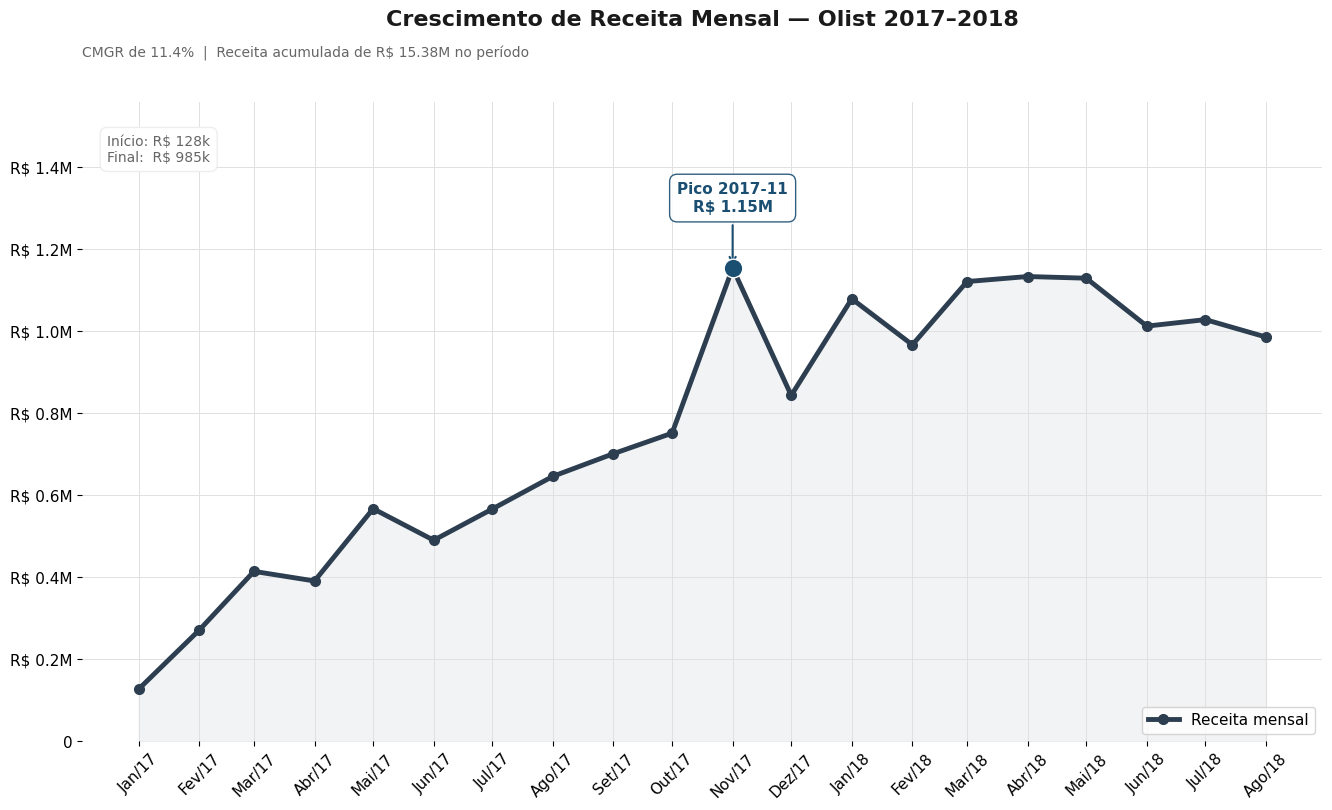

In [99]:
#Gráfico - Receita Mensal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    tabela_receita_mensal
    .copy()
    .loc[tabela_receita_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = pd.to_datetime(df_plot['ano_mes'].astype(str))

# --- Métricas ---
val_inicial   = df_plot['receita_total'].iloc[0]
val_final     = df_plot['receita_total'].iloc[-1]
multiplo      = val_final / val_inicial
n_meses       = len(df_plot) - 1
cmgr          = (multiplo) ** (1 / n_meses) - 1
receita_total = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']
mes_pico  = df_plot.loc[idx_pico, 'ano_mes']

# --- Cores ---
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'

# --- Visualização ---
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
#ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- Caixa de resumo ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal:  R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# --- Linha de receita ---
ax.plot(
    df_plot['data'], df_plot['receita_total'],
    color=AZUL_ESCURO, lw=3.5, marker='o', markersize=7,
    label='Receita mensal', zorder=4
)
ax.fill_between(df_plot['data'], df_plot['receita_total'], alpha=0.06, color=AZUL_ESCURO)

# --- Anotação de pico ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(
    f'Pico {mes_pico}\nR$ {val_pico/1e6:.2f}M',
    xy=(data_pico, val_pico),
    xytext=(data_pico, val_pico * 1.12),
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
    ha='center', fontweight='bold', color=COR_PICO,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9)
)

# --- Eixos ---
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"
))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))
plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- Títulos à esquerda ---
ax.text(
    0.5, 1.12,
    'Crescimento de Receita Mensal — Olist 2017–2018',
    transform=ax.transAxes, fontsize=16, fontweight='bold',
    color=CINZA_TEXTO, ha='center'
)

ax.text(
    0, 1.07,
    f'CMGR de {cmgr*100:.1f}%  |  Receita acumulada de R$ {receita_total/1e6:.2f}M no período',
    transform=ax.transAxes, fontsize=10, color=CINZA_SUB, ha='left'
)

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)
plt.subplots_adjust(top=0.82)
plt.show()

##### **Ticket Médio**

**Objetivo:** Avaliar a variação do valor médio por pedido ao longo do tempo, refletindo mudanças no comportamento de compra e no mix de produtos.

**Lógica:**
- Ticket médio = receita total ÷ número de pedidos entregues no período.
- Utiliza a tabela agregada de receita mensal (derivada do Crescimento da Receita Mensal ), evitando reprocessamento e garantindo consistência.
- Calculado mensalmente para permitir análise de tendência.


In [100]:
# --- KPI 2: Ticket Médio ao Longo do Tempo (Mensal) ---

# 1. Utilizamos a tabela_receita_mensal já calculado no KPI receita mensal

# 2. Calculamos o ticket médio mensal (Receita / Quantidade de Pedidos)
tabela_receita_mensal['ticket_medio'] = tabela_receita_mensal['receita_total'] / tabela_receita_mensal['qtd_pedidos']

# --- RESULTADOS ---
print(f"{'='*20} KPI 2: TICKET MÉDIO {'='*20}")

# Calculamos a média real baseada no total de pedidos entregues do df_receita
ticket_medio_geral = df_receita['payment_value'].sum() / df_receita['order_id'].nunique()

print(f"Ticket médio geral (Período Total): R$ {ticket_medio_geral:,.2f}")
print(f"{'='*53}")

# Exibindo as colunas principais
tabela_receita_mensal[['ano_mes', 'qtd_pedidos', 'receita_total', 'ticket_medio']].head(10)

==================== KPI 2: TICKET MÉDIO ====================
Ticket médio geral (Período Total): R$ 159.81


,ano_mes,qtd_pedidos,receita_total,ticket_medio
0,2017-01,750,127545.67,170.060893
1,2017-02,1653,271298.65,164.125015
2,2017-03,2546,414369.39,162.753099
3,2017-04,2303,390952.18,169.757785
4,2017-05,3546,567066.73,159.917296
5,2017-06,3135,490225.60,156.371802
6,2017-07,3872,566403.93,146.282007
7,2017-08,4193,646000.61,154.066446
8,2017-09,4150,701169.99,168.956624
9,2017-10,4478,751140.27,167.740123


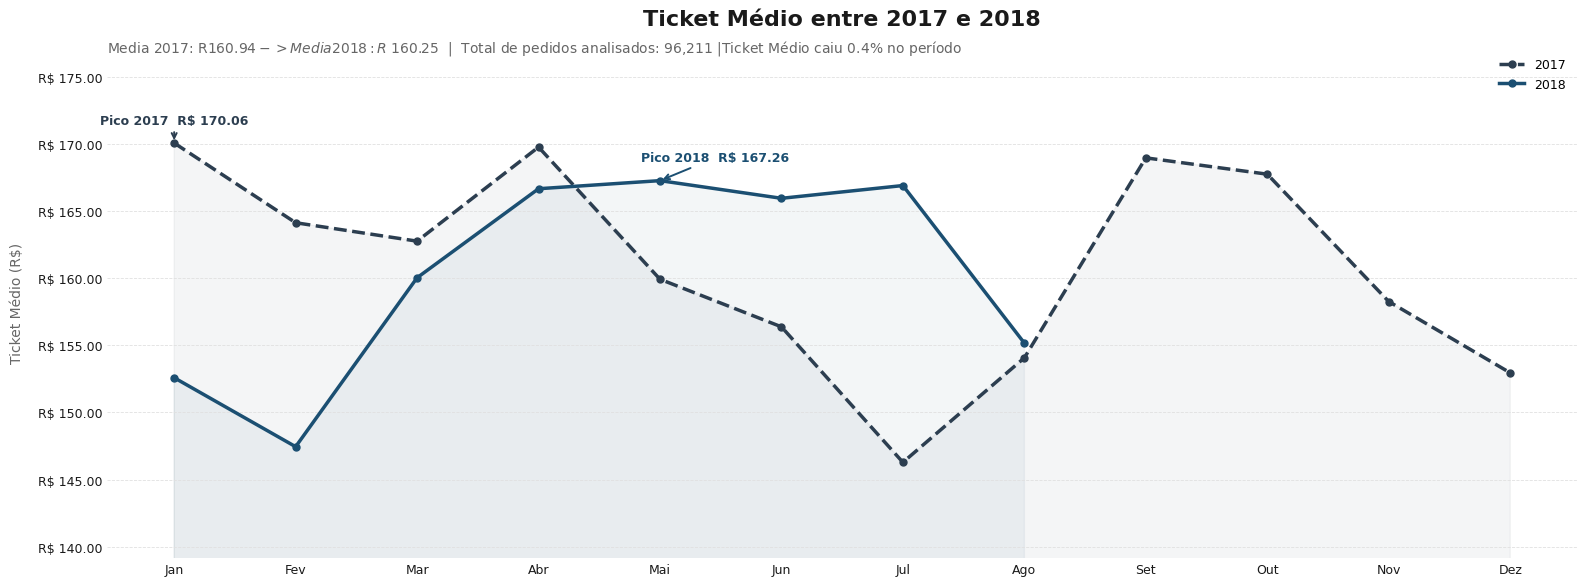

In [101]:
# --- KPI 2: Gráfico Ticket Médio ao Longo do Tempo (Mensal) ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()
df_plot['ano'] = df_plot['ano_mes_dt'].dt.year
df_plot['mes'] = df_plot['ano_mes_dt'].dt.month

df_2017 = df_plot[df_plot['ano'] == 2017].reset_index(drop=True)
df_2018 = df_plot[df_plot['ano'] == 2018].reset_index(drop=True)

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017   = df_2017['ticket_medio'].mean()
ticket_2018   = df_2018['ticket_medio'].mean()
variacao_pct  = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao       = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos = df_plot['qtd_pedidos'].sum()

idx_pico_2017 = df_2017['ticket_medio'].idxmax()
idx_pico_2018 = df_2018['ticket_medio'].idxmax()

meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Linha 2017 ────────────────────────────────────────────────────────────────
ax.plot(
    df_2017['mes'], df_2017['ticket_medio'],
    color=AZUL_ESCURO, linewidth=2.5, linestyle='--',
    marker='o', markersize=5, label='2017', zorder=3,
)
ax.fill_between(df_2017['mes'], df_2017['ticket_medio'], alpha=0.05, color=AZUL_ESCURO)

# ── Linha 2018 ────────────────────────────────────────────────────────────────
ax.plot(
    df_2018['mes'], df_2018['ticket_medio'],
    color=COR_PICO, linewidth=2.5,
    marker='o', markersize=5, label='2018', zorder=3,
)
ax.fill_between(df_2018['mes'], df_2018['ticket_medio'], alpha=0.05, color=COR_PICO)


# ── Anotação pico 2017 ────────────────────────────────────────────────────────
ax.annotate(
    f"Pico 2017  R$ {df_2017.loc[idx_pico_2017, 'ticket_medio']:,.2f}",
    xy=(df_2017.loc[idx_pico_2017, 'mes'], df_2017.loc[idx_pico_2017, 'ticket_medio']),
    xytext=(0, 14),
    textcoords='offset points',
    ha='center', fontsize=9, fontweight='bold', color=AZUL_ESCURO,
    arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.4),
)

# ── Anotação pico 2018 ────────────────────────────────────────────────────────
ax.annotate(
    f"Pico 2018  R$ {df_2018.loc[idx_pico_2018, 'ticket_medio']:,.2f}",
    xy=(df_2018.loc[idx_pico_2018, 'mes'], df_2018.loc[idx_pico_2018, 'ticket_medio']),
    xytext=(40, 14),
    textcoords='offset points',
    ha='center', fontsize=9, fontweight='bold', color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_pt, fontsize=9, color=CINZA_TEXTO)
ax.tick_params(axis='y', labelsize=9, colors=CINZA_TEXTO, length=0)
ax.tick_params(axis='x', length=0)

# Limites Y com respiro
margem = (df_plot['ticket_medio'].max() - df_plot['ticket_medio'].min()) * 0.30
ax.set_ylim(
    df_plot['ticket_medio'].min() - margem,
    df_plot['ticket_medio'].max() + margem,
)

# ── Grid e bordas ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.set_ylabel('Ticket Médio (R$)', fontsize=10, color=CINZA_SUB, labelpad=10)

# ── Títulos ───────────────────────────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio entre 2017 e 2018',
    fontsize=16, fontweight='bold', color=CINZA_TEXTO, pad=16, loc='center',
)
ax.text(
    0, 0.98,
    f'Media 2017: R$ {ticket_2017:,.2f}  ->  Media 2018: R$ {ticket_2018:,.2f}  |  '
    f'Total de pedidos analisados: {total_pedidos:,.0f} |'
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}% no período',
    transform=ax.transAxes, fontsize=10, color=CINZA_SUB, va='bottom',
)

ax.legend(fontsize=9, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('ticket_medio_olist.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
import pandas as pd

# 1. Garantimos que temos uma coluna de data real para extrair o mês e o ano
tabela_receita_mensal['data'] = pd.to_datetime(tabela_receita_mensal['ano_mes'].astype(str))
tabela_receita_mensal['ano'] = tabela_receita_mensal['data'].dt.year
tabela_receita_mensal['mes'] = tabela_receita_mensal['data'].dt.month

# 2. Criamos o filtro mágico: Apenas meses de Janeiro (1) a Agosto (8)
df_jan_ago = tabela_receita_mensal[tabela_receita_mensal['mes'] <= 8].copy()

# 3. Calculamos o Ticket Médio Justo para 2017 (Jan a Ago)
df_2017_ytd = df_jan_ago[df_jan_ago['ano'] == 2017]
ticket_2017_ytd = df_2017_ytd['receita_total'].sum() / df_2017_ytd['qtd_pedidos'].sum()

# 4. Calculamos o Ticket Médio Justo para 2018 (Jan a Ago)
df_2018_ytd = df_jan_ago[df_jan_ago['ano'] == 2018]
ticket_2018_ytd = df_2018_ytd['receita_total'].sum() / df_2018_ytd['qtd_pedidos'].sum()

# 5. Calculamos a variação percentual real
variacao_ytd = ((ticket_2018_ytd / ticket_2017_ytd) - 1) * 100

# --- RESULTADOS EXECUTIVOS ---
print(f"\n{'='*20} COMPARAÇÃO JUSTA (JAN a AGO) {'='*20}")
print(f"Ticket Médio 2017 (Jan-Ago): R$ {ticket_2017_ytd:,.2f}")
print(f"Ticket Médio 2018 (Jan-Ago): R$ {ticket_2018_ytd:,.2f}")

if variacao_ytd > 0:
    print(f"Resultado: CRESCIMENTO REAL de {variacao_ytd:.2f}% no Ticket Médio!")
else:
    print(f"Resultado: QUEDA REAL de {abs(variacao_ytd):.2f}% no Ticket Médio.")
print(f"{'='*70}")


==================== COMPARAÇÃO JUSTA (JAN a AGO) ====================
Ticket Médio 2017 (Jan-Ago): R$ 157.92
Ticket Médio 2018 (Jan-Ago): R$ 160.15
Resultado: CRESCIMENTO REAL de 1.41% no Ticket Médio!


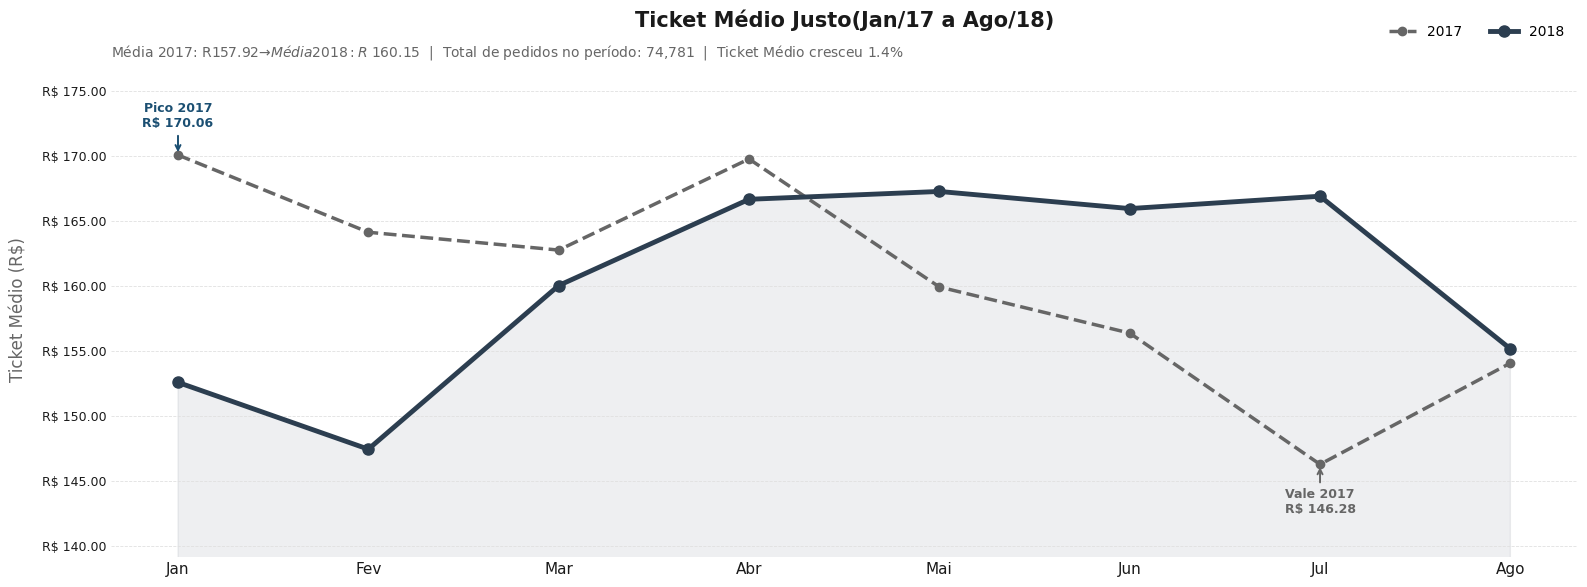

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados (Filtro Justo: Jan a Ago) ────────────────────────────
df_plot = tabela_receita_mensal.copy()
# Garantimos a extração correta de ano e mês
df_plot['ano_mes_dt'] = pd.to_datetime(df_plot['ano_mes'].astype(str))
df_plot['ano'] = df_plot['ano_mes_dt'].dt.year
df_plot['mes'] = df_plot['ano_mes_dt'].dt.month

# FILTRO MÁGICO: Apenas meses de Janeiro (1) a Agosto (8)
df_justo = df_plot[(df_plot['mes'] <= 8) & (df_plot['ano'].isin([2017, 2018]))].copy()

# Separamos as bases de cada ano
df_2017 = df_justo[df_justo['ano'] == 2017].sort_values('mes')
df_2018 = df_justo[df_justo['ano'] == 2018].sort_values('mes')

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017 = df_2017['receita_total'].sum() / df_2017['qtd_pedidos'].sum()
ticket_2018 = df_2018['receita_total'].sum() / df_2018['qtd_pedidos'].sum()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos = df_justo['qtd_pedidos'].sum()
ticket_medio_geral = df_justo['ticket_medio'].mean()

# Encontrando o Pico e Vale absolutos dentro do período justo
row_pico = df_justo.loc[df_justo['ticket_medio'].idxmax()]
row_vale = df_justo.loc[df_justo['ticket_medio'].idxmin()]

# Lista de meses para usar no eixo X
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago']

# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 1. Linha 2017 (Tracejada, servindo como base de comparação)
ax.plot(
    meses_nomes,
    df_2017['ticket_medio'],
    color=CINZA_SUB,
    linewidth=2.5,
    linestyle='--',
    marker='o',
    markersize=6,
    zorder=3,
    label='2017'
)

# 2. Linha 2018 (Sólida, cor principal)
ax.plot(
    meses_nomes,
    df_2018['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=3.5,
    marker='o',
    markersize=8,
    zorder=4,
    label='2018'
)

# Área sob a curva apenas para 2018 (para dar destaque ao ano atual)
ax.fill_between(
    meses_nomes,
    df_2018['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# Linha de média tracejada em LARANJA (Média do período todo)
'''ax.axhline(
    ticket_medio_geral,
    color=LARANJA,
    linewidth=1.4,
    linestyle='--',
    zorder=2,
    label=f'Média Jan-Ago  R$ {ticket_medio_geral:,.2f}',
)'''

# ── Anotações Dinâmicas (Pico e Vale) ──────────────────────────────────────────
# Pegamos o nome do mês na lista usando o número do mês (-1 porque lista começa em 0)
x_pico = meses_nomes[int(row_pico['mes']) - 1]
ax.annotate(
    f"Pico {int(row_pico['ano'])}\nR$ {row_pico['ticket_medio']:,.2f}",
    xy=(x_pico, row_pico['ticket_medio']),
    xytext=(0, 20),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

x_vale = meses_nomes[int(row_vale['mes']) - 1]
ax.annotate(
    f"Vale {int(row_vale['ano'])}\nR$ {row_vale['ticket_medio']:,.2f}",
    xy=(x_vale, row_vale['ticket_medio']),
    xytext=(0, -35),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos e Estilização ────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))

plt.xticks(fontsize=11, color=CINZA_TEXTO)
plt.yticks(fontsize=9, color=CINZA_TEXTO)

# Limites Y com respiro
margem = (df_justo['ticket_medio'].max() - df_justo['ticket_medio'].min()) * 0.3
ax.set_ylim(
    df_justo['ticket_medio'].min() - margem,
    df_justo['ticket_medio'].max() + margem,
)

# Grid leve
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos com insight dinâmico ───────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio Justo(Jan/17 a Ago/18)',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=25,
    loc='center',
)
ax.text(
    0, 1.0,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f}  |  Total de pedidos no período: {total_pedidos:,.0f}  |  '
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}%',
    transform=ax.transAxes,
    fontsize=10,
    color=CINZA_SUB,
    va='bottom',
)
ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=12, color=CINZA_SUB, labelpad=10)

# Legenda ajustada
ax.legend(
    fontsize=10,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.1), # Joga a legenda lá pro cantinho superior direito
    ncol=3
)

plt.tight_layout()
plt.savefig('ticket_medio_justo_olist.png', dpi=150, bbox_inches='tight')
plt.show()

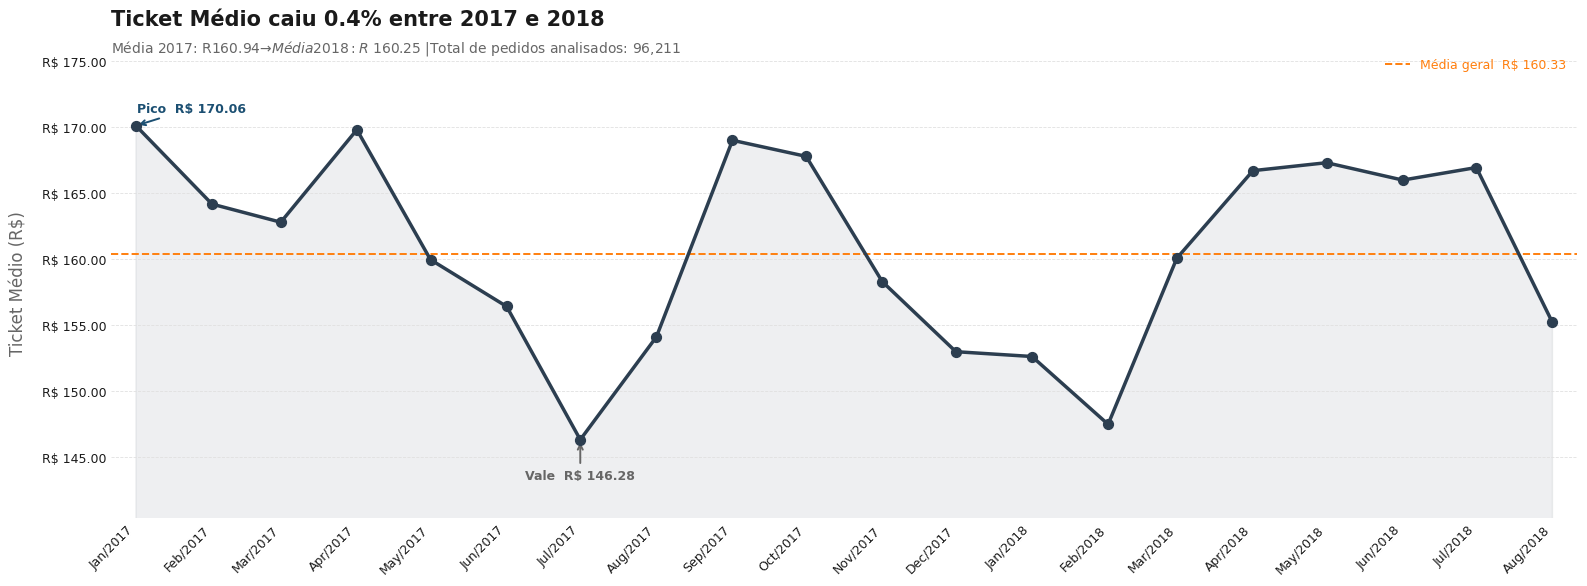

In [104]:
# --- KPI 2: Gráfico Ticket Médio ao Longo do Tempo (Mensal) ---

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()

idx_pico = df_plot['ticket_medio'].idxmax()
idx_vale = df_plot['ticket_medio'].idxmin()

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017 = df_plot[df_plot['ano_mes_dt'].dt.year == 2017]['ticket_medio'].mean()
ticket_2018 = df_plot[df_plot['ano_mes_dt'].dt.year == 2018]['ticket_medio'].mean()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos= df_plot['qtd_pedidos'].sum()
# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Linha principal
ax.plot(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=2.5,
    zorder=3,
)

# Marcadores
ax.scatter(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    s=50,
    zorder=4,
)

# Linha de média tracejada em LARANJA
ax.axhline(
    ticket_medio_geral,
    color=LARANJA,
    linewidth=1.4,
    linestyle='--',
    zorder=2,
    label=f'Média geral  R$ {ticket_medio_geral:,.2f}',
)

# Área sob a curva
ax.fill_between(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# ── Anotação Pico ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Pico  R$ {df_plot.loc[idx_pico, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_pico, 'ano_mes_dt'], df_plot.loc[idx_pico, 'ticket_medio']),
    xytext=(40, 10),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

# ── Anotação Vale ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Vale  R$ {df_plot.loc[idx_vale, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_vale, 'ano_mes_dt'], df_plot.loc[idx_vale, 'ticket_medio']),
    xytext=(0, -28),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))

plt.xticks(rotation=45, ha='right', fontsize=9, color=CINZA_TEXTO)
plt.yticks(fontsize=9, color=CINZA_TEXTO)

# Limites Y com respiro
margem = (df_plot['ticket_medio'].max() - df_plot['ticket_medio'].min()) * 0.25
ax.set_ylim(
    df_plot['ticket_medio'].min() - margem,
    df_plot['ticket_medio'].max() + margem,
)

# Limites X com respiro lateral
ax.set_xlim(
    df_plot['ano_mes_dt'].min() - pd.DateOffset(days=10),
    df_plot['ano_mes_dt'].max() + pd.DateOffset(days=10),
)

# ── Grid leve ─────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos com insight dinâmico ───────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}% entre 2017 e 2018',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=16,
    loc='left',
)
ax.text(
    0, 0.98,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f} |'
    f'Total de pedidos analisados: {total_pedidos:,.0f}',
    transform=ax.transAxes,
    fontsize=10,
    color=CINZA_SUB,
    va='bottom',

)


ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=12, color=CINZA_SUB, labelpad=10)

ax.legend(
    fontsize=9,
    frameon=False,
    loc='upper right',
    labelcolor=LARANJA,
)

plt.tight_layout()
plt.savefig('ticket_medio_olist.png', dpi=150, bbox_inches='tight')
plt.show()

##### **Receita por Categoria**

**Objetivo:** Identificar quais categorias sustentam o negócio.

**Lógica:**
- Cruza `df_itens_pedido` → `df_pedidos` (filtrando apenas pedidos entregues) → df_produtos, garantindo que apenas receita realizada seja considerada.
- A receita de categoria usa o campo `price` do item (valor do produto sem frete), que é a fonte mais fiel para comparar categorias de produto — o `payment_value` em pagamentos já agrega frete e múltiplos itens.
- Também traz a receita incluindo frete como variação opcional.

In [105]:
# KP3 - Receita por Categoria

df_itens_pedido = pd.read_csv('/content/olist_order_items_dataset.csv', encoding='utf-8')
df_produtos = pd.read_csv('/content/olist_products_dataset.csv',encoding='utf-8')
df_pedidos = pd.read_csv('/content/olist_orders_dataset.csv',encoding='utf-8')

df_produtos['product_category_clean'] = (
    df_produtos['product_category_name']
    .replace(mapa_categorias)
    .fillna('sem_categoria')

)

df_itens_pcategoria = pd.merge(df_itens_pedido, df_pedidos[['order_id', 'order_status','order_purchase_timestamp']], on='order_id', how='inner')
df_itens_pcategoria = pd.merge(df_itens_pcategoria, df_produtos[['product_id', 'product_category_clean']], on='product_id', how='left')

df_itens_pcategoria[df_itens_pcategoria['order_status'] == 'delivered']
df_itens_pcategoria['order_purchase_timestamp'] = pd.to_datetime(df_itens_pcategoria['order_purchase_timestamp'])


# Excluindo o ano de 2016
df_itens_pcategoria = df_itens_pcategoria[df_itens_pcategoria['order_purchase_timestamp'].dt.year != 2016]


#
# Calculamos a Receita por Categoria

tabela_categorias = (
    df_itens_pcategoria
    .groupby('product_category_clean', as_index=False)
    .agg(receita_produtos=('price', 'sum'))
    .sort_values('receita_produtos', ascending=False)
)

tabela_categorias.head(10)

# receita total de TODAS as categorias juntas
receita_total_absoluta = tabela_categorias['receita_produtos'].sum()

# Top 10 e criamos a coluna de porcentagem
tabela_top10 = tabela_categorias.head(10).copy()
tabela_top10['porcentagem'] = (tabela_top10['receita_produtos'] / receita_total_absoluta) * 100

In [106]:
tabela_top10

,product_category_clean,receita_produtos,porcentagem
8,beleza_saude,1253993.86,9.260132
36,relogios_presentes,1201645.44,8.873564
26,informatica,1142592.49,8.437487
32,moveis,1136183.32,8.390158
10,cama_mesa_banho,1036509.69,7.654117
21,esporte_lazer,984715.33,7.271641
17,cool_stuff,634179.85,4.683108
40,utilidades_domesticas,630961.59,4.659343
5,automotivo,590886.86,4.363411
22,ferramentas_jardim,483896.58,3.573340


In [107]:
tabela_categorias['receita_produtos'].sum()

np.float64(13541857.78)

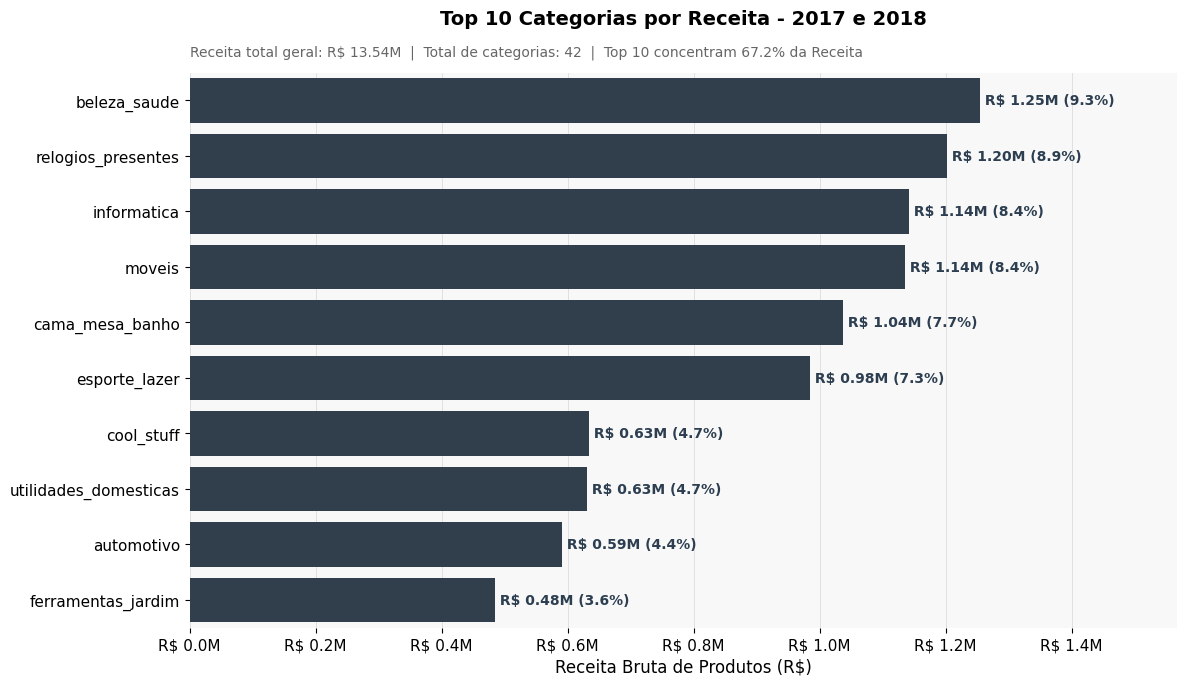

In [108]:
# KP3 - Gráfico de Receita por Categoria

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

receita_total_geral = tabela_categorias['receita_produtos'].sum()
n_categorias        = tabela_categorias['product_category_clean'].nunique()

# Usamos a coluna correta 'receita_produtos' da tabela_top10
top10_share = tabela_top10['receita_produtos'].sum() / receita_total_geral * 100

plt.figure(figsize=(12, 7))

sns.barplot(
    data=tabela_top10,
    y='product_category_clean',
    x='receita_produtos',
    color='#2c3e50'
)

for bar in plt.gca().patches:
    bar.set_zorder(3)

plt.title('Top 10 Categorias por Receita - 2017 e 2018', fontsize=14, fontweight='bold', pad=35)
plt.xlabel('Receita Bruta de Produtos (R$)', fontsize=12)
plt.ylabel('', fontsize=12)

# Formatando o eixo X para Milhões
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x/1000000:.1f}M'))

xmax = tabela_top10['receita_produtos'].max()
plt.xlim(0, xmax * 1.25)

# Iterando para colocar os rótulos de dados
for index, row in tabela_top10.reset_index(drop=True).iterrows():
    valor = row['receita_produtos']
    perc = row['porcentagem']
    texto_label = f' R$ {valor/1000000:.2f}M ({perc:.1f}%)'
    plt.text(valor, index, texto_label, va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# Subtítulo corrigido (o texto que você juntou no prompt anterior já estava certinho!)
texto_subtitulo = (
    f"Receita total geral: R$ {receita_total_geral/1e6:.2f}M  |  " +
    f"Total de categorias: {n_categorias}  |  " +
    f"Top 10 concentram {top10_share:.1f}% da Receita"
)

plt.gca().text(
    0, 1.03,
    texto_subtitulo,
    transform=plt.gca().transAxes,
    fontsize=10,
    color='#666666',
    ha='left'
)

plt.tight_layout()
plt.show()

##### **Receita por Estado**

**Objetivo:** Identificar quais estados concentram a receita do negócio e entender a distribuição geográfica das vendas.

**Lógica:**
- Utiliza a base consolidada de pedidos entregues (df_receita), garantindo que apenas receita realizada seja considerada.
- A agregação é feita por estado do cliente (customer_state), somando separadamente o valor dos produtos (price) e do frete (freight_value).
- Como a base está em nível de pedido (1 linha por order_id), as somas representam corretamente a receita total por estado e o count('order_id') reflete o número de pedidos.
- A receita total é calculada como a soma de produtos e frete, permitindo analisar tanto o valor comercial quanto o impacto logístico.


In [109]:
# --- KPI 4: Receita por Estado ---

# 1. Base usada nos indicadores anteriores de Receita

# 2. Tratamos categorias ausentes (Data Cleaning dentro do KPI)

# Usaremos 'product_category_name_english' que é o nome comum após a tradução
col_categoria = 'customer_state'

if col_categoria in df_receita.columns:
    df_receita[col_categoria] = df_receita[col_categoria].fillna('sem_preenchimento')
else:

    col_categoria = 'customer_state'

# 3. Agregamos os valores por categoria
# Como a base é consolidada por pedido, price e freight_value já são os totais do pedido
tabela_receita_por_estado = (
    df_receita
    .groupby(col_categoria, as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_frete=('freight_value', 'sum'),
        qtd_pedidos=('order_id', 'count') # Cada linha é um pedido único
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 4: RECEITA POR ESTADO {'='*20}")
print(f"Total de Estados Analisados: {tabela_receita_por_estado[col_categoria].nunique()}")
print(f"Receita da categoria 'sem_categoria': R$ {tabela_receita_por_estado.loc[tabela_receita_por_estado[col_categoria]=='sem_preenchimento', 'receita_total'].sum():,.2f}")
print(f"{'='*60}")

tabela_receita_por_estado.head(15)

==================== KPI 4: RECEITA POR ESTADO ====================
Total de Estados Analisados: 27
Receita da categoria 'sem_categoria': R$ 0.00


,customer_state,receita_produtos,receita_frete,qtd_pedidos,receita_total
0,SP,5055587.13,700412.63,40406,5755999.76
1,RJ,1751433.85,294923.79,12310,2046357.64
2,MG,1548206.88,265747.39,11319,1813954.27
3,RS,726373.92,132200.76,5328,858574.68
4,PR,664048.00,115166.08,4903,779214.08
5,SC,504774.07,87852.99,3537,592627.06
6,BA,493339.26,97477.54,3253,590816.80
7,DF,295454.64,49468.60,2074,344923.24
8,GO,281932.21,51224.02,1950,333156.23
9,ES,267783.66,48882.46,1992,316666.12


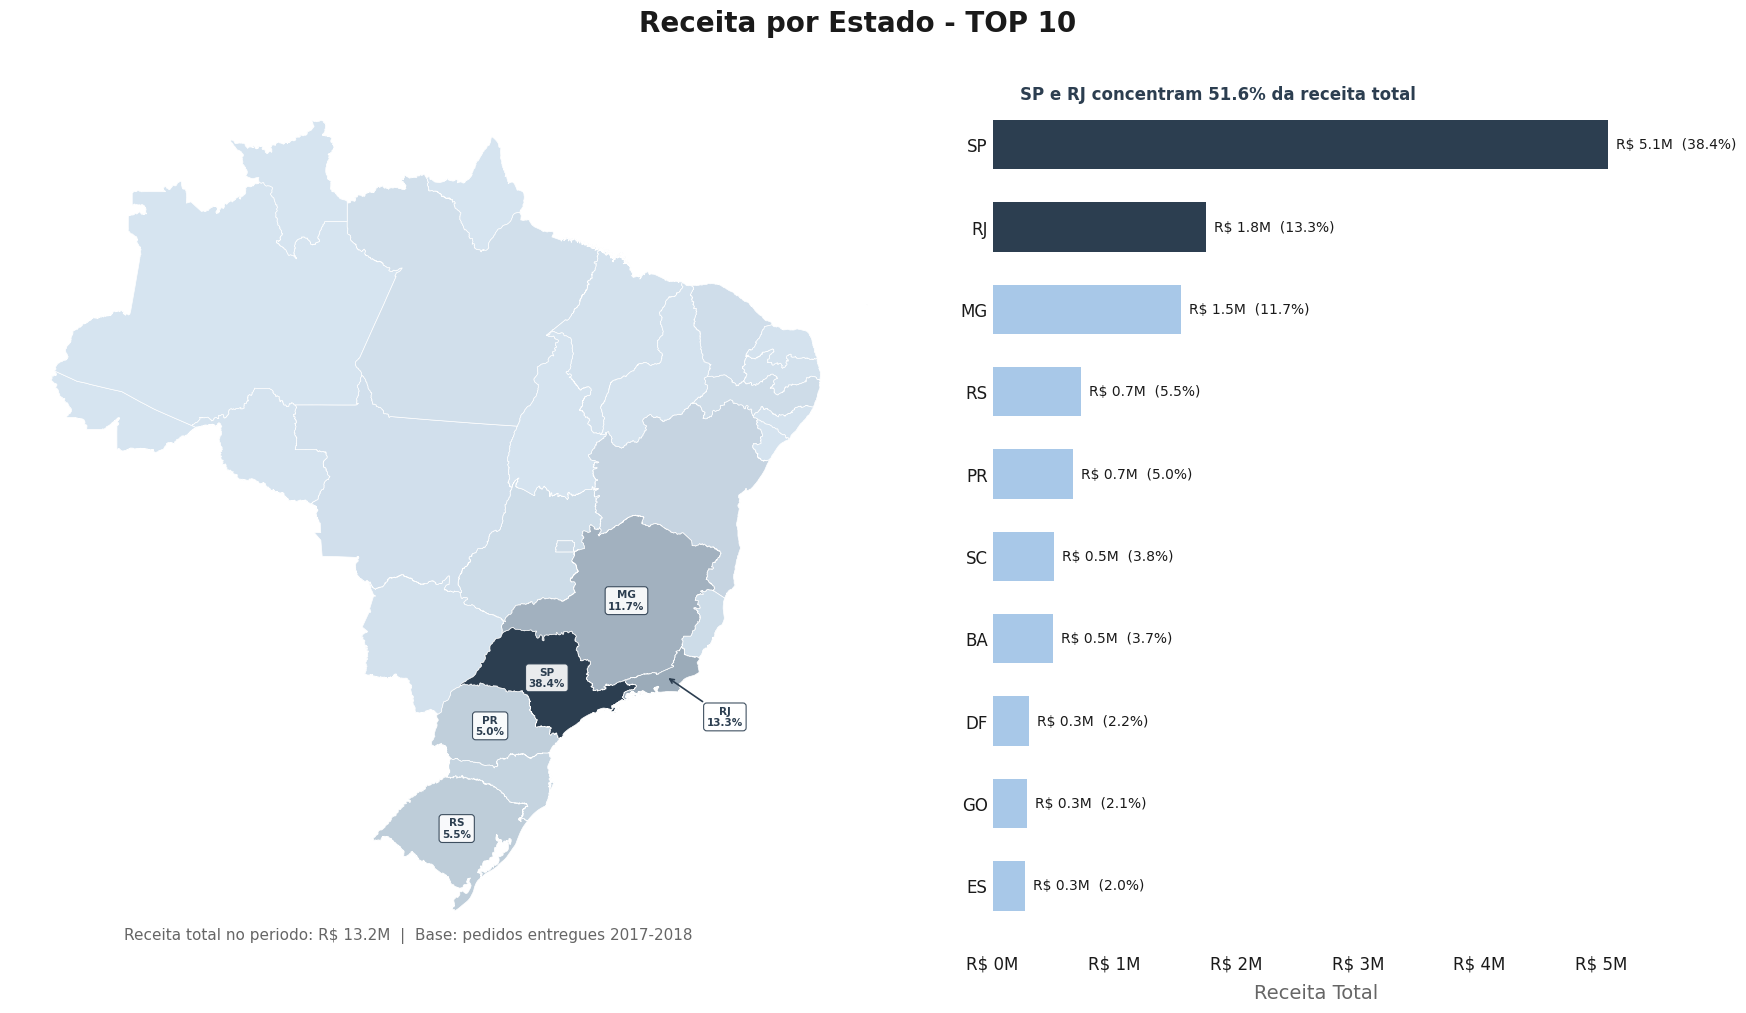

In [110]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import requests
import io

#Avisos
import warnings
warnings.filterwarnings('ignore')

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
AZUL_CLARO  = '#a8c8e8'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Baixa o shapefile do Brasil por estado ────────────────────────────────────
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
response = requests.get(url)
gdf = gpd.read_file(io.BytesIO(response.content))

gdf = gdf.rename(columns={'sigla': 'customer_state'})

# ── Merge com a tabela de receita ─────────────────────────────────────────────
gdf_merged = gdf.merge(tabela_receita_por_estado[['customer_state', 'receita_produtos']],
                        on='customer_state', how='left')
gdf_merged['receita_produtos'] = gdf_merged['receita_produtos'].fillna(0)

# ── Insight para o título ─────────────────────────────────────────────────────
receita_produtos_geral = tabela_receita_por_estado['receita_produtos'].sum()
top2 = tabela_receita_por_estado.head(2)
top2_receita = top2['receita_produtos'].sum()
top2_pct = (top2_receita / receita_produtos_geral) * 100
top2_estados = ' e '.join(top2['customer_state'].tolist())

# ── Top 10 para o bar chart ───────────────────────────────────────────────────
df_top10 = tabela_receita_por_estado.head(10).sort_values('receita_produtos', ascending=True)

# ── Canvas: Mapa + Bar Chart ──────────────────────────────────────────────────
fig, (ax_mapa, ax_bar) = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={'width_ratios': [1.5, 1]}
)
fig.patch.set_facecolor('white')

# ────────────────────────────────────────────────────────────────────────────
# MAPA
# ────────────────────────────────────────────────────────────────────────────
ax_mapa.set_facecolor('white')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'azul_gradiente', ['#d6e4f0', AZUL_ESCURO]
)

gdf_merged.plot(
    column='receita_produtos',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='white',
    ax=ax_mapa,
    legend=False,
)

# Anotação dos Top 5 estados no mapa
# Anotação dos Top 5 estados no mapa
top5 = tabela_receita_por_estado.head(5)

# Offsets customizados para estados pequenos
offsets = {
    'SP': (0, 0),
    'RJ': (3,-2),
    'MG': (0, 0),
    'RS': (0, 0),
    'PR': (0, 0),
}

for _, row in top5.iterrows():
    estado = row['customer_state']
    pct = (row['receita_produtos'] / receita_produtos_geral) * 100
    geo_row = gdf_merged[gdf_merged['customer_state'] == estado]
    if not geo_row.empty:
        centroid = geo_row.geometry.centroid.iloc[0]
        ox, oy = offsets.get(estado, (0, 0))

        ax_mapa.annotate(
            f"{estado}\n{pct:.1f}%",
            xy=(centroid.x, centroid.y),
            xytext=(centroid.x + ox, centroid.y + oy),
            ha='center', va='center',
            fontsize=7.5,
            fontweight='bold',
            color=AZUL_ESCURO,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AZUL_ESCURO, lw=0.8, alpha=0.9),
            arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.2),
        )


ax_mapa.set_axis_off()

# ────────────────────────────────────────────────────────────────────────────
# BAR CHART HORIZONTAL — Top 10
# ────────────────────────────────────────────────────────────────────────────
ax_bar.set_facecolor('white')

cores_bar = [AZUL_ESCURO if i >= len(df_top10) - 2 else AZUL_CLARO
             for i in range(len(df_top10))]

bars = ax_bar.barh(
    df_top10['customer_state'],
    df_top10['receita_produtos'],
    color=cores_bar,
    edgecolor='none',
    height=0.6,
)

# Rótulo de valor nas barras
# Rótulo de valor e percentual nas barras
for bar, val in zip(bars, df_top10['receita_produtos']):
    pct = (val / receita_produtos_geral) * 100
    ax_bar.text(
        bar.get_width() + receita_produtos_geral * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e6:.1f}M  ({pct:.1f}%)',
        va='center',
        fontsize=10,
        color=CINZA_TEXTO,
    )

ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax_bar.tick_params(axis='both', length=0, labelsize=12, colors=CINZA_TEXTO)
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.spines['left'].set_color('#cccccc')
ax_bar.xaxis.grid(False )
ax_bar.yaxis.grid(False)
ax_bar.set_xlabel('Receita Total', fontsize=14, color=CINZA_SUB, labelpad=8)
#ax_bar.set_title('Top 10 Estados', fontsize=11, fontweight='bold',
                  #color=CINZA_TEXTO, loc='left', pad=10)

# ── Título principal orientado a insight ─────────────────────────────────────
fig.suptitle(
    #f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    f'Receita por Estado - TOP 10',
    fontsize=20,
    fontweight='bold',
     color= CINZA_TEXTO,
    x=0.5,
    ha='center',
    y=1.01,


)
# 1. Informações técnicas (Alinhado à esquerda)
fig.text(
    0.25, 0.08,
    f'Receita total no periodo: R$ {receita_produtos_geral/1e6:.1f}M  |  Base: pedidos entregues 2017-2018',
    fontsize=11,
    color=CINZA_SUB,
    ha='center' # "ha" significa Horizontal Alignment
)

# 2. destacado (Alinhado à direita)
fig.text(
    0.70, 0.92, # O 'x' no 0.98 empurra o texto lá para a ponta direita
    f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    fontsize=12,
    fontweight='bold', # Deixa em negrito
    color=AZUL_ESCURO, # Puxa o seu Azul Marinho da paleta (#2c3e50)
    ha='center' # Alinha pela direita para não vazar da tela
)

plt.tight_layout()
plt.savefig('receita_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

In [111]:
tabela_categorias = (
    df_itens_pcategoria
    .groupby('product_category_clean', as_index=False)
    .agg(
        # 1. Receita Real da Categoria (O que define o Ranking)
        receita_produtos=('price', 'sum'),

        # 2. Custo Logístico atrelado à categoria
        receita_frete=('freight_value', 'sum'),

        # 3. Volume de saída
        qtde_vendida=('order_item_id', 'count')
    )
    # Ordena a tabela exclusivamente pelo valor dos produtos
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# Criando uma coluna extra de análise de impacto logístico
tabela_categorias['%_impacto_frete'] = (tabela_categorias['receita_frete'] / tabela_categorias['receita_produtos']) * 100

print(tabela_categorias.head(10))

  product_category_clean  receita_produtos  receita_frete  qtde_vendida  \
0           beleza_saude        1253993.86      181617.37          9619   
1     relogios_presentes        1201645.44      100428.13          5986   
2            informatica        1142592.49      158173.38          8101   
3                 moveis        1136183.32      275957.14         10881   
4        cama_mesa_banho        1036509.69      204565.45         11107   
5          esporte_lazer         984715.33      168014.04          8622   
6             cool_stuff         634179.85       83822.99          3788   
7  utilidades_domesticas         630961.59      145893.64          6952   
8             automotivo         590886.86       92239.90          4223   
9     ferramentas_jardim         483896.58       98857.44          4342   

   %_impacto_frete  
0        14.483115  
1         8.357551  
2        13.843376  
3        24.288082  
4        19.735990  
5        17.062194  
6        13.217542  
7     

### **8.2 Logística e SLA**

##### **Tempo Médio por Etapa (Compra → Aprovação → Postagem → Entrega)**

**Objetivo:** Medir eficiência operacional e logística.

**Lógica:**

- Tempo de aprovação = `order_approved_at` - `order_purchase_timestamp` (em horas)
- Tempo de despacho = `order_delivered_carrier_date` - `order_approved_at` (em dias)
- Tempo de transporte = `order_delivered_customer_date` − `order_purchase_timestamp` (em dias).
- Tempo de entrega = Tempo de aprovação + Tempo de despacho + Tempo de transporte

Usa apenas pedidos com order_status == 'delivered' e datas de entrega não nulas.
Calculado mensalmente para identificar evolução.

In [112]:
# --- KPI 4.1: Tempo Médio por Etapa ---

# 1. Preparação da base (reaproveitando o filtro de entregues e não nulos)
# Adicionamos as colunas necessárias para as etapas
colunas_etapas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

df_kpi4_1 = df_consolidado[
    (df_consolidado['order_status'] == 'delivered') &
    (df_consolidado[colunas_etapas].notna().all(axis=1))
].copy()

# 2. Conversão para datetime
for col in colunas_etapas:
    df_kpi4_1[col] = pd.to_datetime(df_kpi4_1[col])

# 3. Cálculo das etapas
# Tempo de aprovação: em HORAS (geralmente é rápido)
df_kpi4_1['horas_aprovacao'] = (
    df_kpi4_1['order_approved_at'] - df_kpi4_1['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Tempo de despacho: em DIAS (Aprovação até a Transportadora)
df_kpi4_1['dias_despacho'] = (
    df_kpi4_1['order_delivered_carrier_date'] - df_kpi4_1['order_approved_at']
).dt.total_seconds() / 86400

# Tempo de transporte: em DIAS (Transportadora até Cliente)
df_kpi4_1['dias_transporte'] = (
    df_kpi4_1['order_delivered_customer_date'] - df_kpi4_1['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# 4. Criar Ano-Mês para evolução temporal
df_kpi4_1['ano_mes'] = df_kpi4_1['order_purchase_timestamp'].dt.to_period('M')

# 5. Agrupamento Mensal
df_kpi4_2 = (
    df_kpi4_1
    .groupby('ano_mes', as_index=False)
    .agg(
        avg_horas_aprovacao=('horas_aprovacao', 'mean'),
        avg_dias_despacho=('dias_despacho', 'mean'),
        avg_dias_transporte=('dias_transporte', 'mean'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 4.1: EFICIÊNCIA POR ETAPA {'='*20}")
print(f"Média Horas Aprovação: {df_kpi4_1['horas_aprovacao'].mean():.2f}h")
print(f"Média Dias Despacho:   {df_kpi4_1['dias_despacho'].mean():.2f} dias")
print(f"Média Dias Transporte: {df_kpi4_1['dias_transporte'].mean():.2f} dias")
print(f"{'='*56}")

df_kpi4_2.head(10)

==================== KPI 4.1: EFICIÊNCIA POR ETAPA ====================
Média Horas Aprovação: 10.28h
Média Dias Despacho:   2.80 dias
Média Dias Transporte: 9.33 dias


,ano_mes,avg_horas_aprovacao,avg_dias_despacho,avg_dias_transporte,qtd_pedidos
0,2016-09,0.000000,53.205035,1.608160,1
1,2016-10,20.933260,12.995002,5.733338,265
2,2016-12,0.247222,3.279745,1.402975,1
3,2017-01,11.901211,2.943267,9.203084,748
4,2017-02,9.404674,3.236047,9.541174,1641
5,2017-03,6.063174,2.865149,9.833404,2546
6,2017-04,12.922427,3.144356,11.235122,2303
7,2017-05,9.938396,2.568022,8.340242,3545
8,2017-06,9.468017,2.737343,8.879729,3135
9,2017-07,9.724498,2.704741,8.482804,3872


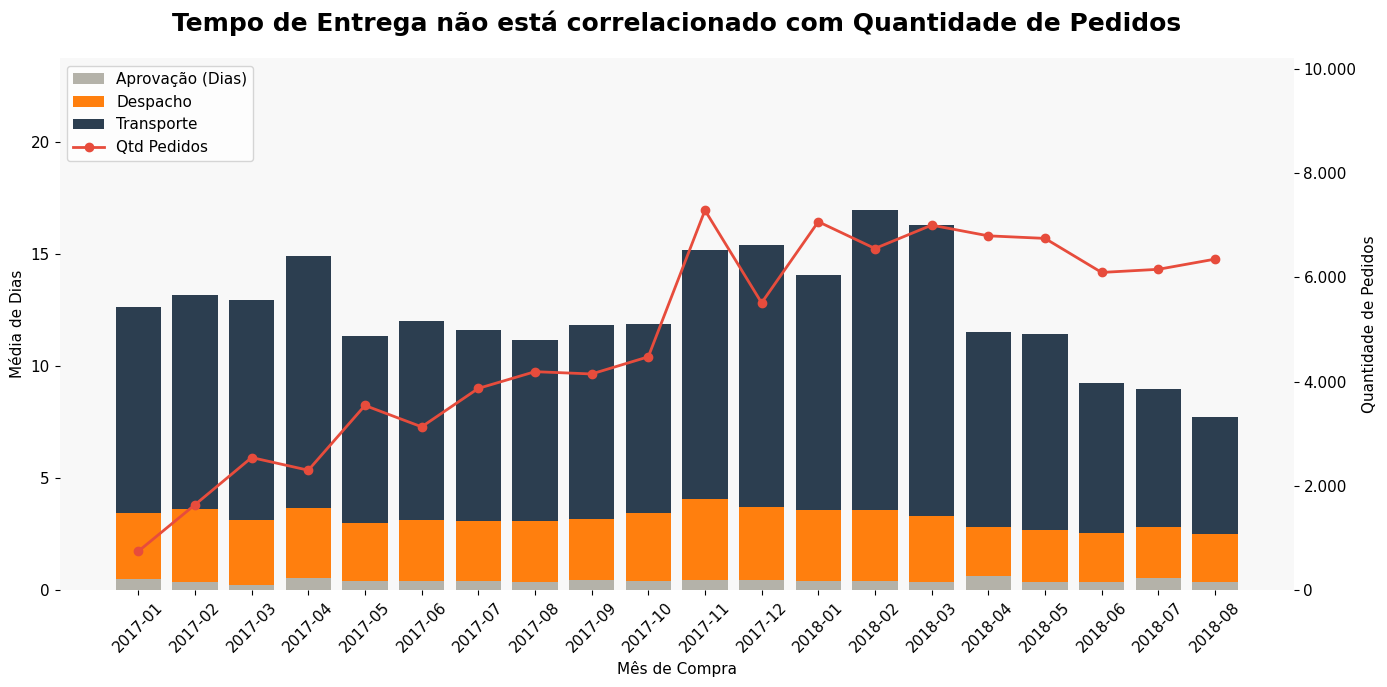

In [113]:
# 1. Preparar os dados
df_plot = df_kpi4_2[df_kpi4_2['ano_mes'] >= '2017-01'].copy()
df_plot['ano_mes'] = df_plot['ano_mes'].astype(str)

# 2. Configurar o gráfico e o primeiro eixo (Barras)
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(df_plot['ano_mes'], df_plot['avg_horas_aprovacao']/24, label='Aprovação (Dias)', color='#B4B2A9')
ax1.bar(df_plot['ano_mes'], df_plot['avg_dias_despacho'],
        bottom=df_plot['avg_horas_aprovacao']/24, label='Despacho', color='#ff7f0e')
ax1.bar(df_plot['ano_mes'], df_plot['avg_dias_transporte'],
        bottom=(df_plot['avg_horas_aprovacao']/24 + df_plot['avg_dias_despacho']), label='Transporte', color='#2c3e50')

# 3. Configurar o segundo eixo (Linha)
ax2 = ax1.twinx()
ax2.plot(df_plot['ano_mes'], df_plot['qtd_pedidos'], color='#E74C3C', marker='o', linewidth=2, label='Qtd Pedidos')

# --- FORMATAÇÃO DO EIXO Y SECUNDÁRIO (7.000) ---
# Usamos lambda para trocar a vírgula do padrão americano por ponto
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))

# --- AJUSTE DE ESPAÇO PARA A LEGENDA ---
max_dias = (df_plot['avg_horas_aprovacao']/24 + df_plot['avg_dias_despacho'] + df_plot['avg_dias_transporte']).max()
ax1.set_ylim(0, max_dias * 1.4)
ax2.set_ylim(0, df_plot['qtd_pedidos'].max() * 1.4)

# Customização Geral
ax1.set_xlabel('Mês de Compra')
ax1.set_ylabel('Média de Dias')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Tempo de Entrega não está correlacionado com Quantidade de Pedidos', fontsize=18, pad=20)
ax2.set_ylabel('Quantidade de Pedidos')

# Remover Grid
ax1.grid(False)
ax2.grid(False)

# Legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()

In [114]:
# 1. Calculamos a correlação entre as duas colunas
correlacao = df_plot['qtd_pedidos'].corr(df_plot['avg_dias_transporte'])

print(f"O índice de correlação de Pearson é: {correlacao:.4f}")

# 2. Criando uma função para interpretar o resultado automaticamente
def interpretar_correlacao(valor):
    if valor > 0.7:
        return "Correlação Positiva Forte: Se os pedidos aumentam, o tempo de transporte tende a subir muito."
    elif valor > 0.3:
        return "Correlação Positiva Moderada: Existe uma leve tendência de atraso com o aumento de volume."
    elif valor < -0.3:
        return "Correlação Negativa: Curiosamente, o tempo diminui quando o volume aumenta."
    else:
        return "Correlação Fraca ou Inexistente: O volume de pedidos não dita o tempo de transporte."

print(f"Análise: {interpretar_correlacao(correlacao)}")

O índice de correlação de Pearson é: 0.0678
Análise: Correlação Fraca ou Inexistente: O volume de pedidos não dita o tempo de transporte.


#### **Desempenho Logístico (SLA de Entrega)**

**Objetivo:** Medir a qualidade do SLA de entrega, avaliando o percentual de pedidos entregues com atraso e o tempo médio de atraso.

**Lógica:**
- Atraso = quando `order_delivered_customer_date` > `order_estimated_delivery_date`.
- Considera apenas pedidos entregues com datas válidas de entrega e estimativa.
- Calculado mensalmente (por ano_mes) e também consolidado para o período total.


In [115]:
# --- KPI 5: Percentual de Pedidos com Atraso (SLA) ---

import pandas as pd

# 1. Base: usamos o df_consolidado e filtramos apenas pedidos entregues
df_kpi5_base = df_consolidado[
    df_consolidado['order_status'] == 'delivered'
].copy()

# 2. Garantimos que as colunas de data estão no formato correto
df_kpi5_base['order_delivered_customer_date'] = pd.to_datetime(df_kpi5_base['order_delivered_customer_date'])
df_kpi5_base['order_estimated_delivery_date'] = pd.to_datetime(df_kpi5_base['order_estimated_delivery_date'])
df_kpi5_base['order_purchase_timestamp'] = pd.to_datetime(df_kpi5_base['order_purchase_timestamp'])

# 3. Criamos o Ano-Mês
df_kpi5_base['ano_mes'] = df_kpi5_base['order_purchase_timestamp'].dt.to_period('M')

# 4. Removemos possíveis registros sem datas essenciais
df_kpi5_base = df_kpi5_base.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# 5. Criamos a flag de atraso
df_kpi5_base['atrasado'] = (
    df_kpi5_base['order_delivered_customer_date'] >
    df_kpi5_base['order_estimated_delivery_date']
).astype(int)

# 6. Calculamos dias de atraso (positivo = atraso, negativo = adiantado)
df_kpi5_base['dias_atraso'] = (
    df_kpi5_base['order_delivered_customer_date'] -
    df_kpi5_base['order_estimated_delivery_date']
).dt.days

# 7. Agregação mensal
df_kpi5 = (
    df_kpi5_base
    .groupby('ano_mes', as_index=False)
    .agg(
        total_pedidos=('order_id', 'count'),
        pedidos_atrasados=('atrasado', 'sum'),
        dias_atraso_medio=('dias_atraso', lambda x: x[x > 0].mean())
    )
    .assign(
        pct_atraso=lambda x: (x['pedidos_atrasados'] / x['total_pedidos']) * 100
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 5: NÍVEL DE SERVIÇO (SLA) {'='*20}")

pct_atraso_geral = df_kpi5_base['atrasado'].mean() * 100
dias_medio_geral = df_kpi5_base[df_kpi5_base['atrasado'] == 1]['dias_atraso'].mean()

print(f"Taxa de Atraso Geral: {pct_atraso_geral:.1f}%")
print(f"Média de dias de atraso (quando ocorre): {dias_medio_geral:.1f} dias")
print(f"{'='*53}")

df_kpi5.head(10)

==================== KPI 5: NÍVEL DE SERVIÇO (SLA) ====================
Taxa de Atraso Geral: 8.1%
Média de dias de atraso (quando ocorre): 8.9 dias


,ano_mes,total_pedidos,pedidos_atrasados,dias_atraso_medio,pct_atraso
0,2016-09,1,1,36.000000,100.000000
1,2016-10,265,3,9.500000,1.132075
2,2016-12,1,0,NaN,0.000000
3,2017-01,750,23,20.227273,3.066667
4,2017-02,1653,53,20.795918,3.206292
5,2017-03,2546,142,25.431034,5.577376
6,2017-04,2303,181,12.337748,7.859314
7,2017-05,3545,128,12.537736,3.610719
8,2017-06,3135,121,14.263158,3.859649
9,2017-07,3872,133,11.685185,3.434917


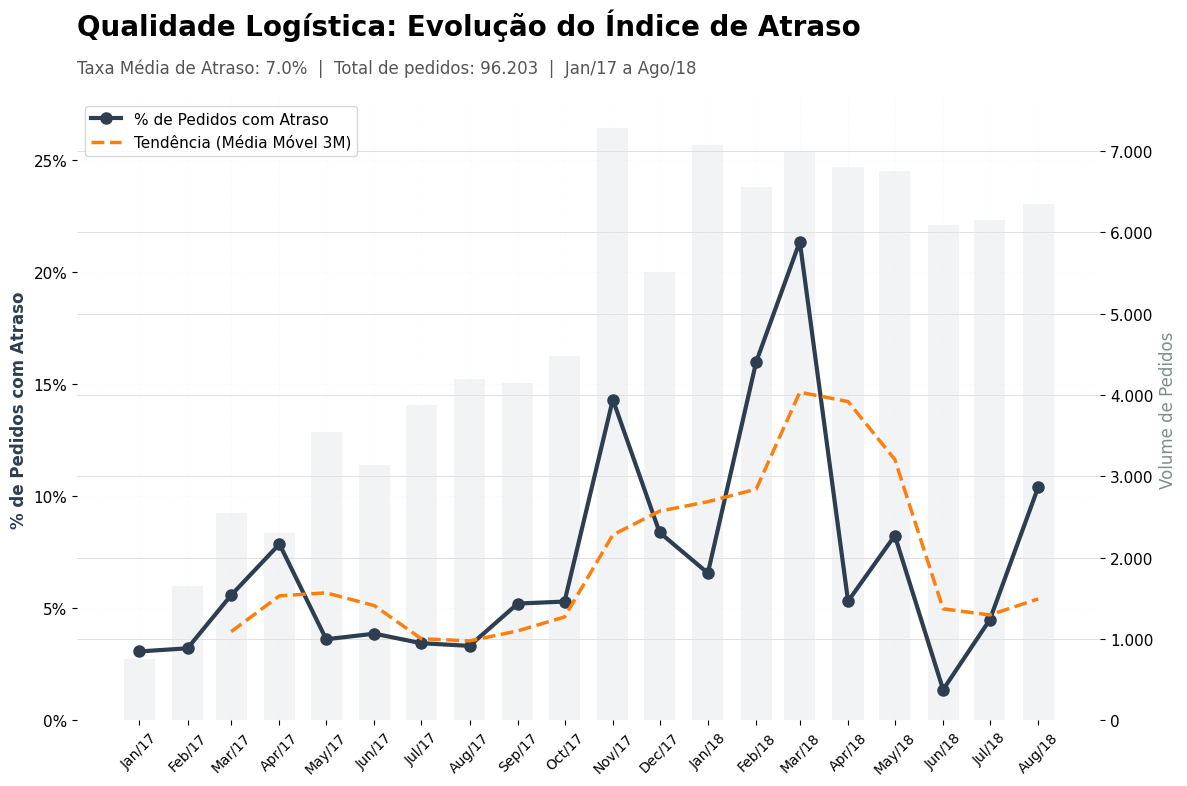

In [116]:
# --- 1. PREPARAÇÃO COM FILTRO DE DATA ---

# Criamos uma cópia do seu resultado do KPI 5
df_plot = df_kpi5.copy()

# Filtro rigoroso: Janeiro/2017 até Agosto/2018
# Como 'ano_mes' é Period, podemos filtrar usando strings de data
df_plot = df_plot[
    (df_plot['ano_mes'] >= '2017-01') &
    (df_plot['ano_mes'] <= '2018-08')
]

# Conversão necessária para o Matplotlib desenhar as linhas corretamente
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()
df_plot['ano_mes_str'] = df_plot['ano_mes_dt'].dt.strftime('%b/%y')

# Recalcula a Tendência dentro do período filtrado
df_plot['tendencia_atraso_3m'] = df_plot['pct_atraso'].rolling(window=3).mean()

# Variáveis para o título baseadas apenas no período filtrado
media_atraso_periodo = df_plot['pct_atraso'].mean()
total_pedidos_periodo = format(int(df_plot['total_pedidos'].sum()), ',').replace(',', '.')

# --- 2. GRÁFICO ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()

# ✅ Estética e Camadas
ax2.set_zorder(0)
ax1.set_zorder(1)
ax1.patch.set_visible(False)

# Volume de Pedidos (Barras Cinzas)
ax2.bar(
    df_plot['ano_mes_dt'],
    df_plot['total_pedidos'],
    width=20,
    color='#d1d8e0',
    alpha=0.3,
    zorder=1
)

# % de Atraso (Linha Azul Escuro)
ax1.plot(
    df_plot['ano_mes_dt'],
    df_plot['pct_atraso'],
    marker='o',
    markersize=8,
    color='#2c3e50',
    linewidth=3,
    label='% de Pedidos com Atraso',
    zorder=3
)

# Média Móvel (Linha Pontilhada Laranja)
ax1.plot(
    df_plot['ano_mes_dt'],
    df_plot['tendencia_atraso_3m'],
    linestyle='--',
    color='#ff7f0e',
    linewidth=2.5,
    label='Tendência (Média Móvel 3M)',
    zorder=3
)

# --- 3. TÍTULO E TEXTOS ---
ax1.set_title(
    'Qualidade Logística: Evolução do Índice de Atraso',
    fontsize=20, weight='bold', loc='left', pad=45
)

subtitulo = (
    f"Taxa Média de Atraso: {media_atraso_periodo:.1f}%  |  "
    f"Total de pedidos: {total_pedidos_periodo}  |  Jan/17 a Ago/18"
)

ax1.text(0, 1.04, subtitulo, fontsize=12, color='#555555', transform=ax1.transAxes)

# --- 4. FORMATOS E LIMITES ---
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax1.set_ylabel('% de Pedidos com Atraso', fontsize=12, weight='bold', color='#2c3e50')
ax1.set_ylim(0, df_plot['pct_atraso'].max() * 1.3) # Dá um respiro no topo

ax2.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
ax2.set_ylabel('Volume de Pedidos', fontsize=12, color='#7f8c8d')

# Eixo X: Mostra cada mês filtrado
ax1.set_xticks(df_plot['ano_mes_dt'])
ax1.set_xticklabels(df_plot['ano_mes_str'], rotation=45, fontsize=10)

# Remove borda superior
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.grid(True, alpha=0.1, linestyle='--', zorder=0)
ax1.legend(loc='upper left', frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

#### **Taxa de atraso (%) por UF**

**Objetivo:** Identificar gargalos logísticos regionais.

**Lógica:**
- Cruza `df_pedidos` → `df_clientes` para obter o estado do **destinatário** (`customer_state`).
- Calcula o tempo médio de entrega e % de atraso por estado.
- Usa apenas pedidos entregues com data de entrega disponível.


In [117]:
# --- Tempo de Entrega por Estado ---

import pandas as pd

# 1. Base: usamos o consolidado e filtramos apenas pedidos entregues
df_kpi6_base = df_consolidado[
    df_consolidado['order_status'] == 'delivered'
].copy()

# 2. Garantimos que as colunas de data estão no formato correto
df_kpi6_base['order_purchase_timestamp'] = pd.to_datetime(df_kpi6_base['order_purchase_timestamp'])
df_kpi6_base['order_delivered_customer_date'] = pd.to_datetime(df_kpi6_base['order_delivered_customer_date'])
df_kpi6_base['order_estimated_delivery_date'] = pd.to_datetime(df_kpi6_base['order_estimated_delivery_date'])

# 3. Removemos registros sem datas essenciais
df_kpi6_base = df_kpi6_base.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# 4. Criamos métricas logísticas

# Tempo total de entrega (compra → entrega)
df_kpi6_base['dias_entrega'] = (
    df_kpi6_base['order_delivered_customer_date'] -
    df_kpi6_base['order_purchase_timestamp']
).dt.days

# Flag de atraso
df_kpi6_base['atrasado'] = (
    df_kpi6_base['order_delivered_customer_date'] >
    df_kpi6_base['order_estimated_delivery_date']
).astype(int)

# Dias de atraso (positivo = atraso)
df_kpi6_base['dias_atraso'] = (
    df_kpi6_base['order_delivered_customer_date'] -
    df_kpi6_base['order_estimated_delivery_date']
).dt.days

# 5. Agregação por estado
df_kpi6 = (
    df_kpi6_base
    .groupby('customer_state', as_index=False)
    .agg(
        qtd_pedidos=('order_id', 'count'),
        tempo_medio_entrega=('dias_entrega', 'mean'),
        tempo_mediano_entrega=('dias_entrega', 'median'),
        pct_atraso=('atrasado', lambda x: x.mean() * 100),
        dias_atraso_medio=('dias_atraso', lambda x: x[x > 0].mean())
    )
    .sort_values('tempo_medio_entrega', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} LOGÍSTICA REGIONAL {'='*20}")
print(f"Estados analisados: {df_kpi6['customer_state'].nunique()}")

print(
    f"Estado com maior demora média: "
    f"{df_kpi6.iloc[0]['customer_state']} "
    f"({df_kpi6.iloc[0]['tempo_medio_entrega']:.1f} dias)"
)

print(
    f"Estado com menor demora média: "
    f"{df_kpi6.iloc[-1]['customer_state']} "
    f"({df_kpi6.iloc[-1]['tempo_medio_entrega']:.1f} dias)"
)

print(f"{'='*53}")

df_kpi6.head(10)

==================== LOGÍSTICA REGIONAL ====================
Estados analisados: 27
Estado com maior demora média: RR (29.0 dias)
Estado com menor demora média: SP (8.3 dias)


,customer_state,qtd_pedidos,tempo_medio_entrega,tempo_mediano_entrega,pct_atraso,dias_atraso_medio
0,RR,41,28.975610,25.0,12.195122,36.400000
1,AP,67,26.731343,24.0,4.477612,72.500000
2,AM,145,25.986207,25.0,4.137931,30.250000
3,AL,397,24.040302,22.0,23.929471,9.541176
4,PA,946,23.316068,21.0,12.367865,12.820755
5,MA,717,21.117155,19.0,19.665272,10.504000
6,SE,335,21.029851,18.0,15.223881,16.196078
7,CE,1279,20.817826,18.0,15.324472,15.181818
8,AC,80,20.637500,18.0,3.750000,18.666667
9,PB,517,19.953578,18.0,11.025145,10.333333


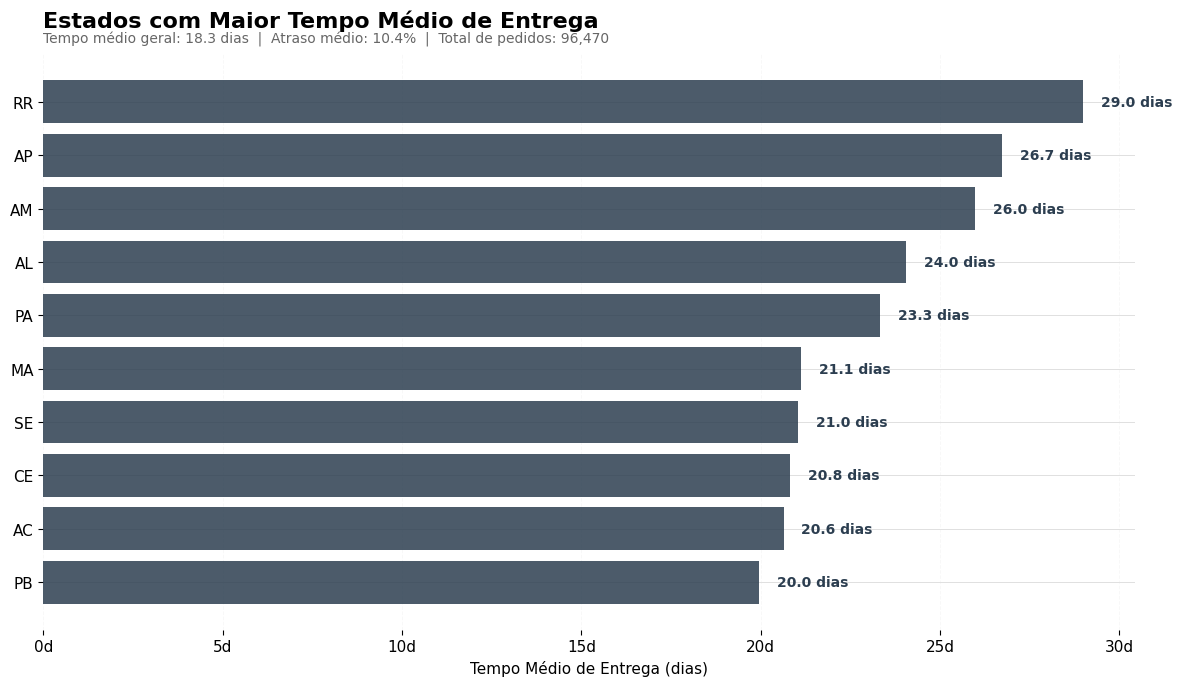

In [118]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. PREPARAÇÃO ---
df_plot = df_kpi6.copy()

# Top 10 estados com maior tempo médio de entrega
df_plot = df_plot.sort_values('tempo_medio_entrega', ascending=False).head(10)

# Ordenar para gráfico horizontal (menor embaixo, maior em cima)
df_plot = df_plot.sort_values('tempo_medio_entrega', ascending=True)

# --- 2. MÉTRICAS PARA SUBTÍTULO ---
tempo_medio_geral = df_kpi6['tempo_medio_entrega'].mean()
pct_atraso_medio = df_kpi6['pct_atraso'].mean()
total_pedidos = df_kpi6['qtd_pedidos'].sum()

# --- 3. GRÁFICO ---
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(
    df_plot['customer_state'],
    df_plot['tempo_medio_entrega'],
    color='#2c3e50',
    alpha=0.85
)

# --- 4. RÓTULOS NAS BARRAS ---
for i, row in df_plot.iterrows():
    ax.text(
        row['tempo_medio_entrega'] + 0.5,
        row['customer_state'],
        f"{row['tempo_medio_entrega']:.1f} dias",
        va='center',
        fontsize=10,
        color='#2c3e50',
        fontweight='bold'
    )

# --- 5. TÍTULO E SUBTÍTULO ---
ax.set_title(
    'Estados com Maior Tempo Médio de Entrega',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=20
)

subtitulo = (
    f"Tempo médio geral: {tempo_medio_geral:.1f} dias  |  "
    f"Atraso médio: {pct_atraso_medio:.1f}%  |  "
    f"Total de pedidos: {total_pedidos:,.0f}"
)

ax.text(
    0, 1.02,
    subtitulo,
    transform=ax.transAxes,
    fontsize=10,
    color='#666666'
)

# --- 6. EIXOS ---
ax.set_xlabel('Tempo Médio de Entrega (dias)', fontsize=11)
ax.set_ylabel('')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}d'))

# --- 7. ESTÉTICA ---
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

ax.grid(axis='x', linestyle='--', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('kpi6_logistica_estados.png', dpi=150, bbox_inches='tight')
plt.show()

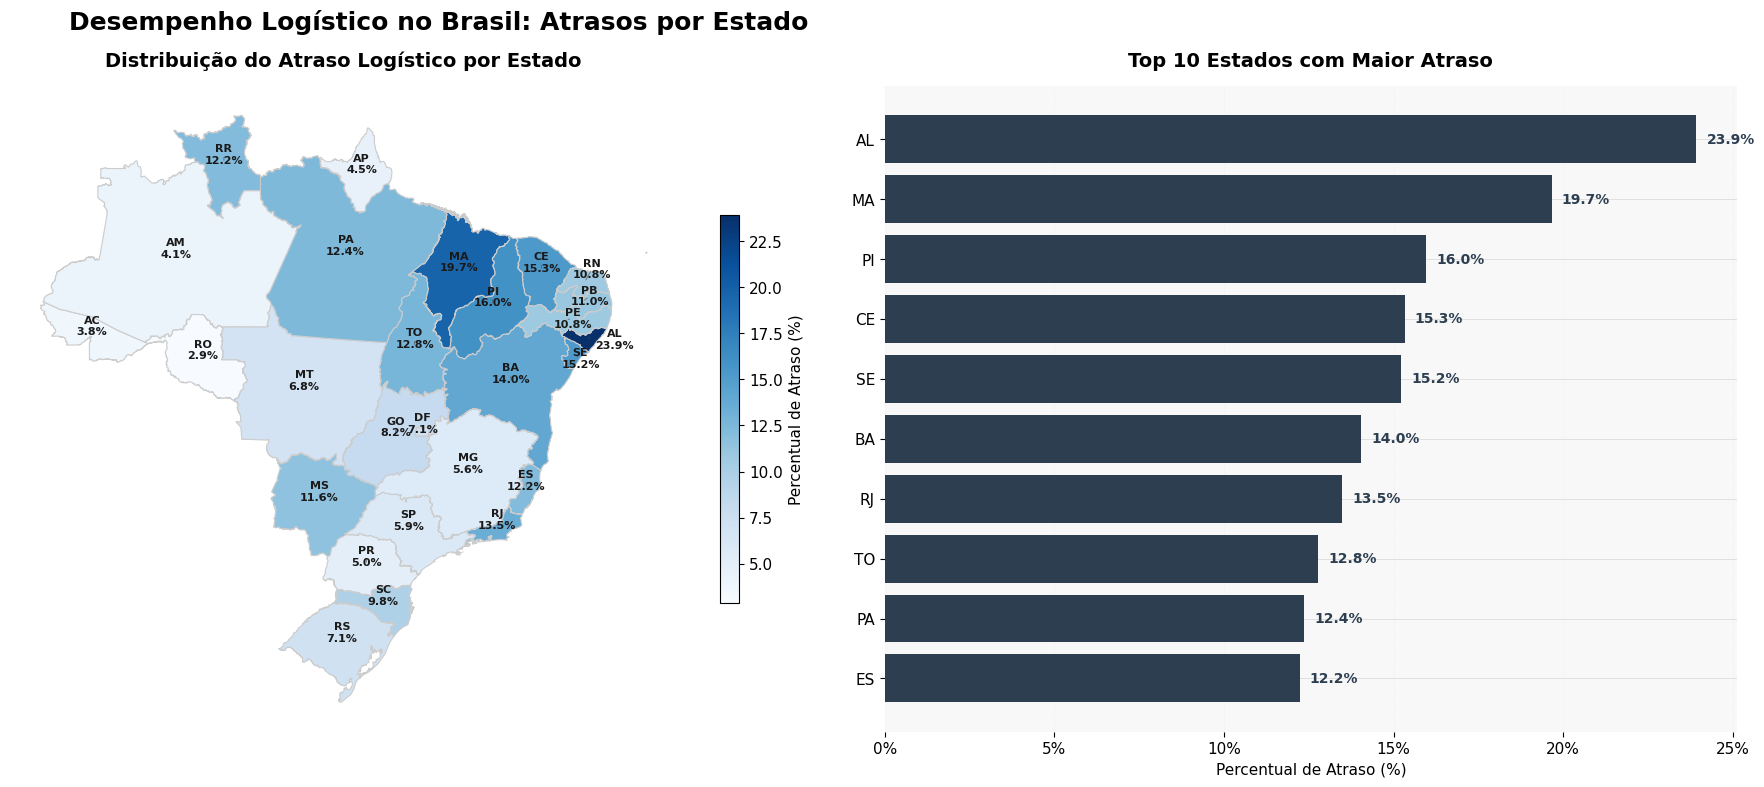

In [119]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. CARREGAR MAPA DO BRASIL ---
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url)

# --- 2. MERGE COM KPI 6 ---
df_mapa = brasil.merge(df_kpi6, left_on='sigla', right_on='customer_state')

# --- 3. PREPARAR RANKING ---
top10 = (
    df_kpi6
    .sort_values('pct_atraso', ascending=False)
    .head(10)
    .sort_values('pct_atraso', ascending=True)
)

# --- 4. FIGURA COM DOIS PAINÉIS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')

# ================================
# 🗺️ MAPA (ESQUERDA)
# ================================
df_mapa.plot(
    column='pct_atraso',
    cmap='Blues',
    linewidth=0.8,
    ax=ax1,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        'label': "Percentual de Atraso (%)",
        'orientation': "vertical",
        'shrink': 0.6
    }
)

# offsets para estados pequenos
offsets = {
    'RN': (0.5, 0.3),
    'PB': (0.5, -0.2),
    'PE': (0.5, -0.5),
    'AL': (2.0, -0.7),
    'SE': (0.5, -0.9),
}

# anotação com deslocamento
for idx, row in df_mapa.iterrows():
    centro = row['geometry'].centroid
    dx, dy = offsets.get(row['sigla'], (0, 0))

    ax1.annotate(
        text=f"{row['sigla']}\n{row['pct_atraso']:.1f}%",
        xy=(centro.x, centro.y),
        xytext=(centro.x + dx, centro.y + dy),
        textcoords='data',
        ha='center',
        fontsize=8,
        color='#1A1A1A',
        weight='bold',
        arrowprops=dict(arrowstyle='-', lw=0.5, color='#555555')
    )

ax1.set_title('Distribuição do Atraso Logístico por Estado', fontsize=14, fontweight='bold')
ax1.set_axis_off()

# ================================
# 📊 RANKING (DIREITA)
# ================================
bars = ax2.barh(
    top10['customer_state'],
    top10['pct_atraso'],
    color='#2c3e50'
)

# Labels nas barras
for i, row in top10.iterrows():
    ax2.text(
        row['pct_atraso'] + 0.3,
        row['customer_state'],
        f"{row['pct_atraso']:.1f}%",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

ax2.set_title('Top 10 Estados com Maior Atraso', fontsize=14, fontweight='bold')
ax2.set_xlabel('Percentual de Atraso (%)')
ax2.set_ylabel('')

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Estética limpa
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.spines['bottom'].set_color('#cccccc')
ax2.grid(axis='x', linestyle='--', alpha=0.2)
ax2.set_axisbelow(True)

# ================================
# 🧾 TÍTULO GERAL
# ================================
fig.suptitle(
    'Desempenho Logístico no Brasil: Atrasos por Estado',
    fontsize=18,
    fontweight='bold',
    x=0.05,
    ha='left'
)

plt.tight_layout()
plt.savefig('kpi6_mapa_ranking.png', dpi=300, bbox_inches='tight')
plt.show()



### **8.3 Satisfação do Cliente**

#### **Atrasos e Impacto no Review Score**

**Objetivo:** Quantificar a degradação da satisfação do cliente (review_score) à medida que o tempo de atraso aumenta, identificando o limite de tolerância do consumidor.

**Lógica:**
- **Base de Dados:** Utiliza o `df_consolidado`, filtrando pedidos avaliados entre Jan/2017 e Ago/2018.  
- **Segmentação:** Além da visão binária (No Prazo vs. Atrasado), os dados são agrupados em faixas de dias de atraso (ex: até 3 dias, 4-7 dias, 8-14 dias e +14 dias).
- **Métricas de Tendência Central:** Calcula a Média e a Mediana das notas para cada faixa, permitindo uma visão robusta que ignora distorções causadas por valores extremos.  
- **Análise de Sensibilidade:** Compara como a nota média "despenca" conforme o pedido avança de uma faixa de atraso para outra, evidenciando o prejuízo reputacional por nível de falha logística.

In [120]:
# --- KPI 9: Impacto do Atraso na Nota de Avaliação ---

# 1. Utilizamos a base já tratada de atrasos (KPI 5)
# O df_consolidado já possui o review_score integrado
df_kpi9_base = df_kpi5_base.copy()

# 2. Nota média por status de atraso (No prazo vs Atrasado)
df_kpi9_resumo = (
    df_kpi9_base
    .groupby('atrasado', as_index=False)
    .agg(
        nota_media=('review_score', 'mean'),
        nota_mediana=('review_score', 'median'),
        qtd_pedidos=('order_id', 'count')
    )
    .assign(status=lambda x: x['atrasado'].map({0: 'No prazo', 1: 'Atrasado'}))
)

# 3. Nota média por faixa de atraso (Análise de sensibilidade)
# Criamos as faixas de dias de atraso
bins = [-float('inf'), 0, 3, 7, 14, float('inf')]
labels = ['No prazo', 'Até 3d atraso', '4-7d atraso', '8-14d atraso', '+14d atraso']

df_kpi9_base['faixa_atraso'] = pd.cut(df_kpi9_base['dias_atraso'], bins=bins, labels=labels)

df_kpi9_faixas = (
    df_kpi9_base
    .groupby('faixa_atraso', as_index=False, observed=True)
    .agg(
        nota_media=('review_score', 'mean'),
        qtd_pedidos=('order_id', 'count')
    )
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 9: IMPACTO DO ATRASO NA SATISFAÇÃO {'='*20}")
print("\nResumo por Status:")
print(df_kpi9_resumo[['status', 'nota_media', 'nota_mediana', 'qtd_pedidos']].to_string(index=False))

print("\nAnálise por Faixa de Atraso:")
print(df_kpi9_faixas.to_string(index=False))
print(f"\n{'='*60}")

==================== KPI 9: IMPACTO DO ATRASO NA SATISFAÇÃO ====================

Resumo por Status:
  status  nota_media  nota_mediana  qtd_pedidos
No prazo    4.294292           5.0        88644
Atrasado    2.566506           2.0         7826

Análise por Faixa de Atraso:
 faixa_atraso  nota_media  qtd_pedidos
     No prazo    4.290589        89936
Até 3d atraso    3.291037         1870
  4-7d atraso    2.105549         1802
 8-14d atraso    1.671508         1478
  +14d atraso    1.725843         1384



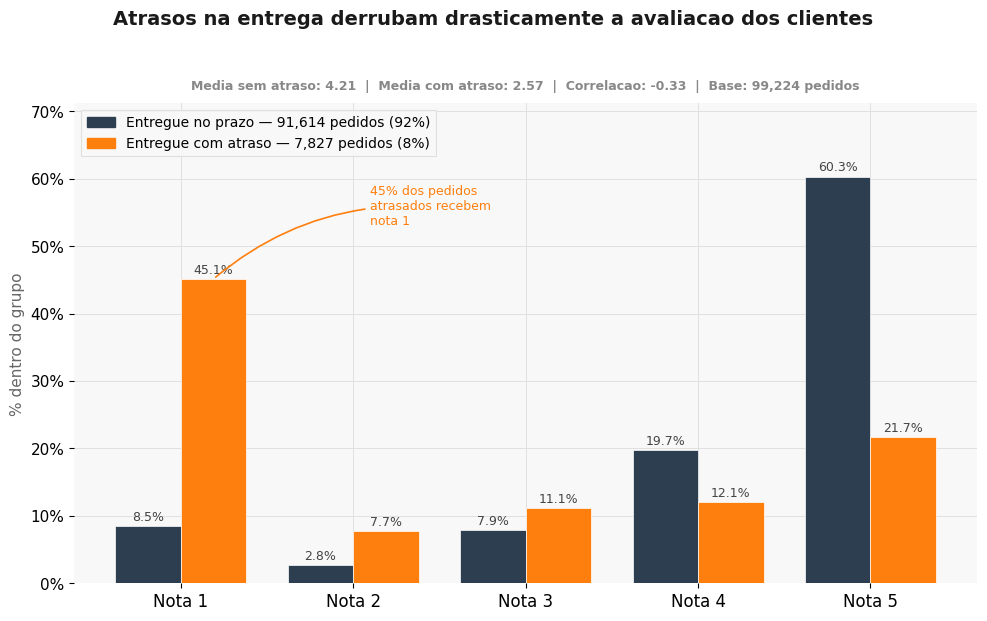

In [121]:
# --- 1. PREPARAÇÃO E FILTRO ---

# ───────────────────────── KPI 1: médias e correlação ─────────────────────────
kpi_review       = df_consolidado.groupby("atrasado")["review_score"].mean()
correlacao       = df_consolidado[["atrasado", "review_score"]].corr().iloc[0, 1]
sem_atraso_total = int((~df_consolidado["atrasado"]).sum())   # 91 614
com_atraso_total = int(df_consolidado["atrasado"].sum())       # 7 827

dist = (
    df_consolidado[df_consolidado["review_score"].isin([1, 2, 3, 4, 5])]
    .groupby(["atrasado", "review_score"])
    .size()
    .unstack(fill_value=0)
)
sem_pct = (dist.loc[False] / sem_atraso_total * 100).values
com_pct = (dist.loc[True]  / com_atraso_total * 100).values

# --- 2. CONFIGURAÇÃO DO GRÁFICO ---

# ───────────────────────── FIGURA 1 — KPI 1: Distribuição de notas por status de entrega ─────────────────────────

fig1, ax1 = plt.subplots(figsize=(10, 6))

notas   = [1, 2, 3, 4, 5]
x       = range(len(notas))
largura = 0.38

bars_sem = ax1.bar(
    [i - largura / 2 for i in x], sem_pct,
    width=largura, color=AZUL, zorder=3, edgecolor="white", linewidth=0.5
)
bars_com = ax1.bar(
    [i + largura / 2 for i in x], com_pct,
    width=largura, color=LARANJA, zorder=3, edgecolor="white", linewidth=0.5
)

# Rótulos nas barras
for bar in list(bars_sem) + list(bars_com):
    h = bar.get_height()
    if h >= 1.5:
        ax1.text(
            bar.get_x() + bar.get_width() / 2, h + 0.4,
            f"{h:.1f}%", ha="center", va="bottom", fontsize=9, color="#444444"
        )

ax1.set_xticks(list(x))
ax1.set_xticklabels([f"Nota {n}" for n in notas], fontsize=12)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax1.set_ylabel("% dentro do grupo", fontsize=11, color="#666666")
ax1.set_ylim(0, max(sem_pct.max(), com_pct.max()) * 1.18)

# Anotação de destaque
ax1.annotate(
    "45% dos pedidos\natrasados recebem\nnota 1",
    xy=(0 + largura / 2, com_pct[0]),
    xytext=(1.1, com_pct[0] + 8),
    fontsize=9, color=LARANJA, ha="left",
    arrowprops=dict(arrowstyle="-", color=LARANJA, lw=1.2, connectionstyle="arc3,rad=0.2")
)

# Legenda
patch_sem = mpatches.Patch(
    color=AZUL,
    label=f"Entregue no prazo — {sem_atraso_total:,} pedidos ({sem_atraso_total/len(df_consolidado)*100:.0f}%)"
)
patch_com = mpatches.Patch(
    color=LARANJA,
    label=f"Entregue com atraso — {com_atraso_total:,} pedidos ({com_atraso_total/len(df_consolidado)*100:.0f}%)"
)
legend = ax1.legend(
    handles=[patch_sem, patch_com],
    frameon=True, fontsize=10, loc="upper left",
    framealpha=0.9, edgecolor="#DDDDDD", fancybox=False
)
legend.get_frame().set_linewidth(0.8)

# Titulo e subtitulo via suptitle + set_title (funciona bem no Jupyter)
fig1.suptitle(
    "Atrasos na entrega derrubam drasticamente a avaliacao dos clientes",
    fontsize=14, fontweight="bold", color="#1a1a1a",
    x=0.5, y=1.03, ha="center"
)
ax1.set_title(
    f"Media sem atraso: {kpi_review[False]:.2f}  |  "
    f"Media com atraso: {kpi_review[True]:.2f}  |  "
    f"Correlacao: {correlacao:.2f}  |  "
    f"Base: {len(df):,} pedidos",
    fontsize=9, color="#888888", pad=10
)

plt.tight_layout()
plt.savefig("kpi1_review_score.png", dpi=150, bbox_inches="tight")
plt.show()

#### **Índice de Aprovação e Sentimento do Cliente (CSAT)**

**Objetivo:** Monitorar a percepção de qualidade do cliente em termos de satisfação (positivo vs. negativo) para identificar a saúde da marca e o impacto de falhas operacionais.

**Lógica:**
- Avaliação Positiva (CSAT): Pedidos com review_score >= 4 (Notas 4 e 5).
- Avaliação Negativa (Detratores): Pedidos com review_score <= 2 (Notas 1 e 2).
- Avaliação Neutra: Pedidos com review_score == 3.
- Temporalidade: Agrupamento mensal por data de compra para análise de tendência através de média móvel (3 meses).


In [122]:
# --- KPI 8: Índice de Aprovação e Sentimento do Cliente (CSAT) ---

# 1. Filtro de avaliações e período consistente (Jan/17 a Ago/18)
df_kpi8_base = df_consolidado[
    (df_consolidado['review_score'].notna()) &
    (df_consolidado['order_purchase_timestamp'] >= '2017-01-01') &
    (df_consolidado['order_purchase_timestamp'] <= '2018-08-31')
].copy()

# 2. Referência temporal e formato de data
df_kpi8_base['order_purchase_timestamp'] = pd.to_datetime(df_kpi8_base['order_purchase_timestamp'])
df_kpi8_base['ano_mes'] = df_kpi8_base['order_purchase_timestamp'].dt.to_period('M')

# 3. Classificação de Sentimento (Lógica CSAT)
# Criamos as flags binárias para facilitar a agregação (soma)
df_kpi8_base['positiva'] = (df_kpi8_base['review_score'] >= 4).astype(int)
df_kpi8_base['negativa'] = (df_kpi8_base['review_score'] <= 2).astype(int)
df_kpi8_base['neutra']   = (df_kpi8_base['review_score'] == 3).astype(int)

# 4. Agregação Mensal
df_kpi8 = (
    df_kpi8_base
    .groupby('ano_mes', as_index=False)
    .agg(
        total_avaliacoes=('order_id', 'count'),
        qtd_positivas=('positiva', 'sum'),
        qtd_negativas=('negativa', 'sum'),
        qtd_neutras=('neutra', 'sum')
    )
    .assign(
        pct_positivas=lambda x: (x['qtd_positivas'] / x['total_avaliacoes']) * 100,
        pct_negativas=lambda x: (x['qtd_negativas'] / x['total_avaliacoes']) * 100
    )
    .sort_values('ano_mes')
)

# 5. Cálculo da Tendência (Média Móvel de 3 meses para o CSAT)
df_kpi8['pct_positivas_3m'] = df_kpi8['pct_positivas'].rolling(window=3, min_periods=1).mean()

# --- RESULTADOS CONSOLIDADOS ---
print(f"{'='*20} KPI 8: ANÁLISE DE SENTIMENTO (CSAT) {'='*20}")
total_geral = df_kpi8['total_avaliacoes'].sum()
pos_geral = (df_kpi8['qtd_positivas'].sum() / total_geral) * 100
neg_geral = (df_kpi8['qtd_negativas'].sum() / total_geral) * 100

print(f"Média Ponderada Positivas (CSAT): {pos_geral:.1f}%")
print(f"Média Ponderada Negativas:        {neg_geral:.1f}%")
print(f"Total de avaliações no período:   {total_geral:,}")
print(f"{'='*62}")

df_kpi8.head(10)

==================== KPI 8: ANÁLISE DE SENTIMENTO (CSAT) ====================
Média Ponderada Positivas (CSAT): 77.1%
Média Ponderada Negativas:        14.6%
Total de avaliações no período:   98,329


,ano_mes,total_avaliacoes,qtd_positivas,qtd_negativas,qtd_neutras,pct_positivas,pct_negativas,pct_positivas_3m
0,2017-01,790,600,123,67,75.949367,15.569620,75.949367
1,2017-02,1768,1315,286,167,74.377828,16.176471,75.163598
2,2017-03,2661,2041,377,242,76.700489,14.167606,75.675895
3,2017-04,2387,1806,366,213,75.659824,15.333054,75.579380
4,2017-05,3666,2874,466,323,78.396072,12.711402,76.918795
5,2017-06,3218,2528,405,282,78.558111,12.585457,77.538002
6,2017-07,3990,3156,485,344,79.097744,12.155388,78.683976
7,2017-08,4298,3510,488,296,81.665891,11.354118,79.773915
8,2017-09,4251,3402,526,321,80.028229,12.373559,80.263955
9,2017-10,4593,3600,604,386,78.380144,13.150446,80.024754


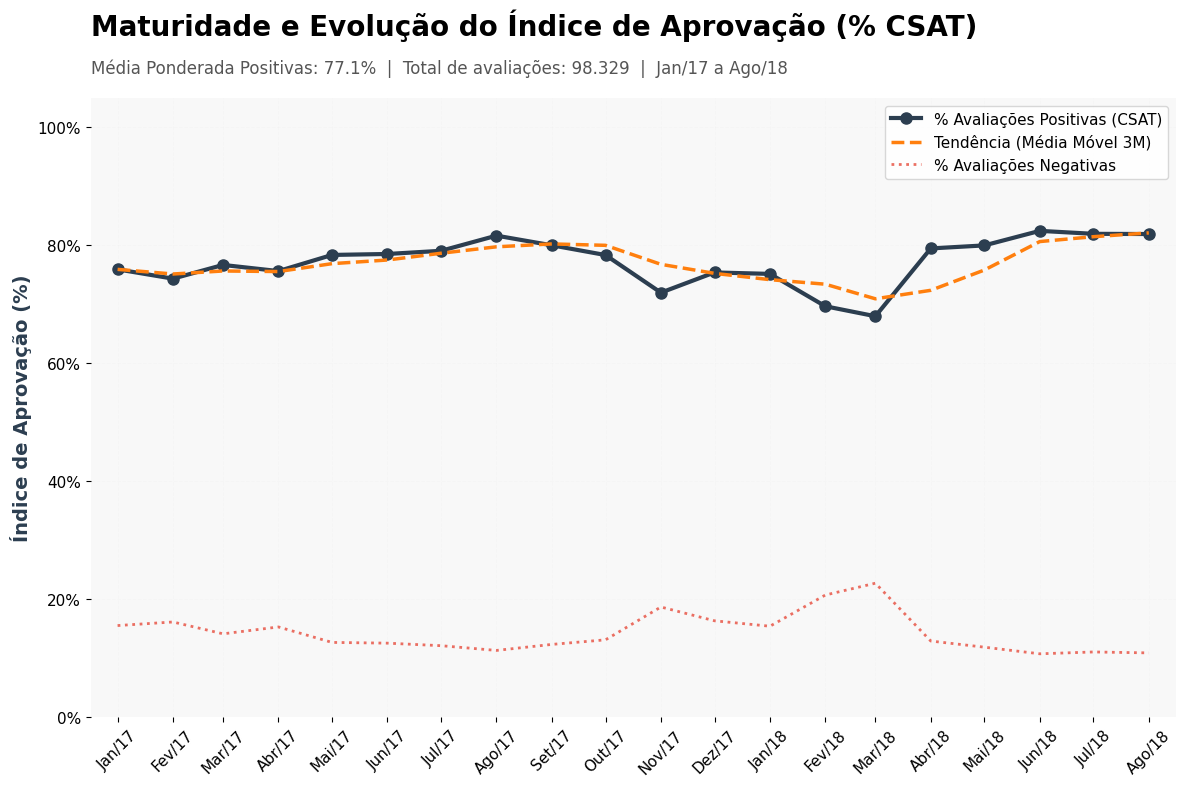

In [123]:
# --- 1. PREPARAÇÃO E FILTRO ---
df_plot = df_kpi8.copy()

if pd.api.types.is_period_dtype(df_plot['ano_mes']):
    df_plot['ano_mes'] = df_plot['ano_mes'].dt.to_timestamp()
else:
    df_plot['ano_mes'] = pd.to_datetime(df_plot['ano_mes'])

df_plot = df_plot.sort_values('ano_mes')

df_clean = df_plot[(df_plot['ano_mes'] >= '2017-01-01') &
                   (df_plot['ano_mes'] <= '2018-08-01')].copy()

# --- 2. FORMATAÇÃO DO EIXO X (PT-BR com inicial maiúscula) ---
df_clean['ano_mes_str'] = df_clean['ano_mes'].dt.strftime('%b/%y')

df_clean['ano_mes_str'] = df_clean['ano_mes_str'].replace({
    'Jan': 'Jan', 'Feb': 'Fev', 'Mar': 'Mar', 'Apr': 'Abr',
    'May': 'Mai', 'Jun': 'Jun', 'Jul': 'Jul', 'Aug': 'Ago',
    'Sep': 'Set', 'Oct': 'Out', 'Nov': 'Nov', 'Dec': 'Dez'
}, regex=True)

# --- 3. CÁLCULOS ---
df_clean['pct_positivas_3m'] = df_clean['pct_positivas'].rolling(3, min_periods=1).mean()

volume_total = df_clean['total_avaliacoes'].sum()
media_ponderada_positivas = (df_clean['qtd_positivas'].sum() / volume_total) * 100
total_av_formatado = f"{volume_total:,.0f}".replace(",", ".")

# --- 4. GRÁFICO ---
fig, ax = plt.subplots(figsize=(12, 8))

# CSAT principal
ax.plot(df_clean['ano_mes'], df_clean['pct_positivas'],
        marker='o', markersize=8, color='#2c3e50', linewidth=3,
        label='% Avaliações Positivas (CSAT)')

# Tendência
ax.plot(df_clean['ano_mes'], df_clean['pct_positivas_3m'],
        linestyle='--', color='#ff7f0e', linewidth=2.5,
        label='Tendência (Média Móvel 3M)')

# Negativas (mais leve)
ax.plot(df_clean['ano_mes'], df_clean['pct_negativas'],
        linestyle=':', color='#e74c3c', alpha=0.8, linewidth=2,
        label='% Avaliações Negativas')

# --- 5. TÍTULO E SUBTÍTULO ---
ax.set_title('Maturidade e Evolução do Índice de Aprovação (% CSAT)',
             fontsize=20, weight='bold', loc='left', pad=45)

subtitulo = (f"Média Ponderada Positivas: {media_ponderada_positivas:.1f}%  |  "
             f"Total de avaliações: {total_av_formatado}  |  Jan/17 a Ago/18")

ax.text(x=0, y=1.04, s=subtitulo, fontsize=12, color='#555555',
        transform=ax.transAxes, ha='left')

# --- 6. AJUSTES ---
ax.set_ylabel('Índice de Aprovação (%)', fontsize=14, color='#2c3e50', weight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(100.0, decimals=0))
ax.set_ylim(0, 105)

# Eixo X formatado
step = 1  # pode usar 2 para apresentação
ax.set_xticks(df_clean['ano_mes'][::step])
ax.set_xticklabels(df_clean['ano_mes_str'][::step], rotation=45, fontsize=11)

ax.set_xlim(df_clean['ano_mes'].min() - pd.Timedelta(days=15),
            df_clean['ano_mes'].max() + pd.Timedelta(days=15))

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.1, linestyle='--')

# Legenda
ax.legend(loc='upper right',
          frameon=True, facecolor='white', edgecolor='lightgray',
          framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.savefig('kpi8_aprovacao_consolidado.png', dpi=300, bbox_inches='tight')
plt.show()

#### **Taxa de Recompra após Atraso na Entrega**

**Objetivo:** Mensurar o impacto financeiro e a perda de clientes (Churn) causada por falhas logísticas, identificando quantos consumidores dão uma segunda chance à plataforma após uma experiência de atraso.

**Lógica:**
- Identificação de Alvos: Seleciona todos os usuários únicos (customer_unique_id) que tiveram pelo menos um pedido com a flag de atraso confirmada.
- Cálculo de Recompra: Cruza esses usuários com a base total de pedidos para verificar se possuem order_id distintos vinculados ao seu ID.
- Métrica de Fidelidade: A taxa é calculada como:$$\text{Taxa de Recompra} = \frac{\text{Clientes que sofreram atraso e compraram de novo}}{\text{Total de clientes que sofreram atraso}}$$
- Visualização: Utiliza um gráfico de Donut para destacar o percentual de retenção e um gráfico de barras para dar contexto ao volume absoluto de clientes perdidos.

In [124]:
# --- KPI 8: Taxa de Recompra (Fidelização) após Atraso ---

# 1. Preparação da Base: Filtramos apenas pedidos com status de entrega conhecido
# Usamos o período Jan/17 a Ago/18 para manter a consistência com o relatório
df_kpi8_rec = df_consolidado[
    (df_consolidado['order_purchase_timestamp'] >= '2017-01-01') &
    (df_consolidado['order_purchase_timestamp'] <= '2018-08-31')
].copy()

# 2. Identificação de Clientes e Frequência de Compra
# Calculamos quantos pedidos cada cliente ÚNICO fez na história
pedidos_por_cliente = df_kpi8_rec.groupby("customer_unique_id")["order_id"].nunique()

# 3. Segmentação: Clientes que sofreram atraso
# Identificamos os IDs únicos que tiveram pelo menos um problema de SLA
clientes_com_atraso = df_kpi8_rec[df_kpi8_rec["atrasado"] == 1]["customer_unique_id"].unique()

# 4. Cálculo da Recompra
# Filtramos, dentre os que sofreram atraso, quem tem mais de 1 pedido no total
clientes_que_voltaram = [c for c in clientes_com_atraso if pedidos_por_cliente[c] > 1]

# 5. Métricas Consolidadas
total_atraso = len(clientes_com_atraso)
total_retorno = len(clientes_que_voltaram)
taxa_recompra = (total_retorno / total_atraso) * 100 if total_atraso > 0 else 0

# --- RESULTADOS ---
print(f"{'='*20} KPI 8: FIDELIZAÇÃO (RECOMPRA) {'='*20}")
print(f"Total de clientes afetados por atraso: {total_atraso:,}")
print(f"Clientes que realizaram nova compra:  {total_retorno:,}")
print(f"Taxa de Retenção após Atraso:        {taxa_recompra:.2f}%")
print(f"Taxa de Churn (Perda Estimada):      {100 - taxa_recompra:.2f}%")
print(f"{'='*60}")

# Criando um pequeno DF para conferência se necessário
df_resumo_recompra = pd.DataFrame({
    'Status': ['Recompraram', 'Não Recompraram'],
    'Qtd_Clientes': [total_retorno, total_atraso - total_retorno],
    'Percentual': [taxa_recompra, 100 - taxa_recompra]
})

print(df_resumo_recompra)

==================== KPI 8: FIDELIZAÇÃO (RECOMPRA) ====================
Total de clientes afetados por atraso: 7,768
Clientes que realizaram nova compra:  374
Taxa de Retenção após Atraso:        4.81%
Taxa de Churn (Perda Estimada):      95.19%
            Status  Qtd_Clientes  Percentual
0      Recompraram           374    4.814624
1  Não Recompraram          7394   95.185376


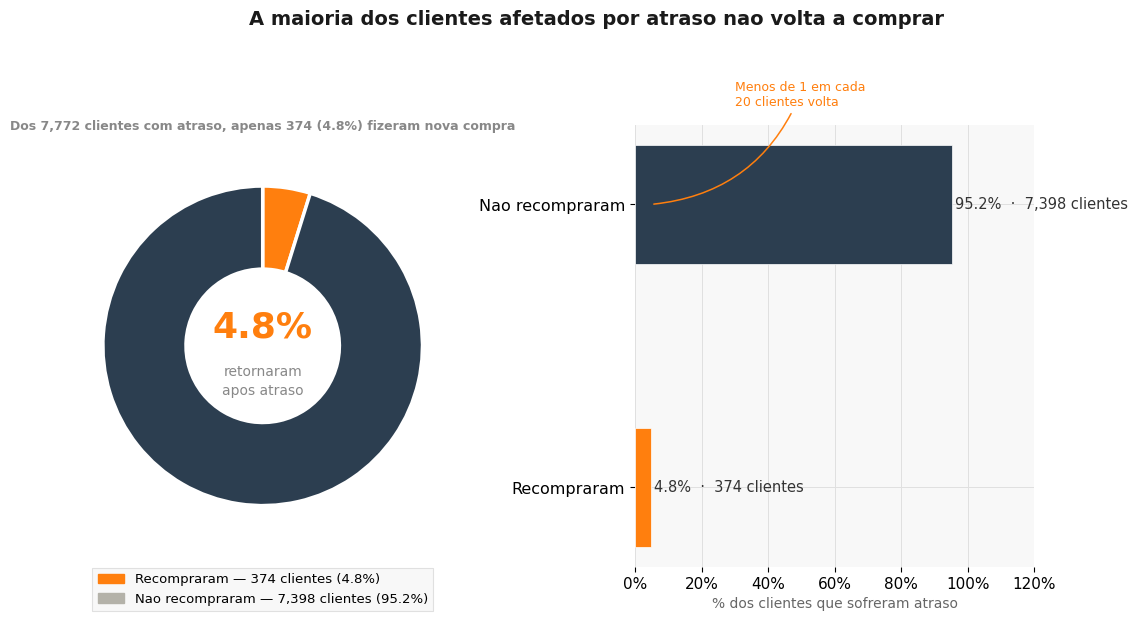

In [125]:
# --- 1. PREPARAÇÃO E FILTRO ---

# ───────────────────────── KPI 2: recompra ─────────────────────────

pedidos_cliente   = df_consolidado.groupby("customer_unique_id")["order_id"].nunique()
clientes_atraso   = df_consolidado[df_consolidado["atrasado"]]["customer_unique_id"].unique()
clientes_recompra = [c for c in clientes_atraso if pedidos_cliente[c] > 1]
total_atraso      = len(clientes_atraso)   # 7 772
total_recompra    = len(clientes_recompra) # 374
taxa              = total_recompra / total_atraso

recompra_pct     = taxa * 100
nao_recompra_pct = (1 - taxa) * 100

# ───────────────────────── FIGURA 2 — KPI 2: Recompra após atraso ─────────────────────────

# ───────────────────────── Figura ─────────────────────────
fig2, (ax_donut, ax_bar) = plt.subplots(1, 2, figsize=(11, 6))

# ───────────────────────── Grafico de Donut ─────────────────────────

ax_donut.pie(
    [recompra_pct, nao_recompra_pct],
    colors=[LARANJA, AZUL],
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor="white", linewidth=2.5),
    counterclock=False,
)
ax_donut.text(
    0, 0.12, f"{recompra_pct:.1f}%",
    ha="center", va="center", fontsize=26, fontweight="bold", color=LARANJA
)
ax_donut.text(
    0, -0.22, "retornaram\napos atraso",
    ha="center", va="center", fontsize=10, color="#888888", linespacing=1.5
)
ax_donut.set_facecolor("#FFFFFF")

patch_ret  = mpatches.Patch(
    color=LARANJA,
    label=f"Recompraram — {total_recompra:,} clientes ({recompra_pct:.1f}%)"
)
patch_nret = mpatches.Patch(
    color=CINZA,
    label=f"Nao recompraram — {total_atraso - total_recompra:,} clientes ({nao_recompra_pct:.1f}%)"
)
leg_donut = ax_donut.legend(
    handles=[patch_ret, patch_nret],
    frameon=True, fontsize=9.5,
    loc="lower center", bbox_to_anchor=(0.5, -0.18),
    framealpha=0.9, edgecolor="#DDDDDD", fancybox=False
)
leg_donut.get_frame().set_linewidth(0.8)

# ───────────────────────── Grafico de Barras horizontais ─────────────────────────

ax_bar.set_facecolor("#F8F8F8")

categorias = ["Recompraram", "Nao recompraram"]
valores    = [recompra_pct, nao_recompra_pct]
cores      = [LARANJA, AZUL]
contagens  = [total_recompra, total_atraso - total_recompra]

bars = ax_bar.barh(
    categorias, valores, color=cores,
    height=0.42, zorder=3, edgecolor="white", linewidth=0.5
)
for bar, v, n in zip(bars, valores, contagens):
    ax_bar.text(
        v + 0.8, bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%  ·  {n:,} clientes",
        va="center", fontsize=10.5, color="#333333"
    )

ax_bar.set_xlim(0, 120)
ax_bar.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_bar.set_xlabel("% dos clientes que sofreram atraso", fontsize=10, color="#666666")
ax_bar.tick_params(axis="y", labelsize=11.5)
ax_bar.grid(axis="x", color="#E0E0E0", linewidth=0.7)
ax_bar.set_axisbelow(True)

for spine in ax_bar.spines.values():
    spine.set_visible(False)

ax_bar.annotate(
    "Menos de 1 em cada\n20 clientes volta",
    xy=(recompra_pct, 1),
    xytext=(30, 1.35),
    fontsize=9, color=LARANJA,
    arrowprops=dict(arrowstyle="-", color=LARANJA, lw=1.1, connectionstyle="arc3,rad=-0.3")
)

# Titulo e subtitulo via suptitle + set_title
fig2.suptitle(
    "A maioria dos clientes afetados por atraso nao volta a comprar",
    fontsize=14, fontweight="bold", color="#1a1a1a",
    x=0.5, y=1.03, ha="center"
)
ax_donut.set_title(
    f"Dos {total_atraso:,} clientes com atraso, apenas {total_recompra:,} ({recompra_pct:.1f}%) fizeram nova compra",
    fontsize=9, color="#888888", pad=12
)

plt.tight_layout()
plt.savefig("kpi2_recompra.png", dpi=150, bbox_inches="tight")
plt.show()


#### **Média de Satisfação**

**Objetivo:** Monitorar o patamar absoluto da experiência do cliente para identificar variações na qualidade percebida ao longo do tempo.

**Lógica:**
- Base de Dados: Utiliza o df_consolidado, com filtro aplicado para o período de Janeiro/2017 a Agosto/2018.
- Métrica Central: Média aritmética mensal do review_score (escala de 1 a 5).
- Média Ponderada: Calcula uma linha de referência fixa baseada no volume total de avaliações, servindo como benchmark histórico.
- Tendência (Smooth): Aplica uma Média Móvel de 3 meses para mitigar o impacto de meses atípicos e visualizar a direção real da satisfação.

In [126]:
# --- Nota Média de Satisfação ao Longo do Tempo ---

# 1. Preparação da Base e Filtro de Datas
df_kpi7_base = df_consolidado[
    (df_consolidado['review_score'].notna()) &
    (df_consolidado['order_purchase_timestamp'] >= '2017-01-01') &
    (df_consolidado['order_purchase_timestamp'] <= '2018-08-31')
].copy()

# 2. Garantir formato de data e criar Ano-Mês
df_kpi7_base['order_purchase_timestamp'] = pd.to_datetime(df_kpi7_base['order_purchase_timestamp'])
df_kpi7_base['ano_mes'] = df_kpi7_base['order_purchase_timestamp'].dt.to_period('M')

# 3. Agrupamento Mensal
df_kpi7 = (
    df_kpi7_base
    .groupby('ano_mes', as_index=False)
    .agg(
        nota_media=('review_score', 'mean'),
        nota_mediana=('review_score', 'median'),
        qtd_avaliacoes=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# 4. Cálculo da Tendência (Média Móvel 3 Meses)
df_kpi7['tendencia_nota_3m'] = df_kpi7['nota_media'].rolling(window=3, min_periods=1).mean()

# --- RESULTADOS CONSOLIDADOS ---
print(f"{'='*20} KPI 7: SATISFAÇÃO MÉDIA {'='*20}")
nota_historica = df_kpi7_base['review_score'].mean()
total_avaliacoes = len(df_kpi7_base)

print(f"Nota Média Histórica:      {nota_historica:.2f}")
print(f"Total de Avaliações:      {total_avaliacoes:,}")
print(f"Período Analisado:        Jan/2017 a Ago/2018")
print(f"{'='*53}")

# Exibição das primeiras linhas do dataframe resultante
df_kpi7.head(10)

==================== KPI 7: SATISFAÇÃO MÉDIA ====================
Nota Média Histórica:      4.09
Total de Avaliações:      98,329
Período Analisado:        Jan/2017 a Ago/2018


,ano_mes,nota_media,nota_mediana,qtd_avaliacoes,tendencia_nota_3m
0,2017-01,4.062658,5.0,790,4.062658
1,2017-02,4.015837,5.0,1768,4.039248
2,2017-03,4.074596,5.0,2661,4.051030
3,2017-04,4.046083,5.0,2387,4.045505
4,2017-05,4.142117,5.0,3666,4.087599
5,2017-06,4.147763,5.0,3218,4.111987
6,2017-07,4.175397,5.0,3990,4.155092
7,2017-08,4.237436,5.0,4298,4.186865
8,2017-09,4.187838,5.0,4251,4.200224
9,2017-10,4.124537,5.0,4593,4.183271


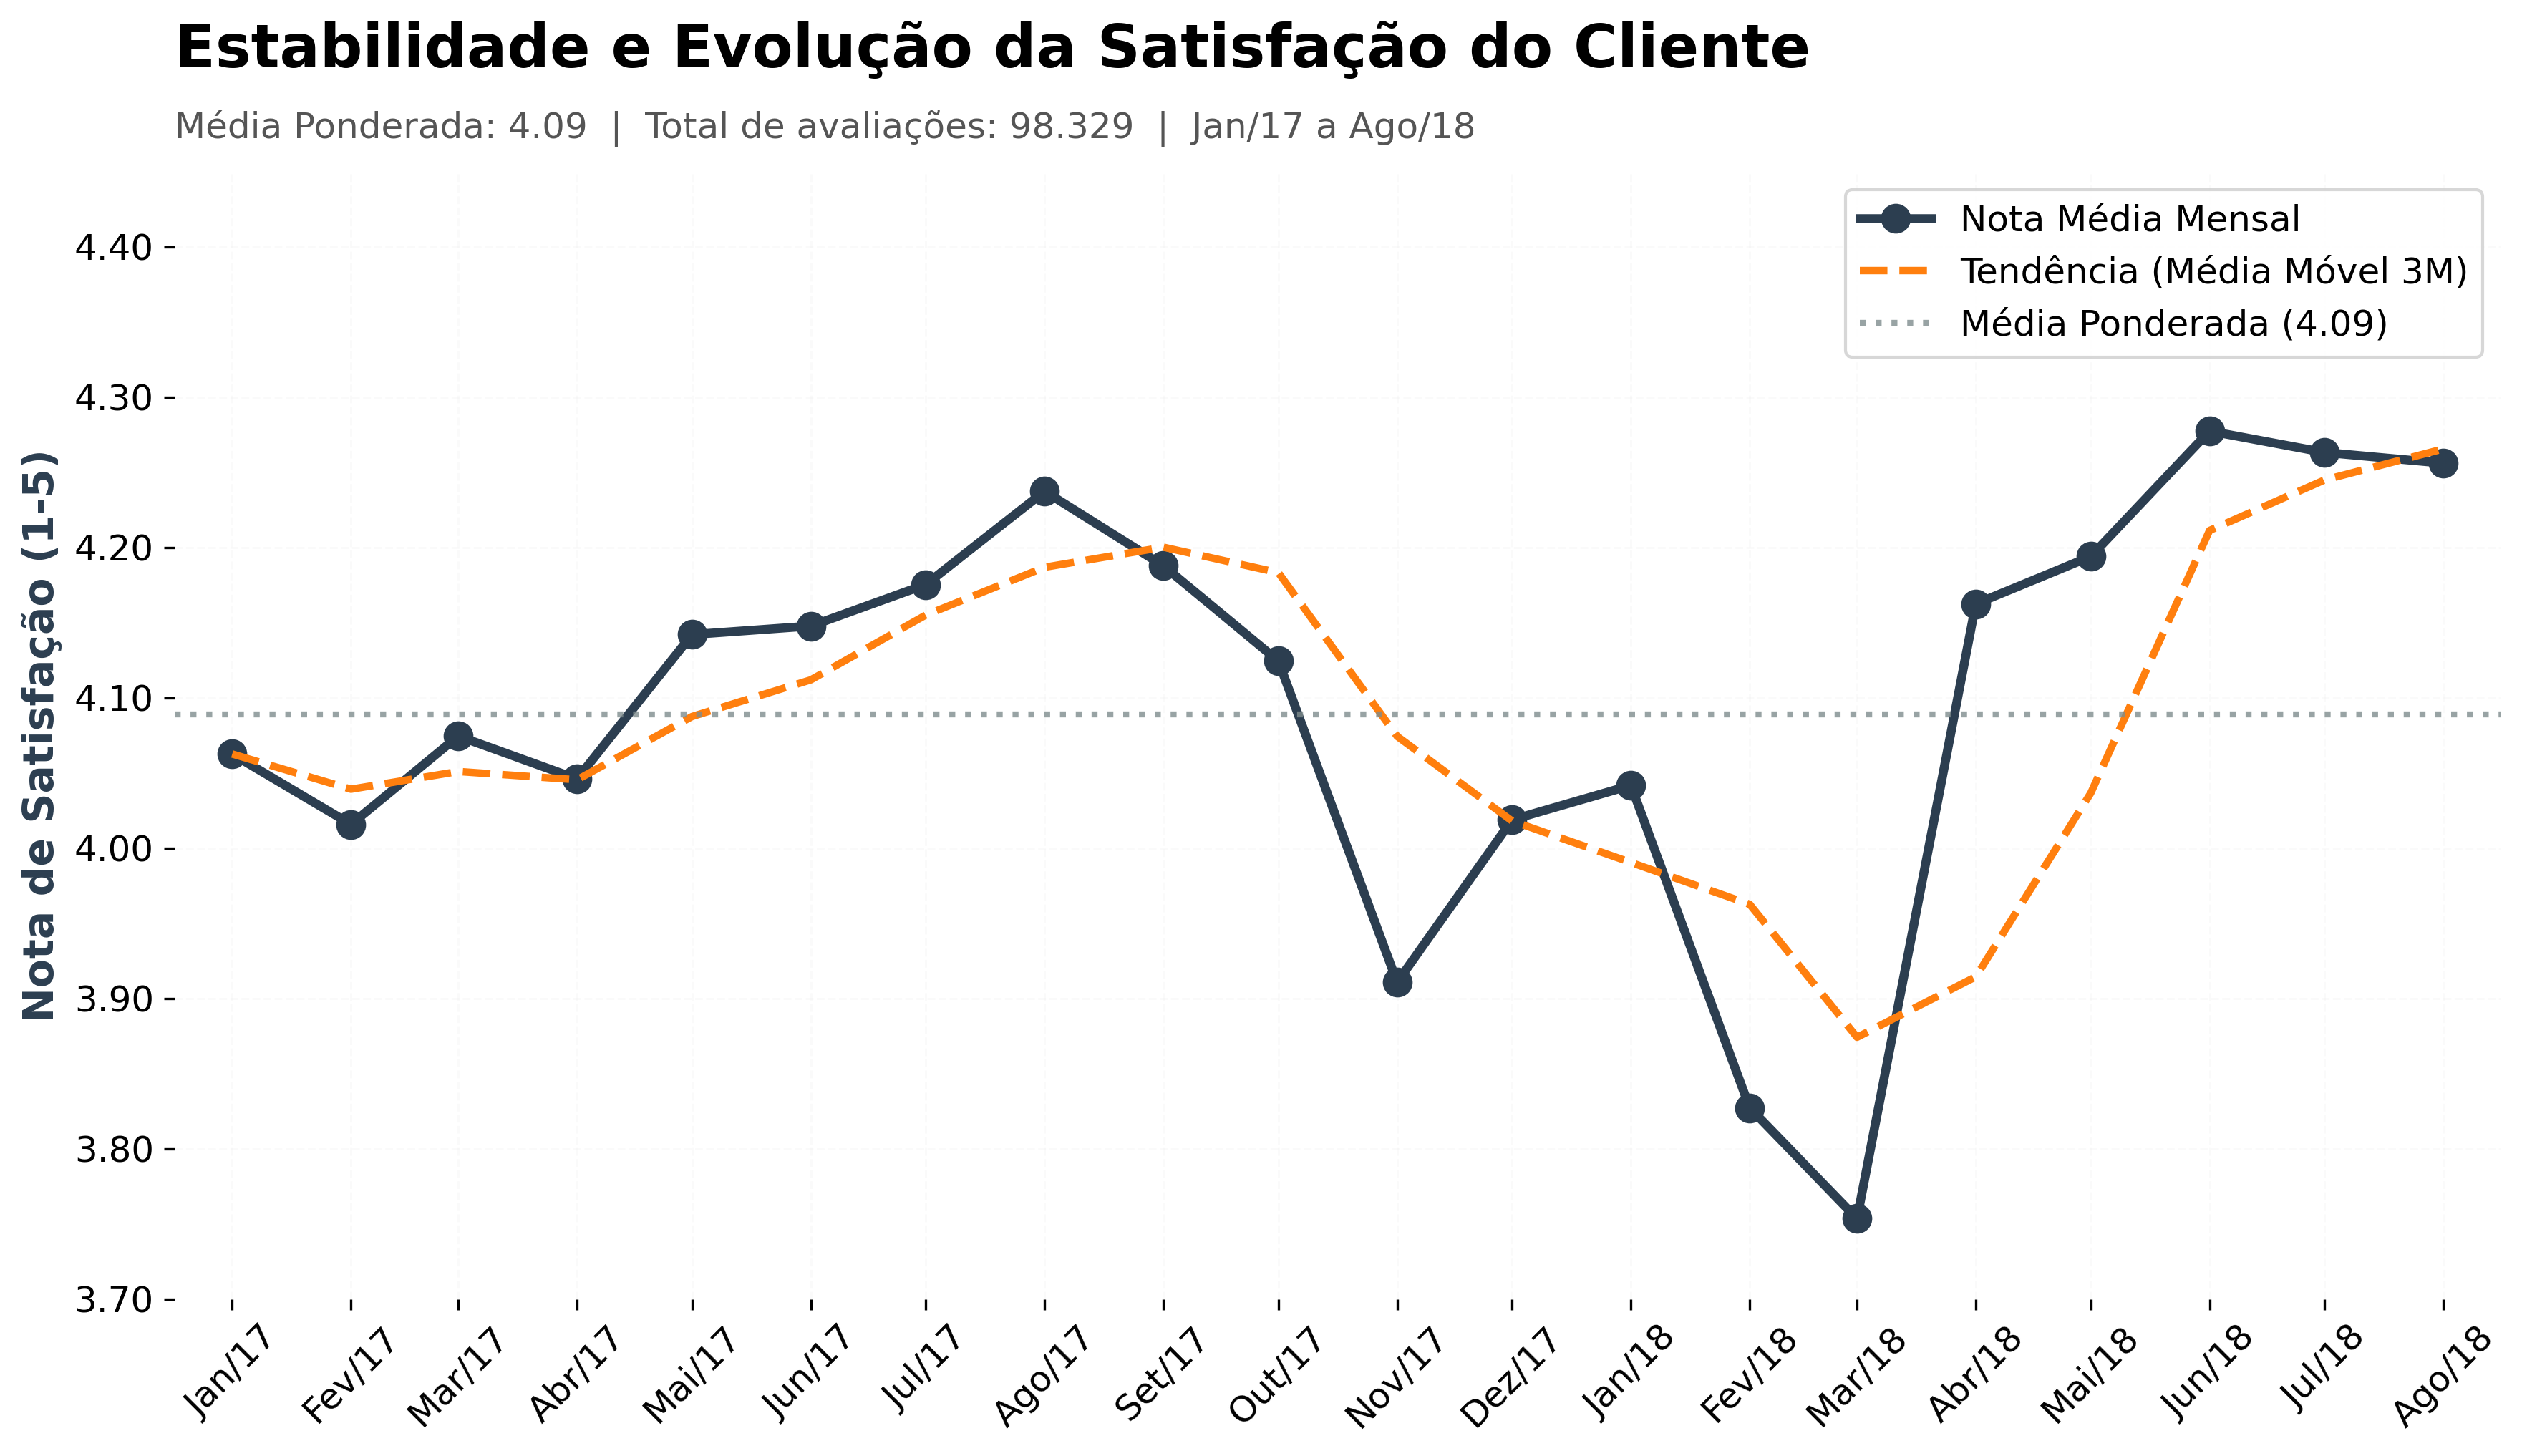

In [127]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Config global (Word) ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# --- 1. PREPARAÇÃO E FILTRO ---
df_plot = df_kpi7.copy()

if pd.api.types.is_period_dtype(df_plot['ano_mes']):
    df_plot['ano_mes'] = df_plot['ano_mes'].dt.to_timestamp()
else:
    df_plot['ano_mes'] = pd.to_datetime(df_plot['ano_mes'])

df_plot = df_plot.sort_values('ano_mes')

df_clean = df_plot[(df_plot['ano_mes'] >= '2017-01-01') &
                   (df_plot['ano_mes'] <= '2018-08-01')].copy()

# --- 2. FORMATAÇÃO DO EIXO X (PADRÃO BR) ---
df_clean['ano_mes_str'] = df_clean['ano_mes'].dt.strftime('%b/%y')

df_clean['ano_mes_str'] = df_clean['ano_mes_str'].replace({
    'Jan': 'Jan', 'Feb': 'Fev', 'Mar': 'Mar', 'Apr': 'Abr',
    'May': 'Mai', 'Jun': 'Jun', 'Jul': 'Jul', 'Aug': 'Ago',
    'Sep': 'Set', 'Oct': 'Out', 'Nov': 'Nov', 'Dec': 'Dez'
}, regex=True)

# --- 3. CÁLCULOS ---
df_clean['media_movel_3m'] = df_clean['nota_media'].rolling(3, min_periods=1).mean()

total_avaliacoes = df_clean['qtd_avaliacoes'].sum()
media_ponderada = (df_clean['nota_media'] * df_clean['qtd_avaliacoes']).sum() / total_avaliacoes
total_av_formatado = f"{total_avaliacoes:,.0f}".replace(",", ".")

# --- 4. GRÁFICO ---
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Nota média
ax.plot(
    df_clean['ano_mes'],
    df_clean['nota_media'],
    marker='o',
    markersize=9,  # leve ajuste visual
    color='#2c3e50',
    linewidth=3,
    label='Nota Média Mensal'
)

# Tendência
ax.plot(
    df_clean['ano_mes'],
    df_clean['media_movel_3m'],
    linestyle='--',
    color='#ff7f0e',
    linewidth=2.5,
    label='Tendência (Média Móvel 3M)'
)

# Linha média
ax.axhline(
    media_ponderada,
    linestyle=':',
    color='#7f8c8d',
    alpha=0.8,
    linewidth=2,
    label=f'Média Ponderada ({media_ponderada:.2f})'
)

# --- 5. TÍTULO E SUBTÍTULO ---
ax.set_title(
    'Estabilidade e Evolução da Satisfação do Cliente',
    fontsize=20,
    weight='bold',
    loc='left',
    pad=35  # ajuste fino pro Word
)

subtitulo = (
    f"Média Ponderada: {media_ponderada:.2f}  |  "
    f"Total de avaliações: {total_av_formatado}  |  Jan/17 a Ago/18"
)

ax.text(
    x=0,
    y=1.03,  # leve ajuste
    s=subtitulo,
    fontsize=12,
    color='#555555',
    transform=ax.transAxes,
    ha='left'
)

# --- 6. AJUSTES ---
ax.set_ylabel(
    'Nota de Satisfação (1-5)',
    fontsize=14,
    color='#2c3e50',
    weight='bold'
)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_ylim(3.70, 4.45)

# Eixo X
step = 1
ax.set_xticks(df_clean['ano_mes'][::step])
ax.set_xticklabels(
    df_clean['ano_mes_str'][::step],
    rotation=45,
    fontsize=12  # ↑ melhor leitura no Word
)

ax.set_xlim(
    df_clean['ano_mes'].min() - pd.Timedelta(days=15),
    df_clean['ano_mes'].max() + pd.Timedelta(days=15)
)

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, linestyle='--')  # leve ajuste

# Legenda
ax.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.9
)

plt.tight_layout()

# ── Exportação ────────────────────────────────────────────────────────────────
plt.savefig('kpi7_satisfacao_consolidado_word.png', dpi=300, bbox_inches='tight')

plt.show()

### **8.3 Retenção de Clientes**

In [128]:
#%pip install seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# Configurações Visuais
plt.rcParams.update({"figure.facecolor": "#FFFFFF", "axes.facecolor": "#F8F8F8", "font.family": "sans-serif"})
AZUL, LARANJA, VERDE, CINZA = "#2c3e50", "#ff7f0e", "#27ae60", "#B4B2A9"

In [129]:
# 1. Conversão de Datas
colunas_datas = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in colunas_datas: df_pedidos[col] = pd.to_datetime(df_pedidos[col], errors='coerce')
df_itens_pedido['shipping_limit_date'] = pd.to_datetime(df_itens_pedido['shipping_limit_date'], errors='coerce')
df_avaliacoes['review_creation_date'] = pd.to_datetime(df_avaliacoes['review_creation_date'], errors='coerce')
df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'], errors='coerce')

# 2. Padronização de IDs para o Merge
for df in [df_pedidos, df_itens_pedido, df_pagamentos, df_avaliacoes]:
    if 'order_id' in df.columns: df['order_id'] = df['order_id'].astype(str)

# 3. Limpeza de Clientes e Vendedores (Localização)
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str).str.zfill(5)
df_clientes['customer_city'] = df_clientes['customer_city'].str.replace('_', ' ').str.title()

df_vendedores['seller_zip_code_prefix'] = df_vendedores['seller_zip_code_prefix'].astype(str).str.zfill(5)
df_vendedores['seller_city'] = df_vendedores['seller_city'].str.replace('_', ' ').str.title()

# 4. Limpeza de Pagamentos
df_pagamentos.loc[(df_pagamentos['payment_type'] == 'credit_card') & (df_pagamentos['payment_installments'] == 0), 'payment_installments'] = 1

# 5. Limpeza de Avaliações
df_avaliacoes = df_avaliacoes.drop_duplicates(subset='review_id', keep='first')

# 6. Limpeza de Produtos e Padronização de Categorias
df_produtos = df_produtos.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})
df_produtos = df_produtos[df_produtos['product_weight_g'] > 0]
df_produtos = df_produtos[~(
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
)]

mapa_categorias = {
    'alimentos_bebidas': 'alimentos',
    'casa_conforto_2': 'casa_conforto',
    'casa_construcao': 'construcao',
    'construcao_ferramentas_construcao': 'construcao',
    'construcao_ferramentas_ferramentas': 'construcao',
    'construcao_ferramentas_iluminacao': 'construcao',
    'construcao_ferramentas_jardim': 'construcao',
    'construcao_ferramentas_seguranca': 'construcao',
    'eletrodomesticos_2': 'eletrodomesticos',
    'dvds_blu_ray': 'cds_dvds_musicais',
    'musica': 'cds_dvds_musicais',
    'livros_importados': 'livros',
    'livros_interesse_geral': 'livros',
    'livros_tecnicos': 'livros',
    'fashion_bolsas_e_acessorios': 'vestuario',
    'fashion_calcados': 'vestuario',
    'fashion_esporte': 'vestuario',
    'fashion_roupa_feminina': 'vestuario',
    'fashion_roupa_infanto_juvenil': 'vestuario',
    'fashion_roupa_masculina': 'vestuario',
    'fashion_underwear_e_moda_praia': 'vestuario',
    'artes_e_artesanato': 'artes',
    'moveis_colchao_e_estofado': 'moveis',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis',
    'moveis_decoracao': 'moveis',
    'moveis_escritorio': 'moveis',
    'moveis_quarto': 'moveis',
    'moveis_sala': 'moveis',
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',
    'telefonia_fixa': 'telefonia',
    'sinalizacao_e_seguranca': 'seguranca',
    'seguros_e_servicos': 'seguranca',
    'pcs': 'informatica',
    'pc_gamer': 'informatica',
    'tablets_impressao_imagem': 'informatica',
    'informatica_acessorios': 'informatica',
    'industria_comercio_e_negocios': 'industria_comercio',
    'agro_industria_e_comercio': 'industria_comercio',
}

df_produtos['product_category_name'] = (
    df_produtos['product_category_name']
    .map(mapa_categorias)
    .fillna('sem_categoria')
)

print('✅ Tratamento de Dados e Categorias aplicado com sucesso!')

✅ Tratamento de Dados e Categorias aplicado com sucesso!


In [130]:
# Agrupando Itens (Preço e Frete total)
df_itens_agrupado = df_itens_pedido.groupby('order_id').agg({'price': 'sum', 'freight_value': 'sum', 'product_id': 'first', 'seller_id': 'first'}).reset_index()

# Agrupando Pagamentos
df_pagamentos_agrupado = df_pagamentos.groupby('order_id').agg({'payment_value': 'sum', 'payment_type': lambda x: '/'.join(x.unique().astype(str)), 'payment_installments': 'max'}).reset_index()

# Agrupando Avaliações
df_avaliacoes_agrupado = df_avaliacoes.groupby('order_id').agg({'review_score': 'mean', 'review_id': 'first'}).reset_index()

# O MERGE CENTRAL
df_consolidado = pd.merge(df_pedidos, df_itens_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_pagamentos_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_avaliacoes_agrupado, on='order_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_produtos, on='product_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_clientes, on='customer_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_vendedores, on='seller_id', how='left')

df_consolidado["atrasado"] = df_consolidado["order_delivered_customer_date"] > df_consolidado["order_estimated_delivery_date"]
print(f"✅ df_consolidado criada com {df_consolidado.shape[0]} linhas.")

✅ df_consolidado criada com 99441 linhas.


#### **Clientes Novos vs. Fiéis**

**Objetivo:** Mensurar a taxa de fidelização da plataforma, distinguindo clientes de compra única daqueles que demonstram lealdade através da recompra.

**Lógica:**
- Métrica de Corte: Classifica como "Novo" o cliente com apenas 1 pedido registrado e como "Fiel" aquele com 2 ou mais pedidos.
- Volume Absoluto vs. Relativo: O cálculo apresenta tanto a quantidade nominal de clientes quanto o peso percentual de cada grupo sobre o ecossistema total.
- Análise de Churn Implícito: O alto volume de clientes únicos serve como indicador para estratégias de CRM e Lifecycle Marketing, visando reduzir o custo de aquisição (CAC).

In [131]:
# --- KPI 11: Distribuição de Clientes por Fidelidade ---

# 1. Agrupamento para contar pedidos por cliente único
# Usamos o customer_unique_id para rastrear o histórico real do indivíduo
pedidos_por_cliente = (
    df_consolidado
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='qtd_pedidos')
)

# 2. Segmentação Binária
pedidos_por_cliente['categoria'] = pedidos_por_cliente['qtd_pedidos'].apply(
    lambda x: 'Fiel (>1 compra)' if x > 1 else 'Novo (1 compra)'
)

# --- RESULTADOS CONSOLIDADOS ---
total_clientes = len(pedidos_por_cliente)
clientes_fieis = len(pedidos_por_cliente[pedidos_por_cliente['categoria'] == 'Fiel (>1 compra)'])
taxa_fidelidade_geral = (clientes_fieis / total_clientes) * 100

print(f"{'='*20} KPI 11: SAÚDE DA BASE {'='*20}")
print(f"Base Total de Clientes:    {total_clientes:,}")
print(f"Clientes Fiéis:            {clientes_fieis:,}")
print(f"Taxa de Fidelização:       {taxa_fidelidade_geral:.2f}%")
print(f"{'='*50}")

pedidos_por_cliente.head()

==================== KPI 11: SAÚDE DA BASE ====================
Base Total de Clientes:    96,096
Clientes Fiéis:            2,997
Taxa de Fidelização:       3.12%


,customer_unique_id,qtd_pedidos,categoria
0,0000366f3b9a7992bf8c76cfdf3221e2,1,Novo (1 compra)
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Novo (1 compra)
2,0000f46a3911fa3c0805444483337064,1,Novo (1 compra)
3,0000f6ccb0745a6a4b88665a16c9f078,1,Novo (1 compra)
4,0004aac84e0df4da2b147fca70cf8255,1,Novo (1 compra)


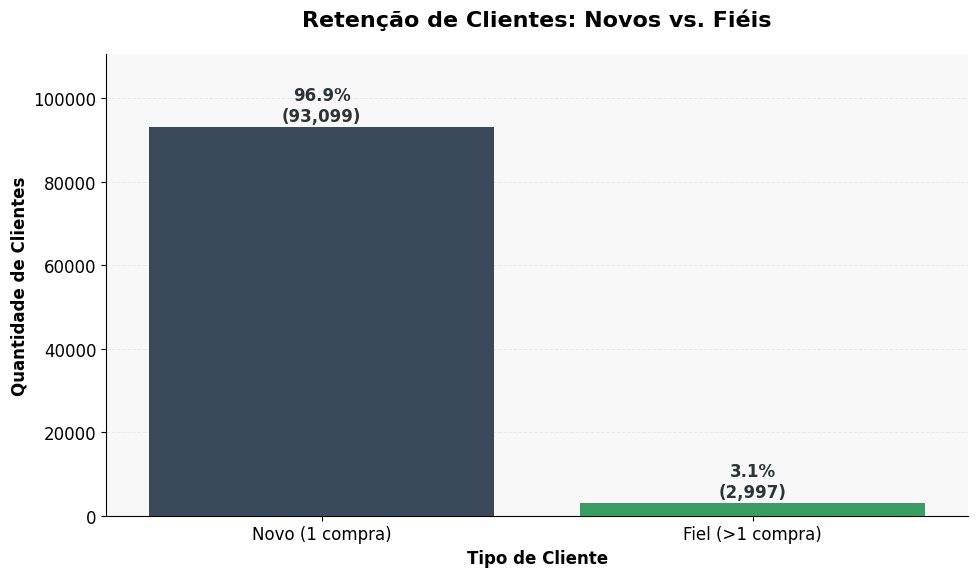

In [132]:
# 1. Distribuição de Clientes por Fidelidade
pedidos_por_cliente = df_consolidado.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='qtd_pedidos')
pedidos_por_cliente['categoria'] = pedidos_por_cliente['qtd_pedidos'].apply(lambda x: 'Fiel (>1 compra)' if x > 1 else 'Novo (1 compra)')

plt.figure(figsize=(10, 6))
total = len(pedidos_por_cliente)
ax = sns.countplot(
    data=pedidos_por_cliente,
    x='categoria',
    palette={'Novo (1 compra)': '#34495e', 'Fiel (>1 compra)': '#27ae60'},
    order=['Novo (1 compra)', 'Fiel (>1 compra)'],
    zorder=3 # Garante que as colunas fiquem à frente do grid
)

# Adicionando o grid ao fundo (eixo Y)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

plt.title('Retenção de Clientes: Novos vs. Fiéis', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Cliente', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Clientes', fontsize=12, fontweight='bold')

# Adicionando % e valores absolutos nas barras
for p in ax.patches:
    pct = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(f'{pct}\n({int(p.get_height()):,})',
                (p.get_x() + p.get_width() / 2., p.get_height() + 500),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2d3436',
                zorder=4) # Garante que o texto fique sobre a coluna e o grid

plt.ylim(0, total * 1.15)
sns.despine() # Remove as bordas superior e direita para um visual mais limpo
plt.tight_layout()
plt.show()

#### **Churn Rate**

**Objetivo:** Identificar o nível de engajamento da base de clientes e o volume de usuários em risco de abandono (Churn), baseando-se no tempo decorrido desde a última transação.

**Lógica:**
- Cálculo de Recência: Identifica a data da última compra de cada customer_unique_id e calcula o intervalo em meses em relação à data mais recente do dataset.
- Agrupamento de Risco: Categoriza os clientes em intervalos mensais, agrupando usuários com inatividade superior a 10 meses em uma categoria crítica.
- Definição de Inatividade: Estabelece um benchmark de 6 meses (180 dias) como o ponto de inflexão onde o cliente é considerado inativo e o esforço de reativação torna-se mais custoso.

In [133]:
# --- KPI 9: Análise de Recência e Risco de Churn ---

import numpy as np

# 1. Identificar a data da última compra por cliente único
df_recencia = (
    df_consolidado
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

# 2. Referência de "Hoje" (última data disponível no dataset)
data_referencia = df_consolidado['order_purchase_timestamp'].max()

# 3. Calcular meses de inatividade
df_recencia['meses_desde_compra'] = (data_referencia - df_recencia['order_purchase_timestamp']).dt.days / 30

# 4. Agrupar em categorias (0 a 10+)
df_recencia['meses_inteiros'] = np.floor(df_recencia['meses_desde_compra']).astype(int)
df_recencia['meses_agrupados'] = df_recencia['meses_inteiros'].apply(
    lambda x: f'{x}' if x < 10 else '10+'
)

# 5. Tabela de Contagem para Insight
contagem_churn = df_recencia['meses_agrupados'].value_counts().reset_index()
contagem_churn.columns = ['meses_inativo', 'quantidade']

# --- RESULTADOS ---
print(f"{'='*20} KPI 9: RISCO DE CHURN {'='*20}")
clientes_totais = len(df_recencia)
clientes_criticos = len(df_recencia[df_recencia['meses_inteiros'] >= 6])
taxa_risco_alto = (clientes_criticos / clientes_totais) * 100

print(f"Total de Clientes na Base:   {clientes_totais:,}")
print(f"Clientes Inativos (>6 meses): {clientes_criticos:,}")
print(f"Exposição ao Risco (Churn):   {taxa_risco_alto:.1f}%")
print(f"{'='*53}")

# Ordenação para conferência
ordem = [str(i) for i in range(10)] + ['10+']
contagem_churn['meses_inativo'] = pd.Categorical(contagem_churn['meses_inativo'], categories=ordem, ordered=True)
print(contagem_churn.sort_values('meses_inativo').to_string(index=False))

==================== KPI 9: RISCO DE CHURN ====================
Total de Clientes na Base:   96,096
Clientes Inativos (>6 meses): 68,352
Exposição ao Risco (Churn):   71.1%
meses_inativo  quantidade
            0           8
            1        1481
            2        7923
            3        5498
            4        5388
            5        7446
            6        6646
            7        7270
            8        6599
            9        5657
          10+       42180


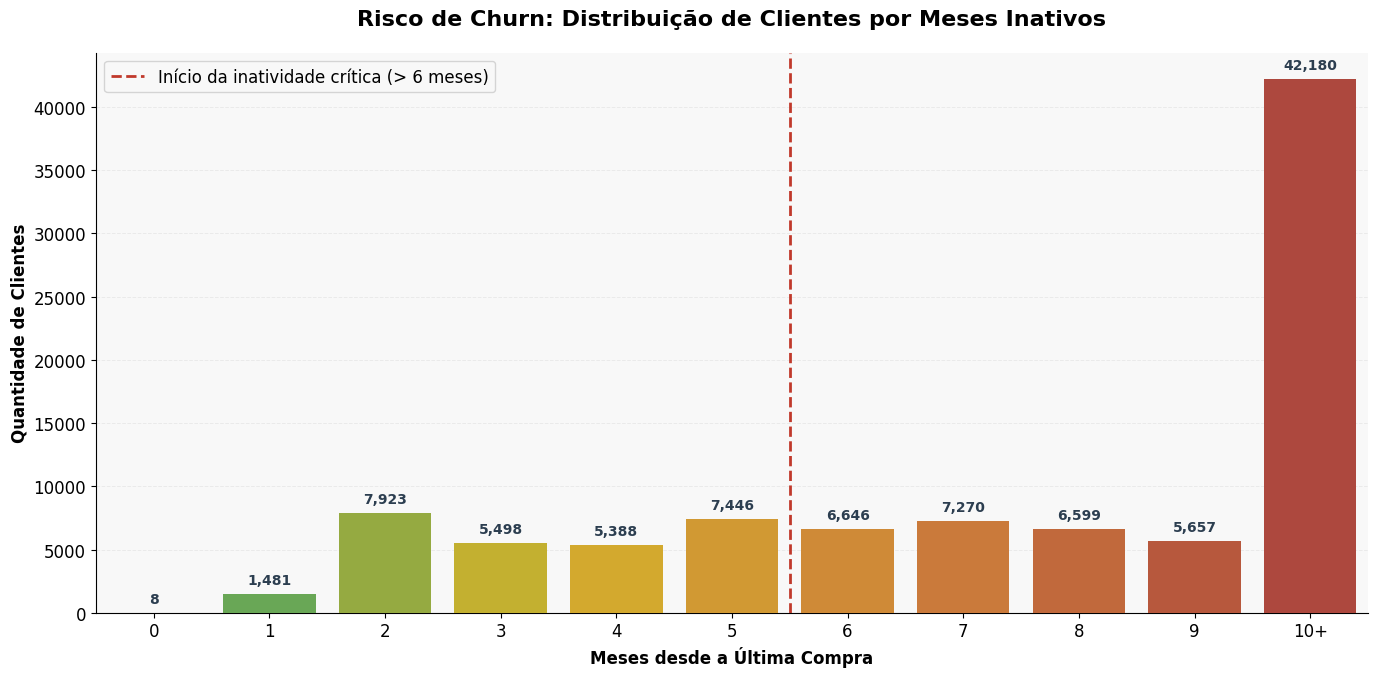

In [134]:
# 2. Análise de Inatividade (Risco de Churn)
# Qual o tempo médio desde a última compra?
ultima_compra = df_consolidado.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
data_max = df_consolidado['order_purchase_timestamp'].max()
ultima_compra['meses_desde_compra'] = (data_max - ultima_compra['order_purchase_timestamp']).dt.days / 30

# Arredondando os meses e agrupando tudo acima de 10 como '10+'
ultima_compra['meses_inteiros'] = np.floor(ultima_compra['meses_desde_compra']).astype(int)
ultima_compra['meses_agrupados'] = ultima_compra['meses_inteiros'].apply(lambda x: f'{x}' if x < 10 else '10+')

# Contagem
contagem_meses = ultima_compra['meses_agrupados'].value_counts().reset_index()
contagem_meses.columns = ['meses_inativo', 'quantidade']

# Ordenar as categorias
ordem_categorias = [str(i) for i in range(10)] + ['10+']
contagem_meses['meses_inativo'] = pd.Categorical(contagem_meses['meses_inativo'], categories=ordem_categorias, ordered=True)
contagem_meses = contagem_meses.sort_values('meses_inativo')

plt.figure(figsize=(14, 7))
# Cores: Gradiente indicando aumento do risco (verdes suaves até vermelhos fortes)
paleta_cores = sns.blend_palette(['#27ae60', '#f1c40f', '#e67e22', '#c0392b'], n_colors=11)

ax = sns.barplot(
    data=contagem_meses,
    x='meses_inativo',
    y='quantidade',
    palette=paleta_cores,
    zorder=3 # Garante que as barras fiquem à frente do grid
)

# Adicionando o grid ao fundo (eixo Y)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Adicionando uma linha de marcação após o 6º mês
plt.axvline(x=5.5, color='#c0392b', linestyle='--', linewidth=2, label='Início da inatividade crítica (> 6 meses)', zorder=4)

plt.title('Risco de Churn: Distribuição de Clientes por Meses Inativos', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Meses desde a Última Compra', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Clientes', fontsize=12, fontweight='bold')

# Rótulos nas barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura):,}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#2c3e50', xytext=(0, 5), textcoords='offset points')

plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

#### **Fatores de Fidelização**

**Objetivo:** Identificar os gatilhos que levam um cliente à recorrência, analisando a qualidade da primeira experiência e as categorias de produtos com maior poder de retenção.

**Lógica:**
- Perfil do Cliente: Classifica os usuários entre "Compra Única" e "Recorrente (Fiel)" com base no histórico total de pedidos.
- Análise da 1ª Experiência: Compara a nota média (review_score) que cada perfil deu em sua primeira compra. A hipótese é que clientes fiéis tiveram uma primeira experiência superior.
- Poder de Retenção por Categoria: Calcula a taxa de fidelidade por categoria de produto, identificando quais segmentos possuem maior probabilidade de gerar uma segunda compra.
- Filtro de Qualidade: Remove registros sem categoria definida para garantir a precisão do insight por departamento.


In [135]:
# --- KPI 10: Fatores de Fidelização (Satisfação e Categorias) ---

# 1. Identificar quem são os clientes fiéis (mais de 1 pedido)
pedidos_por_cliente = df_consolidado.groupby('customer_unique_id')['order_id'].nunique().reset_index()
pedidos_por_cliente.columns = ['customer_unique_id', 'qtd_pedidos']
clientes_fieis_ids = pedidos_por_cliente[pedidos_por_cliente['qtd_pedidos'] > 1]['customer_unique_id']

# 2. Isolar a PRIMEIRA compra de cada cliente para analisar o gatilho inicial
df_primeira_compra = (
    df_consolidado
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

# 3. Classificar o perfil do cliente na base da primeira compra
df_primeira_compra['tipo_cliente'] = df_primeira_compra['customer_unique_id'].apply(
    lambda x: 'Recorrente (Fiel)' if x in clientes_fieis_ids.values else 'Compra Única'
)

# 4. Cálculo de Retenção por Categoria
# Filtramos apenas categorias válidas
df_cat_valida = df_consolidado[df_consolidado['product_category_name'] != 'sem_categoria'].copy()
df_cat_valida['e_fiel'] = df_cat_valida['customer_unique_id'].isin(clientes_fieis_ids)

# Taxa de retenção por categoria (média de 'e_fiel')
ranking_fidelidade_cat = (
    df_cat_valida.groupby('product_category_name')['e_fiel']
    .mean()
    .sort_values(ascending=False) * 100
).head(10)

# --- RESULTADOS ---
print(f"{'='*20} KPI 10: GATILHOS DE FIDELIZAÇÃO {'='*20}")
nota_fiel = df_primeira_compra[df_primeira_compra['tipo_cliente'] == 'Recorrente (Fiel)']['review_score'].mean()
nota_unica = df_primeira_compra[df_primeira_compra['tipo_cliente'] == 'Compra Única']['review_score'].mean()

print(f"Nota Média (1ª compra) - Clientes Fiéis: {nota_fiel:.2f}")
print(f"Nota Média (1ª compra) - Compra Única:  {nota_unica:.2f}")
print(f"\nTop 3 Categorias que mais fidelizam:")
for cat, taxa in ranking_fidelidade_cat.head(3).items():
    print(f"- {cat}: {taxa:.1f}% de retenção")
print(f"{'='*60}")

==================== KPI 10: GATILHOS DE FIDELIZAÇÃO ====================
Nota Média (1ª compra) - Clientes Fiéis: 4.11
Nota Média (1ª compra) - Compra Única:  4.08

Top 3 Categorias que mais fidelizam:
- artes: 22.7% de retenção
- vestuario: 11.5% de retenção
- casa_conforto: 9.1% de retenção


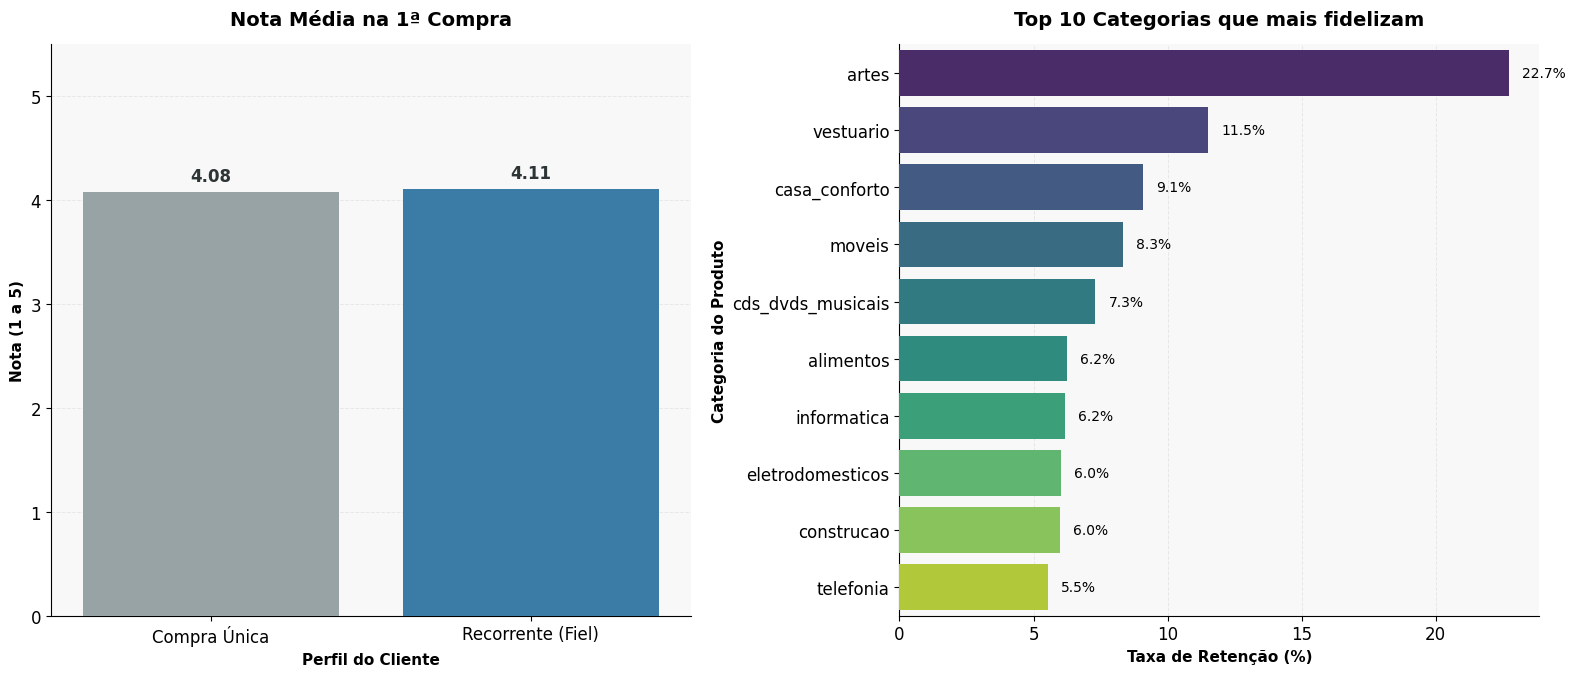

In [136]:
# 3. Fatores de Recompra: Avaliações e Categorias
df_primeira = df_consolidado.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first().reset_index()
clientes_fieis = pedidos_por_cliente[pedidos_por_cliente['qtd_pedidos'] > 1]['customer_unique_id']
df_primeira['tipo_cliente'] = df_primeira['customer_unique_id'].apply(lambda x: 'Recorrente (Fiel)' if x in clientes_fieis.values else 'Compra Única')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfico A: Gráfico de Barras com a Nota Médias ---
# Corrigido: Variável agora em uma linha separada do comentário
satisfacao_media = df_primeira.groupby('tipo_cliente')['review_score'].mean().reset_index()

sns.barplot(
    data=satisfacao_media, x='tipo_cliente', y='review_score', ax=ax1,
    palette={'Compra Única': '#95a5a6', 'Recorrente (Fiel)': '#2980b9'},
    zorder=3 # Garante que a barra fique à frente
)
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0) # Grid ao fundo

ax1.set_title('Nota Média na 1ª Compra', fontsize=14, fontweight='bold')
ax1.set_xlabel('Perfil do Cliente', fontsize=11, fontweight='bold')
ax1.set_ylabel('Nota (1 a 5)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 5.5)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold',
                 color='#2d3436', xytext=(0, 5), textcoords='offset points')
sns.despine(ax=ax1)

# --- Gráfico B: Categorias de Produtos com Maior Taxa de Retenção ---
df_cat = df_consolidado[df_consolidado['product_category_name'] != 'sem_categoria'].copy()
df_cat['fiel'] = df_cat['customer_unique_id'].isin(clientes_fieis)
top_cats = df_cat.groupby('product_category_name')['fiel'].mean().sort_values(ascending=False).head(10) * 100

sns.barplot(
    x=top_cats.values, y=top_cats.index, ax=ax2, palette='viridis',
    zorder=3 # Garante que a barra fique à frente
)
ax2.grid(axis='x', linestyle='--', alpha=0.7, zorder=0) # Grid ao fundo

ax2.set_title('Top 10 Categorias que mais fidelizam', fontsize=14, fontweight='bold')
ax2.set_xlabel('Taxa de Retenção (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Categoria do Produto', fontsize=11, fontweight='bold')

for i, v in enumerate(top_cats.values):
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

In [137]:
# --- Exportação da Base Consolidada ---

# Nome do arquivo final
# nome_arquivo = 'base_consolidada_olist.csv'

# Exportando com encoding compatível com Excel e Power BI
# df_consolidado.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8-sig')


# try:
    # from google.colab import files
    # files.download(nome_arquivo)
    # print(f"✅ Download do arquivo '{nome_arquivo}' iniciado com sucesso!")
# except:
    # print(f"✅ Arquivo '{nome_arquivo}' salvo na pasta local.")